# AL niche axis graph from saved CellChat and enrichment outputs

**Biology rationale.** A multilayer view of the AL bone-marrow niche connects plasma-cell signaling to receiver-cell phenotypes and helps prioritize inflammatory and immunosuppressive mechanisms associated with suboptimal hematologic response.

**Aim.** Integrate saved CellChat communication results and receiver-cell enrichment scores, establish a queryable niche graph, and identify phenotypes associated with PGE2-EP2/EP4 signaling without rerunning CellChat or enrichment scoring.

**Data input.** Saved sample-level CellChat ligand-receptor pair files, receiver-cell enrichment score files, and treatment/response metadata under `./results/plasma_cellchat_enrichment_niche_graph_old_like`.

**Structure.** The notebook loads or reconstructs signaling and phenotype edges, aligns them by sample and receiver cell, derives association evidence, builds the multilayer graph, and applies reusable graph-query functions.

Conceptual graph:

- **Cell-cell signaling edges:** sender cell → receiver cell, annotated by ligand-receptor axis, sample, treatment, and response.
- **Enrichment/phenotype edges:** receiver cell → enrichment pathway/phenotype, annotated by sample, treatment, and response.
- **Association edges:** ligand-receptor signaling axis → receiver-cell phenotype, derived from sample-level correlation and response/treatment contrasts.
- **Metadata nodes:** sample/treatment/response context is carried as node and edge metadata.

**Data outputs.** Sample-level communication and enrichment tables, signaling-to-phenotype association tables, graph node and edge tables, and ranked PGE2-EP2/EP4 phenotype-query results written to the configured output directory.

The final ranking is an association-based prioritization, not proof of causality unless supported by perturbation data.

## 1. User settings

Only edit this cell in routine use.

The saved enrichment / old graph results are expected under:

`./results/plasma_cellchat_enrichment_niche_graph_old_like`

The notebook will preferentially reuse already generated tables in that folder. If a required table is absent, it will reconstruct that table from saved CellChat pair files and saved enrichment score files.


In [1]:
# ============================================================
# 0) User settings
# ============================================================

# Saved CellChat outputs from the original per-sample CellChat run.
# This folder should contain either:
#   - cellchat_pairs_<sample>.csv(.gz), written from subsetCommunication(cellchat), or
#   - plasma_pathways_all_pairs.csv(.gz), already filtered to plasma-involving pairs.
cellchat_out_dir <- "./cellchat_per_sample_plasma_trial3_repeat_repeat"

# IMPORTANT:
# Prefer raw per-sample CellChat pair files over old summarized graph tables.
# The old_like file 02_cellchat_sample_level_edges.csv.gz may be axis-level only
# and therefore cannot support sample-level signaling -> phenotype correlations.
prefer_cellchat_pairs_from_dir <- TRUE

# User-specified saved enrichment / old graph output directory.
enrichment_out_dir <- "./results/plasma_cellchat_enrichment_niche_graph_old_like"

# New graph-only output directory.
out_dir <- "./results/plasma_cellchat_ALNiche_axis_graph"
dir.create(out_dir, showWarnings = FALSE, recursive = TRUE)

# Optional external sample metadata file.
# Must contain sample_id; ideally contains treatment, response, and resp_group.
sample_metadata_file <- NULL

# Keep NULL to build a versatile graph containing all LR axes.
# For a PGE-only graph, use: global_signaling_filter <- "PGE|PTGER|EP2|EP4"
global_signaling_filter <- NULL

# Response group rules from the original notebook.
good_set <- c("AL_CR", "AL_VGPR")
poor_set <- c("AL_PR", "AL_NR/SD")

# Analysis thresholds.
min_samples_for_cor <- 4
min_cells_receiver_pathway <- 10
min_frac_finite_score_z <- 0.80
fill_missing_communication_with_zero <- TRUE

# Graph construction thresholds.
# Set association_padj_cutoff <- NULL to keep all association edges with finite evidence.
association_padj_cutoff <- NULL
min_abs_rho_for_graph <- 0.05
max_edges_per_signaling_axis <- 100


plasma_regex = 'PlasmaCells|Plasma cells|Plasma'


## 2. Packages and general helpers


In [2]:
# ============================================================
# 1) Packages and general helpers
# ============================================================
suppressPackageStartupMessages({
  library(dplyr)
  library(tidyr)
  library(readr)
  library(stringr)
  library(purrr)
  library(tibble)
  library(forcats)
})

`%||%` <- function(x, y) if (is.null(x) || length(x) == 0) y else x

pick_first_col <- function(df, candidates) {
  hit <- candidates[candidates %in% colnames(df)][1]
  if (length(hit) == 0 || is.na(hit)) return(NULL)
  hit
}

read_table_auto <- function(file) {
  if (is.null(file) || is.na(file) || !file.exists(file)) stop("File not found: ", file)
  if (grepl("\\.tsv(\\.gz)?$", file, ignore.case = TRUE)) {
    readr::read_tsv(file, show_col_types = FALSE)
  } else {
    readr::read_csv(file, show_col_types = FALSE)
  }
}

find_first_existing <- function(paths) {
  paths <- paths[!is.na(paths)]
  hit <- paths[file.exists(paths)][1]
  if (length(hit) == 0 || is.na(hit)) return(NULL)
  hit
}

write_csv_gz <- function(df, file) {
  dir.create(dirname(file), showWarnings = FALSE, recursive = TRUE)
  readr::write_csv(df, file)
  message("Saved: ", file)
  invisible(file)
}

ascii_safe <- function(x) {
  x <- as.character(x)
  x <- enc2utf8(x)
  x <- gsub("\u2192", "->", x, fixed = TRUE)
  x <- gsub("\u2022", "|",  x, fixed = TRUE)
  x <- gsub("\u2013", "-",  x, fixed = TRUE)
  x <- gsub("\u2014", "-",  x, fixed = TRUE)
  x <- gsub("\u2212", "-",  x, fixed = TRUE)
  x <- gsub("\u00b7", ".",  x, fixed = TRUE)
  x
}

make_node_id <- function(prefix, ...) {
  body <- paste(..., sep = "::")
  body <- ascii_safe(body)
  paste0(prefix, "::", body)
}

scale01 <- function(x, floor_value = 1e-6) {
  x <- suppressWarnings(as.numeric(x))
  out <- rep(floor_value, length(x))
  ok <- is.finite(x)
  if (!any(ok)) return(out)
  rng <- range(x[ok], na.rm = TRUE)
  if (diff(rng) == 0) {
    out[ok] <- pmax(abs(x[ok]), floor_value)
  } else {
    out[ok] <- (x[ok] - rng[1]) / diff(rng)
    out[ok] <- pmax(out[ok], floor_value)
  }
  out
}

safe_sign <- function(x, eps = 1e-12) {
  case_when(
    is.na(x) ~ "NA",
    x > eps ~ "positive",
    x < -eps ~ "negative",
    TRUE ~ "flat"
  )
}

safe_spearman <- function(x, y, min_n = 4) {
  ok <- is.finite(x) & is.finite(y)
  n <- sum(ok)
  if (n < min_n || dplyr::n_distinct(x[ok]) < 2 || dplyr::n_distinct(y[ok]) < 2) {
    return(tibble(n_samples = n, rho = NA_real_, p_value = NA_real_))
  }
  tt <- tryCatch(
    suppressWarnings(cor.test(x[ok], y[ok], method = "spearman", exact = FALSE)),
    error = function(e) NULL
  )
  if (is.null(tt)) return(tibble(n_samples = n, rho = NA_real_, p_value = NA_real_))
  tibble(n_samples = n, rho = unname(tt$estimate), p_value = tt$p.value)
}

## 3. Load or reconstruct saved CellChat communication edges


In [3]:
# ============================================================
# 2) Load or reconstruct sample-level CellChat communication edges
# ============================================================
#
# Why this section exists:
# The saved old_like table 02_cellchat_sample_level_edges.csv.gz can be too collapsed.
# If it only contains:
#   communication_axis, comm_prob_sum, comm_prob_mean, comm_prob_max, n_lr_rows
# then it is NOT a sample-level cell-cell edge table. It has already lost:
#   sample_id, sender_cell, receiver_cell, ligand, receptor, pathway_name
#
# For graph inference, use the original files in:
#   ./cellchat_per_sample_plasma_trial3_repeat_repeat
# These are expected to be CellChat subsetCommunication tables.

infer_sample_id_from_file <- function(file) {
  b <- basename(file)
  b <- sub("\\.csv(\\.gz)?$", "", b, ignore.case = TRUE)
  b <- sub("\\.tsv(\\.gz)?$", "", b, ignore.case = TRUE)
  b <- sub("\\.rds$", "", b, ignore.case = TRUE)
  b <- sub("^cellchat_pairs_", "", b)
  b <- sub("^cellchat_", "", b)
  b
}

is_axis_only_cellchat_summary <- function(df) {
  required_axis_only <- c("communication_axis", "comm_prob_sum", "comm_prob_mean", "comm_prob_max", "n_lr_rows")
  all(required_axis_only %in% colnames(df)) &&
    !any(c("sample_id", "sender_cell", "receiver_cell", "source", "target", "ligand", "receptor", "prob") %in% colnames(df))
}

standardize_cellchat_df <- function(df, source_file = NA_character_) {
  colnames(df) <- trimws(colnames(df))

  if (is_axis_only_cellchat_summary(df)) {
    stop(
      "This CellChat table is axis-only and cannot be used as sample-level cell-cell edges.\n",
      "Source file: ", source_file, "\n",
      "Columns: ", paste(colnames(df), collapse = ", "), "\n",
      "Use the per-sample files in cellchat_out_dir instead."
    )
  }

  if (!"sample_id" %in% colnames(df)) {
    sid <- if (!is.na(source_file)) infer_sample_id_from_file(source_file) else NA_character_
    df$sample_id <- sid
  }

  # CellChat subsetCommunication uses source and target.
  # Some prior exported tables may use sender/receiver naming.
  if (!"source" %in% colnames(df)) {
    src_col <- pick_first_col(df, c("sender", "sender_cell", "source_cell", "from", "Sender", "Source"))
    if (!is.null(src_col)) df$source <- df[[src_col]]
  }
  if (!"target" %in% colnames(df)) {
    tgt_col <- pick_first_col(df, c("receiver", "receiver_cell", "target_cell", "to", "Receiver", "Target"))
    if (!is.null(tgt_col)) df$target <- df[[tgt_col]]
  }

  # Communication probability / weight column.
  if (!"prob" %in% colnames(df)) {
    prob_col <- pick_first_col(df, c(
      "prob_weight", "weight", "communication_prob", "comm_prob", "score",
      "comm_score", "comm_prob_sum", "comm_prob_mean", "comm_prob_max",
      "mean_prob", "max_prob"
    ))
    if (!is.null(prob_col)) df$prob <- df[[prob_col]]
  }

  # Optional LR annotations. Fill missing values but keep schema stable.
  if (!"ligand" %in% colnames(df)) {
    ligand_col <- pick_first_col(df, c("ligand_gene", "ligand_symbol", "Ligand"))
    df$ligand <- if (!is.null(ligand_col)) df[[ligand_col]] else NA_character_
  }
  if (!"receptor" %in% colnames(df)) {
    receptor_col <- pick_first_col(df, c("receptor_gene", "receptor_symbol", "Receptor"))
    df$receptor <- if (!is.null(receptor_col)) df[[receptor_col]] else NA_character_
  }
  if (!"interaction_name_2" %in% colnames(df)) {
    ixn_col <- pick_first_col(df, c("interaction_name", "interaction", "LR_pair", "lr_pair"))
    df$interaction_name_2 <- if (!is.null(ixn_col)) df[[ixn_col]] else NA_character_
  }
  if (!"pathway_name" %in% colnames(df)) {
    pathway_col <- pick_first_col(df, c("pathway", "signaling", "signaling_pathway", "pathway_name"))
    df$pathway_name <- if (!is.null(pathway_col)) df[[pathway_col]] else NA_character_
  }

  required <- c("sample_id", "source", "target", "prob")
  missing <- setdiff(required, colnames(df))
  if (length(missing) > 0) {
    stop(
      "CellChat table is missing required standardized columns: ",
      paste(missing, collapse = ", "),
      "\nSource file: ", source_file,
      "\nAvailable columns: ", paste(colnames(df), collapse = ", ")
    )
  }

  df %>%
    mutate(
      sample_id = as.character(sample_id),
      source = as.character(source),
      target = as.character(target),
      ligand = as.character(ligand),
      receptor = as.character(receptor),
      interaction_name_2 = as.character(interaction_name_2),
      pathway_name = as.character(pathway_name),
      prob = suppressWarnings(as.numeric(prob)),
      LR = case_when(
        !is.na(ligand) & ligand != "" & !is.na(receptor) & receptor != "" ~ paste(ligand, receptor, sep = "->"),
        !is.na(interaction_name_2) & interaction_name_2 != "" ~ interaction_name_2,
        !is.na(pathway_name) & pathway_name != "" ~ pathway_name,
        TRUE ~ "unknown_LR"
      ),
      pathway_name = if_else(is.na(pathway_name) | pathway_name == "", LR, pathway_name)
    ) %>%
    filter(!is.na(sample_id), sample_id != "", !is.na(source), source != "", !is.na(target), target != "", is.finite(prob))
}

read_cellchat_rds_if_possible <- function(file) {
  obj <- readRDS(file)

  # Case 1: RDS is already a data.frame/tibble.
  if (inherits(obj, "data.frame")) {
    return(as_tibble(obj))
  }

  # Case 2: RDS is a CellChat object. Extract subsetCommunication if CellChat is available.
  if (inherits(obj, "CellChat")) {
    if (!requireNamespace("CellChat", quietly = TRUE)) {
      stop("RDS appears to be a CellChat object, but package CellChat is not installed.")
    }
    df <- CellChat::subsetCommunication(obj)
    return(as_tibble(df))
  }

  stop("Unsupported RDS object class for CellChat extraction: ", paste(class(obj), collapse = ", "))
}

list_cellchat_pair_files <- function(cellchat_out_dir) {
  if (!dir.exists(cellchat_out_dir)) {
    return(character(0))
  }

  # Prefer plasma-filtered all-pairs file if present; it preserves sample/cell/LR columns
  # and avoids re-reading many per-sample files.
  plasma_files <- list.files(
    cellchat_out_dir,
    pattern = "^plasma_pathways_all_pairs\\.(csv|csv\\.gz|tsv|tsv\\.gz|rds)$",
    full.names = TRUE,
    recursive = TRUE,
    ignore.case = TRUE
  )
  if (length(plasma_files) > 0) return(sort(plasma_files)[1])

  pair_files <- list.files(
    cellchat_out_dir,
    pattern = "^cellchat_pairs_.*\\.(csv|csv\\.gz|tsv|tsv\\.gz|rds)$",
    full.names = TRUE,
    recursive = TRUE,
    ignore.case = TRUE
  )
  sort(pair_files)
}

load_cellchat_pairs_from_dir <- function(cellchat_out_dir) {
  files <- list_cellchat_pair_files(cellchat_out_dir)

  if (length(files) == 0) {
    stop(
      "No CellChat pair files found in: ", cellchat_out_dir, "\n",
      "Expected one of:\n",
      "  - plasma_pathways_all_pairs.csv(.gz)\n",
      "  - cellchat_pairs_<sample>.csv(.gz)\n",
      "  - equivalent .tsv or .rds files\n"
    )
  }

  message("Reading CellChat pair files from: ", cellchat_out_dir)
  message("Number of files: ", length(files))
  message("First files: ", paste(head(basename(files), 5), collapse = ", "))

  purrr::map_dfr(files, function(f) {
    df <- if (grepl("\\.rds$", f, ignore.case = TRUE)) {
      read_cellchat_rds_if_possible(f)
    } else {
      read_table_auto(f)
    }
    standardize_cellchat_df(df, f)
  })
}

make_plasma_sample_edges <- function(all_pairs, plasma_regex, global_signaling_filter = NULL) {
  out <- all_pairs %>%
    mutate(
      is_plasma_source = str_detect(source, regex(plasma_regex, ignore_case = TRUE)),
      is_plasma_target = str_detect(target, regex(plasma_regex, ignore_case = TRUE))
    ) %>%
    filter(is_plasma_source | is_plasma_target) %>%
    mutate(
      sender_cell = source,
      receiver_cell = target,
      direction = case_when(
        is_plasma_source & !is_plasma_target ~ "Plasma->Immune",
        !is_plasma_source & is_plasma_target ~ "Immune->Plasma",
        TRUE ~ "Plasma<->Plasma"
      ),
      partner_cell = if_else(is_plasma_source, target, source),
      communication_axis = paste(sender_cell, LR, receiver_cell, sep = " | ")
    )

  if (!is.null(global_signaling_filter) && !is.na(global_signaling_filter) && nzchar(global_signaling_filter)) {
    out <- out %>%
      filter(
        str_detect(coalesce(ligand, ""), regex(global_signaling_filter, ignore_case = TRUE)) |
          str_detect(coalesce(receptor, ""), regex(global_signaling_filter, ignore_case = TRUE)) |
          str_detect(coalesce(LR, ""), regex(global_signaling_filter, ignore_case = TRUE)) |
          str_detect(coalesce(pathway_name, ""), regex(global_signaling_filter, ignore_case = TRUE)) |
          str_detect(coalesce(interaction_name_2, ""), regex(global_signaling_filter, ignore_case = TRUE))
      )
  }

  if (nrow(out) == 0) {
    stop(
      "No plasma-involving CellChat edges remained after filtering.\n",
      "Check plasma_regex = '", plasma_regex, "' and global_signaling_filter."
    )
  }

  out %>%
    group_by(
      sample_id, sender_cell, receiver_cell, direction,
      pathway_name, ligand, receptor, interaction_name_2, LR, communication_axis
    ) %>%
    summarise(
      comm_score = sum(prob, na.rm = TRUE),
      comm_mean_prob = mean(prob, na.rm = TRUE),
      comm_max_prob = max(prob, na.rm = TRUE),
      n_lr_rows = dplyr::n(),
      .groups = "drop"
    )
}

load_existing_sample_level_cellchat_edges <- function(enrichment_out_dir) {
  candidates <- file.path(
    enrichment_out_dir,
    c(
      "02_cellchat_sample_level_edges.csv.gz",
      "02_cellchat_sample_level_edges.csv",
      "01_cellchat_sample_level_edges.csv.gz",
      "01_cellchat_sample_level_edges.csv"
    )
  )
  existing <- find_first_existing(candidates)
  if (is.null(existing)) return(NULL)

  message("Checking existing summarized CellChat edge table: ", existing)
  df <- read_table_auto(existing)

  if (is_axis_only_cellchat_summary(df)) {
    message(
      "Existing CellChat table is axis-only, not sample-level. It will NOT be used for graph inference.\n",
      "Columns: ", paste(colnames(df), collapse = ", ")
    )
    return(NULL)
  }

  colnames(df) <- trimws(colnames(df))
  if (!"sender_cell" %in% colnames(df) && "source" %in% colnames(df)) df$sender_cell <- df$source
  if (!"receiver_cell" %in% colnames(df) && "target" %in% colnames(df)) df$receiver_cell <- df$target

  if (!"comm_score" %in% colnames(df)) {
    score_col <- pick_first_col(df, c(
      "comm_prob_sum", "prob", "weight", "communication_prob", "comm_prob",
      "score", "comm_prob_mean", "comm_prob_max", "mean_prob", "max_prob"
    ))
    if (!is.null(score_col)) df$comm_score <- suppressWarnings(as.numeric(df[[score_col]]))
  }

  required <- c("sample_id", "sender_cell", "receiver_cell", "communication_axis", "comm_score")
  missing <- setdiff(required, colnames(df))
  if (length(missing) > 0) {
    message(
      "Existing CellChat table is not usable as sample-level edges. Missing: ",
      paste(missing, collapse = ", "),
      "\nColumns: ", paste(colnames(df), collapse = ", ")
    )
    return(NULL)
  }

  for (nm in c("direction", "pathway_name", "ligand", "receptor", "interaction_name_2", "LR")) {
    if (!nm %in% colnames(df)) df[[nm]] <- NA_character_
  }
  if (all(is.na(df$LR)) || all(df$LR == "", na.rm = TRUE)) {
    df$LR <- ifelse(
      !is.na(df$ligand) & df$ligand != "" & !is.na(df$receptor) & df$receptor != "",
      paste(df$ligand, df$receptor, sep = "->"),
      df$pathway_name
    )
  }
  if (!"comm_mean_prob" %in% colnames(df)) df$comm_mean_prob <- df$comm_score
  if (!"comm_max_prob" %in% colnames(df)) df$comm_max_prob <- df$comm_score
  if (!"n_lr_rows" %in% colnames(df)) df$n_lr_rows <- 1L

  df %>%
    mutate(
      sample_id = as.character(sample_id),
      sender_cell = as.character(sender_cell),
      receiver_cell = as.character(receiver_cell),
      direction = as.character(direction),
      pathway_name = as.character(pathway_name),
      ligand = as.character(ligand),
      receptor = as.character(receptor),
      interaction_name_2 = as.character(interaction_name_2),
      LR = as.character(LR),
      communication_axis = as.character(communication_axis),
      comm_score = suppressWarnings(as.numeric(comm_score)),
      comm_mean_prob = suppressWarnings(as.numeric(comm_mean_prob)),
      comm_max_prob = suppressWarnings(as.numeric(comm_max_prob)),
      n_lr_rows = suppressWarnings(as.integer(n_lr_rows))
    ) %>%
    filter(is.finite(comm_score))
}

load_or_build_cellchat_sample_edges <- function(
    enrichment_out_dir,
    cellchat_out_dir,
    plasma_regex,
    global_signaling_filter = NULL,
    prefer_cellchat_pairs_from_dir = TRUE
) {
  pair_files <- list_cellchat_pair_files(cellchat_out_dir)

  if (isTRUE(prefer_cellchat_pairs_from_dir) && length(pair_files) > 0) {
    message("Using CellChat pair files as primary source because prefer_cellchat_pairs_from_dir = TRUE.")
    all_pairs <- load_cellchat_pairs_from_dir(cellchat_out_dir)
    return(make_plasma_sample_edges(all_pairs, plasma_regex, global_signaling_filter))
  }

  existing <- load_existing_sample_level_cellchat_edges(enrichment_out_dir)
  if (!is.null(existing)) {
    message("Using existing valid sample-level CellChat edge table.")
    return(existing)
  }

  if (length(pair_files) > 0) {
    message("No valid existing sample-level table found. Reconstructing from CellChat pair files.")
    all_pairs <- load_cellchat_pairs_from_dir(cellchat_out_dir)
    return(make_plasma_sample_edges(all_pairs, plasma_regex, global_signaling_filter))
  }

  stop(
    "Could not load sample-level CellChat edges.\n",
    "The old_like table is likely axis-only, and no per-sample CellChat files were found in:\n",
    "  ", cellchat_out_dir
  )
}

cellchat_sample_edges <- load_or_build_cellchat_sample_edges(
  enrichment_out_dir = enrichment_out_dir,
  cellchat_out_dir = cellchat_out_dir,
  plasma_regex = plasma_regex,
  global_signaling_filter = global_signaling_filter,
  prefer_cellchat_pairs_from_dir = prefer_cellchat_pairs_from_dir
)

if (nrow(cellchat_sample_edges) == 0) stop("No sample-level CellChat edges were loaded or reconstructed.")

cellchat_sample_edges <- cellchat_sample_edges %>%
  mutate(
    sample_id = as.character(sample_id),
    sender_cell = as.character(sender_cell),
    receiver_cell = as.character(receiver_cell),
    direction = as.character(direction),
    pathway_name = as.character(pathway_name),
    ligand = as.character(ligand),
    receptor = as.character(receptor),
    interaction_name_2 = as.character(interaction_name_2),
    LR = as.character(LR),
    communication_axis = as.character(communication_axis),
    comm_score = suppressWarnings(as.numeric(comm_score)),
    comm_mean_prob = suppressWarnings(as.numeric(comm_mean_prob)),
    comm_max_prob = suppressWarnings(as.numeric(comm_max_prob)),
    n_lr_rows = suppressWarnings(as.integer(n_lr_rows))
  ) %>%
  filter(is.finite(comm_score))

write_csv_gz(cellchat_sample_edges, file.path(out_dir, "01_cellchat_sample_level_edges.csv.gz"))

message("CellChat sample-level edge rows: ", nrow(cellchat_sample_edges))
message("Samples: ", n_distinct(cellchat_sample_edges$sample_id))
message("Sender cells: ", n_distinct(cellchat_sample_edges$sender_cell))
message("Receiver cells: ", n_distinct(cellchat_sample_edges$receiver_cell))
message("Communication axes: ", n_distinct(cellchat_sample_edges$communication_axis))

cellchat_sample_edges %>% arrange(desc(comm_score)) %>% head(10)


Using CellChat pair files as primary source because prefer_cellchat_pairs_from_dir = TRUE.

Reading CellChat pair files from: ./cellchat_per_sample_plasma_trial3_repeat_repeat

Number of files: 1

First files: plasma_pathways_all_pairs.csv

Saved: ./results/plasma_cellchat_ALNiche_axis_graph/01_cellchat_sample_level_edges.csv.gz

CellChat sample-level edge rows: 47566

Samples: 42

Sender cells: 51

Receiver cells: 51

Communication axes: 7928



sample_id,sender_cell,receiver_cell,direction,pathway_name,ligand,receptor,interaction_name_2,LR,communication_axis,comm_score,comm_mean_prob,comm_max_prob,n_lr_rows
<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<int>
ALl11refrac,PlasmaCells,cDC2,Plasma->Immune,MIF,MIF,CD74_CXCR4,MIF - (CD74+CXCR4),MIF->CD74_CXCR4,PlasmaCells | MIF->CD74_CXCR4 | cDC2,0.006199355,0.006199355,0.006199355,1
ALl1pre,PlasmaCells,cDC2,Plasma->Immune,MIF,MIF,CD74_CXCR4,MIF - (CD74+CXCR4),MIF->CD74_CXCR4,PlasmaCells | MIF->CD74_CXCR4 | cDC2,0.005353247,0.005353247,0.005353247,1
ALl9post,Erythroid_CD34+ CD71+ GlyA-,PlasmaCells,Immune->Plasma,MIF,MIF,CD74_CXCR4,MIF - (CD74+CXCR4),MIF->CD74_CXCR4,Erythroid_CD34+ CD71+ GlyA- | MIF->CD74_CXCR4 | PlasmaCells,0.005315013,0.005315013,0.005315013,1
ALl11refrac,PlasmaCells,cDC2,Plasma->Immune,MIF,MIF,CD74_CD44,MIF - (CD74+CD44),MIF->CD74_CD44,PlasmaCells | MIF->CD74_CD44 | cDC2,0.004829860,0.004829860,0.004829860,1
ALl1pre,PlasmaCells,cDC2,Plasma->Immune,MIF,MIF,CD74_CD44,MIF - (CD74+CD44),MIF->CD74_CD44,PlasmaCells | MIF->CD74_CD44 | cDC2,0.004446003,0.004446003,0.004446003,1
ALl8post,Erythroid_CD34+ CD71+ GlyA-,PlasmaCells,Immune->Plasma,MIF,MIF,CD74_CXCR4,MIF - (CD74+CXCR4),MIF->CD74_CXCR4,Erythroid_CD34+ CD71+ GlyA- | MIF->CD74_CXCR4 | PlasmaCells,0.004443540,0.004443540,0.004443540,1
ALl2pre,PlasmaCells,pre-mDC,Plasma->Immune,MIF,MIF,CD74_CXCR4,MIF - (CD74+CXCR4),MIF->CD74_CXCR4,PlasmaCells | MIF->CD74_CXCR4 | pre-mDC,0.004208632,0.004208632,0.004208632,1
ALk2,PlasmaCells,cDC2,Plasma->Immune,MIF,MIF,CD74_CD44,MIF - (CD74+CD44),MIF->CD74_CD44,PlasmaCells | MIF->CD74_CD44 | cDC2,0.004142674,0.004142674,0.004142674,1
ALl16,PlasmaCells,CD8_Naive,Plasma->Immune,MHC-I,HLA-B,CD8B,HLA-B - CD8B,HLA-B->CD8B,PlasmaCells | HLA-B->CD8B | CD8_Naive,0.004107582,0.004107582,0.004107582,1


## 4. Sample metadata and clinical groups


In [4]:
# ============================================================
# 3) Sample metadata: treatment and response labels
# ============================================================

derive_al_sample_metadata <- function(sample_ids, good_set, poor_set) {
  x <- as.character(sample_ids)
  label <- gsub("[[:space:]'‘’\"“”]", "", x)

  label <- ifelse(grepl("^(N1|N2)", label), "Normal", label)

  # AL_CR
  label <- ifelse(
    grepl("ALl9pre|ALl8pre|ALl6pre|ALl30|ALl20|ALl19|ALl18|ALl14|ALl13|ALl1pre|ALk4|ALk1pre", label),
    "AL_CR_pre", label
  )
  label <- ifelse(
    grepl("ALl9post|ALl8post|ALl6post|ALl1post|ALk1post", label),
    "AL_CR_post", label
  )

  # AL_VGPR
  label <- ifelse(
    grepl("ALl3pre|ALl22|ALk3pre|ALk2|HPCAL2", label),
    "AL_VGPR_pre", label
  )
  label <- ifelse(
    grepl("ALk3post|ALl3post", label),
    "AL_VGPR_post", label
  )

  # AL_NR/SD
  label <- ifelse(
    grepl("ALl7pre|ALl12|ALk6|HPCAL1", label),
    "AL_NR/SD_pre", label
  )
  label <- ifelse(
    grepl("ALl7post", label),
    "AL_NR/SD_post", label
  )

  # AL_PR
  label <- ifelse(
    grepl("ALl5pre|ALl4pre|ALl2pre|ALl16", label),
    "AL_PR_pre", label
  )
  label <- ifelse(
    grepl("ALl5post|ALl4post|ALl2post|ALl11refrac|ALl10refrac", label),
    "AL_PR_post", label
  )

  # Not recorded
  label <- ifelse(
    grepl("HPCAL3|ALl15|ALk5", label),
    "AL_NotRecorded", label
  )

  response <- sub("_(pre|post)$", "", label, perl = TRUE)
  treatment <- case_when(
    grepl("_pre$", label, perl = TRUE) ~ "Pre",
    grepl("_post$", label, perl = TRUE) ~ "Post",
    TRUE ~ NA_character_
  )

  tibble(
    sample_id = x,
    label = label,
    response = response,
    treatment = treatment,
    resp_group = case_when(
      response %in% good_set ~ "Good",
      response %in% poor_set ~ "Poor",
      TRUE ~ NA_character_
    )
  )
}

load_or_derive_sample_metadata <- function(sample_ids, enrichment_out_dir, sample_metadata_file, good_set, poor_set) {
  existing <- find_first_existing(file.path(
    enrichment_out_dir,
    c("00_sample_metadata_used.csv.gz", "00_sample_metadata_used.csv")
  ))

  derived <- derive_al_sample_metadata(sample_ids, good_set, poor_set)

  if (!is.null(existing)) {
    message("Using existing sample metadata: ", existing)
    md <- read_table_auto(existing)
  } else if (!is.null(sample_metadata_file) && !is.na(sample_metadata_file) && file.exists(sample_metadata_file)) {
    message("Using user sample metadata: ", sample_metadata_file)
    md <- read_table_auto(sample_metadata_file)
  } else {
    md <- NULL
  }

  if (!is.null(md)) {
    if (!"sample_id" %in% colnames(md)) stop("Sample metadata file must contain sample_id.")
    if (!"resp_group" %in% colnames(md) && "response" %in% colnames(md)) {
      md <- md %>% mutate(resp_group = case_when(
        response %in% good_set ~ "Good",
        response %in% poor_set ~ "Poor",
        TRUE ~ NA_character_
      ))
    }
    out <- derived %>%
      select(sample_id, derived_label = label, derived_response = response,
             derived_treatment = treatment, derived_resp_group = resp_group) %>%
      left_join(md, by = "sample_id")

    for (nm in c("label", "response", "treatment", "resp_group")) {
      if (!nm %in% colnames(out)) out[[nm]] <- NA_character_
    }

    out <- out %>%
      mutate(
        label = coalesce(as.character(label), derived_label),
        response = coalesce(as.character(response), derived_response),
        treatment = coalesce(as.character(treatment), derived_treatment),
        resp_group = coalesce(as.character(resp_group), derived_resp_group)
      ) %>%
      select(sample_id, label, response, treatment, resp_group, everything(),
             -derived_label, -derived_response, -derived_treatment, -derived_resp_group)
    return(out)
  }

  derived
}

sample_meta <- load_or_derive_sample_metadata(
  sample_ids = sort(unique(cellchat_sample_edges$sample_id)),
  enrichment_out_dir = enrichment_out_dir,
  sample_metadata_file = sample_metadata_file,
  good_set = good_set,
  poor_set = poor_set
)

write_csv_gz(sample_meta, file.path(out_dir, "02_sample_metadata_used.csv.gz"))

message("Sample metadata summary:")
print(table(sample_meta$resp_group, sample_meta$treatment, useNA = "ifany"))

sample_meta %>% arrange(resp_group, treatment, sample_id)

Saved: ./results/plasma_cellchat_ALNiche_axis_graph/02_sample_metadata_used.csv.gz

Sample metadata summary:



      
       Post Pre <NA>
  Good    7  17    0
  Poor    5   8    0
  <NA>    0   0    5


sample_id,label,response,treatment,resp_group
<chr>,<chr>,<chr>,<chr>,<chr>
ALk1post,AL_CR_post,AL_CR,Post,Good
ALk3post,AL_VGPR_post,AL_VGPR,Post,Good
ALl1post,AL_CR_post,AL_CR,Post,Good
ALl3post,AL_VGPR_post,AL_VGPR,Post,Good
ALl6post,AL_CR_post,AL_CR,Post,Good
ALl8post,AL_CR_post,AL_CR,Post,Good
ALl9post,AL_CR_post,AL_CR,Post,Good
ALk1pre,AL_CR_pre,AL_CR,Pre,Good
ALk2,AL_VGPR_pre,AL_VGPR,Pre,Good


## 5. Load or summarize saved enrichment phenotype scores


In [5]:
# ============================================================
# 4) Load or summarize enrichment phenotype scores
# ============================================================

standardize_enrichment_cell_scores <- function(df, sample_meta) {
  colnames(df) <- trimws(colnames(df))

  cell_col <- pick_first_col(df, c("cell_id", "cell", "barcode", "Cell", "Barcode"))
  if (!"sample_id" %in% colnames(df)) {
    if (is.null(cell_col)) {
      stop("Enrichment table lacks sample_id and no cell_id/barcode column was found to infer sample_id.")
    }
    df$sample_id <- stringr::str_extract(as.character(df[[cell_col]]), "^[^_]+")
  }

  receiver_col <- pick_first_col(df, c("Annotation", "Nover", "celltype", "cell_type", "receiver_cell"))
  method_col <- pick_first_col(df, c("Method", "method"))
  pathway_col <- pick_first_col(df, c("pathway", "functional_pathway", "gene_set", "geneset"))
  score_col <- pick_first_col(df, c("score_z", "NES", "score", "score_raw", "mean_score_z"))

  if (is.null(receiver_col) || is.null(pathway_col) || is.null(score_col)) {
    stop(
      "Cannot standardize enrichment table. Need receiver cell, pathway, and score columns.\n",
      "Available columns: ", paste(colnames(df), collapse = ", ")
    )
  }

  df %>%
    transmute(
      sample_id = as.character(sample_id),
      receiver_cell = as.character(.data[[receiver_col]]),
      Method = if (!is.null(method_col)) as.character(.data[[method_col]]) else "enrichment",
      functional_pathway = as.character(.data[[pathway_col]]),
      score_z = suppressWarnings(as.numeric(.data[[score_col]]))
    ) %>%
    left_join(sample_meta %>% select(sample_id, response, treatment, resp_group), by = "sample_id")
}

load_or_build_enrichment_sample_edges <- function(enrichment_out_dir, sample_meta) {
  existing_sample <- find_first_existing(file.path(
    enrichment_out_dir,
    c("04_enrichment_sample_level_receiver_pathways.csv.gz", "04_enrichment_sample_level_receiver_pathways.csv")
  ))

  if (!is.null(existing_sample)) {
    message("Using existing sample-level enrichment table: ", existing_sample)
    df <- read_table_auto(existing_sample)
    if (!"mean_score_z" %in% colnames(df)) {
      score_col <- pick_first_col(df, c("score_z", "NES", "score", "mean_NES"))
      if (!is.null(score_col)) df$mean_score_z <- suppressWarnings(as.numeric(df[[score_col]]))
    }
    return(df %>% mutate(sample_id = as.character(sample_id)))
  }

  score_file <- find_first_existing(file.path(
    enrichment_out_dir,
    c(
      "all_cell_scores_PROGENy_ssGSEA.csv.gz",
      "all_cell_scores_PROGENy_ssGSEA.csv",
      "03_enrichment_cell_scores_with_sample.csv.gz",
      "03_enrichment_cell_scores_with_sample.csv"
    )
  ))

  if (is.null(score_file)) {
    stop(
      "No enrichment score file found in: ", enrichment_out_dir,
      "\nExpected 04_enrichment_sample_level_receiver_pathways.csv(.gz), ",
      "all_cell_scores_PROGENy_ssGSEA.csv(.gz), or 03_enrichment_cell_scores_with_sample.csv(.gz)."
    )
  }

  message("Summarizing saved enrichment cell-score file: ", score_file)
  enrichment_cell_scores <- standardize_enrichment_cell_scores(read_table_auto(score_file), sample_meta)

  write_csv_gz(enrichment_cell_scores, file.path(out_dir, "03_enrichment_cell_scores_with_sample.csv.gz"))

  enrichment_cell_scores %>%
    filter(sample_id %in% sample_meta$sample_id) %>%
    group_by(sample_id, receiver_cell, Method, functional_pathway) %>%
    summarise(
      mean_score_z = mean(score_z, na.rm = TRUE),
      median_score_z = median(score_z, na.rm = TRUE),
      n_cells = dplyr::n(),
      frac_finite_score_z = mean(is.finite(score_z)),
      .groups = "drop"
    ) %>%
    filter(
      n_cells >= min_cells_receiver_pathway,
      frac_finite_score_z >= min_frac_finite_score_z
    )
}

enrichment_sample_edges <- load_or_build_enrichment_sample_edges(enrichment_out_dir, sample_meta)

enrichment_sample_edges <- enrichment_sample_edges %>%
  mutate(
    sample_id = as.character(sample_id),
    receiver_cell = as.character(receiver_cell),
    Method = as.character(Method),
    functional_pathway = as.character(functional_pathway),
    mean_score_z = suppressWarnings(as.numeric(mean_score_z))
  ) %>%
  filter(is.finite(mean_score_z))

write_csv_gz(enrichment_sample_edges, file.path(out_dir, "04_enrichment_sample_level_receiver_pathways.csv.gz"))

message("Enrichment sample-level edge rows: ", nrow(enrichment_sample_edges))
message("Receiver-cell phenotype axes: ", n_distinct(paste(enrichment_sample_edges$receiver_cell, enrichment_sample_edges$Method, enrichment_sample_edges$functional_pathway)))

enrichment_sample_edges %>% arrange(desc(abs(mean_score_z))) %>% head(10)

Summarizing saved enrichment cell-score file: ./results/plasma_cellchat_enrichment_niche_graph_old_like/03_enrichment_cell_scores_with_sample.csv.gz

Saved: ./results/plasma_cellchat_ALNiche_axis_graph/03_enrichment_cell_scores_with_sample.csv.gz

Saved: ./results/plasma_cellchat_ALNiche_axis_graph/04_enrichment_sample_level_receiver_pathways.csv.gz

Enrichment sample-level edge rows: 73380

Receiver-cell phenotype axes: 3120



sample_id,receiver_cell,Method,functional_pathway,mean_score_z,median_score_z,n_cells,frac_finite_score_z
<chr>,<chr>,<chr>,<chr>,<dbl>,<dbl>,<int>,<dbl>
ALl7pre,Hematopoietic stem cells_CD38- CD34+,PROGENy,TGFb,5.673910,5.563837,10,1
ALl5post,pre-mDC,ssGSEA,GOMF_TYPE_I_INTERFERON_RECEPTOR_BINDING,-4.525301,-4.540020,16,1
ALl8post,Erythroid_CD34+ CD71+ GlyA-,ssGSEA,REACTOME_FCGR_ACTIVATION,-4.468966,-4.516433,33,1
ALl1pre,Erythroid_CD34+ CD71+ GlyA-,ssGSEA,GOBP_INTERFERON_GAMMA_PRODUCTION,-4.149618,-4.274216,11,1
ALl8post,Erythroid_CD34+ CD71+ GlyA-,ssGSEA,REACTOME_FCGR3A_MEDIATED_IL10_SYNTHESIS,-4.098206,-4.413470,33,1
ALl8post,Erythroid_CD34+ CD71+ GlyA-,ssGSEA,GOMF_TYPE_I_INTERFERON_RECEPTOR_BINDING,-4.012064,-3.956592,33,1
ALl8post,pre-mDC,ssGSEA,GOMF_TYPE_I_INTERFERON_RECEPTOR_BINDING,-3.991226,-4.170694,17,1
ALl2pre,Erythroid_CD34+ CD71+ GlyA-,ssGSEA,REACTOME_FCGR_ACTIVATION,-3.962473,-4.549026,17,1
ALl8post,Erythroid_CD34+ CD71+ GlyA-,ssGSEA,GOBP_INTERFERON_GAMMA_PRODUCTION,-3.906080,-4.201414,33,1


## 6. Align communication and enrichment axes by sample and receiver cell


In [6]:
# ============================================================
# 5) Align communication and enrichment axes by sample and receiver cell
# ============================================================

valid_sample_meta <- sample_meta %>%
  filter(resp_group %in% c("Good", "Poor"), treatment %in% c("Pre", "Post"))

cellchat_sample_edges_md <- cellchat_sample_edges %>%
  semi_join(valid_sample_meta, by = "sample_id") %>%
  left_join(valid_sample_meta %>% select(sample_id, label, response, treatment, resp_group), by = "sample_id")

enrichment_sample_edges_md <- enrichment_sample_edges %>%
  semi_join(valid_sample_meta, by = "sample_id") %>%
  left_join(valid_sample_meta %>% select(sample_id, label, response, treatment, resp_group), by = "sample_id")

comm_for_join <- cellchat_sample_edges_md %>%
  select(-label, -response, -treatment, -resp_group)

if (isTRUE(fill_missing_communication_with_zero)) {
  axis_meta <- comm_for_join %>%
    distinct(sender_cell, receiver_cell, direction, pathway_name, ligand, receptor,
             interaction_name_2, LR, communication_axis) %>%
    mutate(axis_id = row_number())

  sample_axis_grid <- tidyr::crossing(
    sample_id = valid_sample_meta$sample_id,
    axis_id = axis_meta$axis_id
  ) %>%
    left_join(axis_meta, by = "axis_id") %>%
    select(-axis_id)

  comm_for_join <- sample_axis_grid %>%
    left_join(
      comm_for_join,
      by = c("sample_id", "sender_cell", "receiver_cell", "direction",
             "pathway_name", "ligand", "receptor", "interaction_name_2", "LR", "communication_axis")
    ) %>%
    mutate(
      comm_score = replace_na(comm_score, 0),
      comm_mean_prob = replace_na(comm_mean_prob, 0),
      comm_max_prob = replace_na(comm_max_prob, 0),
      n_lr_rows = replace_na(n_lr_rows, 0L)
    )
}

joined_sample_level <- comm_for_join %>%
  inner_join(enrichment_sample_edges_md, by = c("sample_id", "receiver_cell"), suffix = c("_comm", "_enrich")) %>%
  left_join(valid_sample_meta %>% select(sample_id, label, response, treatment, resp_group), by = "sample_id")

write_csv_gz(cellchat_sample_edges_md, file.path(out_dir, "05_graph_input_cellcell_signaling_edges_sample_metadata.csv.gz"))
write_csv_gz(enrichment_sample_edges_md, file.path(out_dir, "06_graph_input_enrichment_edges_sample_metadata.csv.gz"))
write_csv_gz(joined_sample_level, file.path(out_dir, "07_joined_sample_level_communication_enrichment_axes.csv.gz"))

message("Joined sample-level rows: ", nrow(joined_sample_level))
message("Joined communication axes: ", n_distinct(joined_sample_level$communication_axis))
message("Joined phenotype axes: ", n_distinct(paste(joined_sample_level$receiver_cell, joined_sample_level$Method, joined_sample_level$functional_pathway)))

joined_sample_level %>% head(10)

Warning message in inner_join(., enrichment_sample_edges_md, by = c("sample_id", :
“Detected an unexpected many-to-many relationship between `x` and `y`.
ℹ Row 1 of `x` matches multiple rows in `y`.
ℹ Row 1801 of `y` matches multiple rows in `x`.
ℹ If a many-to-many relationship is expected, set `relationship =
  "many-to-many"` to silence this warning.”
Saved: ./results/plasma_cellchat_ALNiche_axis_graph/05_graph_input_cellcell_signaling_edges_sample_metadata.csv.gz

Saved: ./results/plasma_cellchat_ALNiche_axis_graph/06_graph_input_enrichment_edges_sample_metadata.csv.gz

Saved: ./results/plasma_cellchat_ALNiche_axis_graph/07_joined_sample_level_communication_enrichment_axes.csv.gz

Joined sample-level rows: 15248820

Joined communication axes: 7745

Joined phenotype axes: 3060



sample_id,sender_cell,receiver_cell,direction,pathway_name,ligand,receptor,interaction_name_2,LR,communication_axis,⋯,n_cells,frac_finite_score_z,label.x,response.x,treatment.x,resp_group.x,label.y,response.y,treatment.y,resp_group.y
<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,⋯,<int>,<dbl>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>
ALk1post,CD14 Mono_set1High_set2High,PlasmaCells,Immune->Plasma,APP,APP,CD74,APP - CD74,APP->CD74,CD14 Mono_set1High_set2High | APP->CD74 | PlasmaCells,⋯,37,1,AL_CR_post,AL_CR,Post,Good,AL_CR_post,AL_CR,Post,Good
ALk1post,CD14 Mono_set1High_set2High,PlasmaCells,Immune->Plasma,APP,APP,CD74,APP - CD74,APP->CD74,CD14 Mono_set1High_set2High | APP->CD74 | PlasmaCells,⋯,37,1,AL_CR_post,AL_CR,Post,Good,AL_CR_post,AL_CR,Post,Good
ALk1post,CD14 Mono_set1High_set2High,PlasmaCells,Immune->Plasma,APP,APP,CD74,APP - CD74,APP->CD74,CD14 Mono_set1High_set2High | APP->CD74 | PlasmaCells,⋯,37,1,AL_CR_post,AL_CR,Post,Good,AL_CR_post,AL_CR,Post,Good
ALk1post,CD14 Mono_set1High_set2High,PlasmaCells,Immune->Plasma,APP,APP,CD74,APP - CD74,APP->CD74,CD14 Mono_set1High_set2High | APP->CD74 | PlasmaCells,⋯,37,1,AL_CR_post,AL_CR,Post,Good,AL_CR_post,AL_CR,Post,Good
ALk1post,CD14 Mono_set1High_set2High,PlasmaCells,Immune->Plasma,APP,APP,CD74,APP - CD74,APP->CD74,CD14 Mono_set1High_set2High | APP->CD74 | PlasmaCells,⋯,37,1,AL_CR_post,AL_CR,Post,Good,AL_CR_post,AL_CR,Post,Good
ALk1post,CD14 Mono_set1High_set2High,PlasmaCells,Immune->Plasma,APP,APP,CD74,APP - CD74,APP->CD74,CD14 Mono_set1High_set2High | APP->CD74 | PlasmaCells,⋯,37,1,AL_CR_post,AL_CR,Post,Good,AL_CR_post,AL_CR,Post,Good
ALk1post,CD14 Mono_set1High_set2High,PlasmaCells,Immune->Plasma,APP,APP,CD74,APP - CD74,APP->CD74,CD14 Mono_set1High_set2High | APP->CD74 | PlasmaCells,⋯,37,1,AL_CR_post,AL_CR,Post,Good,AL_CR_post,AL_CR,Post,Good
ALk1post,CD14 Mono_set1High_set2High,PlasmaCells,Immune->Plasma,APP,APP,CD74,APP - CD74,APP->CD74,CD14 Mono_set1High_set2High | APP->CD74 | PlasmaCells,⋯,37,1,AL_CR_post,AL_CR,Post,Good,AL_CR_post,AL_CR,Post,Good
ALk1post,CD14 Mono_set1High_set2High,PlasmaCells,Immune->Plasma,APP,APP,CD74,APP - CD74,APP->CD74,CD14 Mono_set1High_set2High | APP->CD74 | PlasmaCells,⋯,37,1,AL_CR_post,AL_CR,Post,Good,AL_CR_post,AL_CR,Post,Good


## 7. Derive graph evidence edges: signaling axis → receiver-cell phenotype


In [7]:
# ============================================================
# 6) Derive association / contrast evidence edges
# ============================================================

# 6.1 Cross-sample signaling-function Spearman links.
correlation_links <- joined_sample_level %>%
  group_by(
    sender_cell, receiver_cell, direction, pathway_name, ligand, receptor,
    interaction_name_2, LR, communication_axis, Method, functional_pathway
  ) %>%
  group_modify(~ safe_spearman(.x$comm_score, .x$mean_score_z, min_n = min_samples_for_cor)) %>%
  ungroup() %>%
  mutate(
    padj = p.adjust(p_value, method = "BH"),
    abs_rho = abs(rho),
    cor_evidence_score = abs_rho * pmin(-log10(padj + 1e-300), 20) / 20,
    effect_sign = safe_sign(rho)
  ) %>%
  arrange(padj, desc(abs_rho))

write_csv_gz(correlation_links, file.path(out_dir, "08_signaling_to_phenotype_spearman_links.csv.gz"))

# 6.2 Post-vs-Pre deltas within Good/Poor groups.
comm_delta_postpre <- comm_for_join %>%
  left_join(valid_sample_meta %>% select(sample_id, resp_group, treatment), by = "sample_id") %>%
  filter(resp_group %in% c("Good", "Poor"), treatment %in% c("Pre", "Post")) %>%
  group_by(
    sender_cell, receiver_cell, direction, pathway_name, ligand, receptor,
    interaction_name_2, LR, communication_axis, resp_group, treatment
  ) %>%
  summarise(mean_comm = mean(comm_score, na.rm = TRUE), n_samples_comm = n_distinct(sample_id), .groups = "drop") %>%
  pivot_wider(
    names_from = treatment,
    values_from = c(mean_comm, n_samples_comm),
    values_fill = list(mean_comm = 0, n_samples_comm = 0)
  ) %>%
  mutate(delta_comm = mean_comm_Post - mean_comm_Pre)

enrich_delta_postpre <- enrichment_sample_edges_md %>%
  filter(resp_group %in% c("Good", "Poor"), treatment %in% c("Pre", "Post")) %>%
  group_by(receiver_cell, Method, functional_pathway, resp_group, treatment) %>%
  summarise(mean_NES = mean(mean_score_z, na.rm = TRUE), n_samples_enrich = n_distinct(sample_id), .groups = "drop") %>%
  pivot_wider(
    names_from = treatment,
    values_from = c(mean_NES, n_samples_enrich),
    values_fill = list(mean_NES = 0, n_samples_enrich = 0)
  ) %>%
  mutate(deltaNES = mean_NES_Post - mean_NES_Pre)

delta_postpre_links <- comm_delta_postpre %>%
  inner_join(enrich_delta_postpre, by = c("receiver_cell", "resp_group")) %>%
  mutate(
    delta_product = delta_comm * deltaNES,
    comm_postpre_sign = safe_sign(delta_comm),
    enrich_postpre_sign = safe_sign(deltaNES),
    effect_sign = safe_sign(delta_product)
  ) %>%
  arrange(desc(abs(delta_product)))

write_csv_gz(delta_postpre_links, file.path(out_dir, "09_delta_links_Post_vs_Pre.csv.gz"))

# 6.3 Poor-vs-Good deltas within treatment strata.
comm_delta_poorgood <- comm_for_join %>%
  left_join(valid_sample_meta %>% select(sample_id, resp_group, treatment), by = "sample_id") %>%
  filter(resp_group %in% c("Good", "Poor"), treatment %in% c("Pre", "Post")) %>%
  group_by(
    sender_cell, receiver_cell, direction, pathway_name, ligand, receptor,
    interaction_name_2, LR, communication_axis, treatment, resp_group
  ) %>%
  summarise(mean_comm = mean(comm_score, na.rm = TRUE), n_samples_comm = n_distinct(sample_id), .groups = "drop") %>%
  pivot_wider(
    names_from = resp_group,
    values_from = c(mean_comm, n_samples_comm),
    values_fill = list(mean_comm = 0, n_samples_comm = 0)
  ) %>%
  mutate(delta_comm = mean_comm_Poor - mean_comm_Good)

enrich_delta_poorgood <- enrichment_sample_edges_md %>%
  filter(resp_group %in% c("Good", "Poor"), treatment %in% c("Pre", "Post")) %>%
  group_by(receiver_cell, Method, functional_pathway, treatment, resp_group) %>%
  summarise(mean_NES = mean(mean_score_z, na.rm = TRUE), n_samples_enrich = n_distinct(sample_id), .groups = "drop") %>%
  pivot_wider(
    names_from = resp_group,
    values_from = c(mean_NES, n_samples_enrich),
    values_fill = list(mean_NES = 0, n_samples_enrich = 0)
  ) %>%
  mutate(deltaNES = mean_NES_Poor - mean_NES_Good)

delta_poorgood_links <- comm_delta_poorgood %>%
  inner_join(enrich_delta_poorgood, by = c("receiver_cell", "treatment")) %>%
  mutate(
    delta_product = delta_comm * deltaNES,
    comm_poorgood_sign = safe_sign(delta_comm),
    enrich_poorgood_sign = safe_sign(deltaNES),
    effect_sign = safe_sign(delta_product)
  ) %>%
  arrange(desc(abs(delta_product)))

write_csv_gz(delta_poorgood_links, file.path(out_dir, "10_delta_links_Poor_vs_Good.csv.gz"))

# 6.4 Divergent post/pre pattern between response groups.
make_postpre_pattern_comparison <- function(delta_postpre_links) {
  id_cols <- c(
    "sender_cell", "receiver_cell", "direction", "pathway_name", "ligand", "receptor",
    "interaction_name_2", "LR", "communication_axis", "Method", "functional_pathway"
  )

  wide <- delta_postpre_links %>%
    select(all_of(id_cols), resp_group, delta_comm, deltaNES, delta_product,
           comm_postpre_sign, enrich_postpre_sign) %>%
    mutate(resp_group = as.character(resp_group)) %>%
    pivot_wider(
      names_from = resp_group,
      values_from = c(delta_comm, deltaNES, delta_product, comm_postpre_sign, enrich_postpre_sign),
      values_fill = list(
        delta_comm = 0,
        deltaNES = 0,
        delta_product = 0,
        comm_postpre_sign = "flat",
        enrich_postpre_sign = "flat"
      )
    )

  for (nm in c(
    "delta_comm_Good", "delta_comm_Poor", "deltaNES_Good", "deltaNES_Poor",
    "delta_product_Good", "delta_product_Poor",
    "comm_postpre_sign_Good", "comm_postpre_sign_Poor",
    "enrich_postpre_sign_Good", "enrich_postpre_sign_Poor"
  )) {
    if (!nm %in% colnames(wide)) wide[[nm]] <- if (grepl("sign", nm)) "flat" else 0
  }

  wide %>%
    mutate(
      delta_comm_poor_minus_good = delta_comm_Poor - delta_comm_Good,
      deltaNES_poor_minus_good = deltaNES_Poor - deltaNES_Good,
      delta_product_poor_minus_good = delta_product_Poor - delta_product_Good,
      pattern_good = paste(comm_postpre_sign_Good, enrich_postpre_sign_Good, sep = "__"),
      pattern_poor = paste(comm_postpre_sign_Poor, enrich_postpre_sign_Poor, sep = "__"),
      pattern_relation = case_when(
        pattern_good == pattern_poor ~ "same_postpre_pattern",
        comm_postpre_sign_Good != comm_postpre_sign_Poor & enrich_postpre_sign_Good != enrich_postpre_sign_Poor ~ "both_comm_and_function_reversed",
        comm_postpre_sign_Good != comm_postpre_sign_Poor ~ "communication_reversed",
        enrich_postpre_sign_Good != enrich_postpre_sign_Poor ~ "function_reversed",
        TRUE ~ "partially_different"
      ),
      poor_specific_gain = delta_product_Poor > 0 & delta_product_Good <= 0,
      good_specific_gain = delta_product_Good > 0 & delta_product_Poor <= 0,
      response_divergence_score = abs(delta_product_poor_minus_good) +
        0.5 * abs(delta_comm_poor_minus_good) * abs(deltaNES_poor_minus_good),
      effect_sign = safe_sign(delta_product_poor_minus_good)
    ) %>%
    arrange(desc(response_divergence_score))
}

pattern_comparison <- make_postpre_pattern_comparison(delta_postpre_links)
write_csv_gz(pattern_comparison, file.path(out_dir, "11_PostPre_pattern_Poor_vs_Good_comparison.csv.gz"))

correlation_links %>% filter(is.finite(rho)) %>% arrange(desc(abs_rho)) %>% head(10)

Saved: ./results/plasma_cellchat_ALNiche_axis_graph/08_signaling_to_phenotype_spearman_links.csv.gz

Warning message in inner_join(., enrich_delta_postpre, by = c("receiver_cell", "resp_group")):
“Detected an unexpected many-to-many relationship between `x` and `y`.
ℹ Row 1 of `x` matches multiple rows in `y`.
ℹ Row 4681 of `y` matches multiple rows in `x`.
ℹ If a many-to-many relationship is expected, set `relationship =
  "many-to-many"` to silence this warning.”
Saved: ./results/plasma_cellchat_ALNiche_axis_graph/09_delta_links_Post_vs_Pre.csv.gz

Warning message in inner_join(., enrich_delta_poorgood, by = c("receiver_cell", :
“Detected an unexpected many-to-many relationship between `x` and `y`.
ℹ Row 1 of `x` matches multiple rows in `y`.
ℹ Row 4681 of `y` matches multiple rows in `x`.
ℹ If a many-to-many relationship is expected, set `relationship =
  "many-to-many"` to silence this warning.”
Saved: ./results/plasma_cellchat_ALNiche_axis_graph/10_delta_links_Poor_vs_Good.csv.gz


sender_cell,receiver_cell,direction,pathway_name,ligand,receptor,interaction_name_2,LR,communication_axis,Method,functional_pathway,n_samples,rho,p_value,padj,abs_rho,cor_evidence_score,effect_sign
<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>
PlasmaCells,Basophils,Plasma->Immune,BTLA,BTLA,TNFRSF14,BTLA - TNFRSF14,BTLA->TNFRSF14,PlasmaCells | BTLA->TNFRSF14 | Basophils,PROGENy,Hypoxia,4,1,0,0,1,1,positive
PlasmaCells,Basophils,Plasma->Immune,BTLA,BTLA,TNFRSF14,BTLA - TNFRSF14,BTLA->TNFRSF14,PlasmaCells | BTLA->TNFRSF14 | Basophils,ssGSEA,GOBP_INTERFERON_ALPHA_PRODUCTION,4,1,0,0,1,1,positive
PlasmaCells,Basophils,Plasma->Immune,BTLA,BTLA,TNFRSF14,BTLA - TNFRSF14,BTLA->TNFRSF14,PlasmaCells | BTLA->TNFRSF14 | Basophils,ssGSEA,GOBP_REGULATION_OF_RESPONSE_TO_INTERFERON_GAMMA,4,1,0,0,1,1,positive
PlasmaCells,Basophils,Plasma->Immune,BTLA,BTLA,TNFRSF14,BTLA - TNFRSF14,BTLA->TNFRSF14,PlasmaCells | BTLA->TNFRSF14 | Basophils,ssGSEA,GOBP_RESPONSE_TO_INTERFERON_BETA,4,1,0,0,1,1,positive
PlasmaCells,Basophils,Plasma->Immune,BTLA,BTLA,TNFRSF14,BTLA - TNFRSF14,BTLA->TNFRSF14,PlasmaCells | BTLA->TNFRSF14 | Basophils,ssGSEA,REACTOME_FCGR_ACTIVATION,4,-1,0,0,1,1,negative
PlasmaCells,Basophils,Plasma->Immune,COLLAGEN,COL9A3,CD44,COL9A3 - CD44,COL9A3->CD44,PlasmaCells | COL9A3->CD44 | Basophils,ssGSEA,GOBP_NEGATIVE_REGULATION_OF_TYPE_I_INTERFERON_MEDIATED_SIGNALING_PATHWAY,4,-1,0,0,1,1,negative
PlasmaCells,Basophils,Plasma->Immune,COLLAGEN,COL9A3,CD44,COL9A3 - CD44,COL9A3->CD44,PlasmaCells | COL9A3->CD44 | Basophils,ssGSEA,GOBP_POSITIVE_REGULATION_OF_APOPTOTIC_CELL_CLEARANCE,4,-1,0,0,1,1,negative
PlasmaCells,Basophils,Plasma->Immune,COLLAGEN,COL9A3,CD44,COL9A3 - CD44,COL9A3->CD44,PlasmaCells | COL9A3->CD44 | Basophils,ssGSEA,GOBP_POSITIVE_REGULATION_OF_NATURAL_KILLER_CELL_MEDIATED_CYTOTOXICITY,4,-1,0,0,1,1,negative
PlasmaCells,Basophils,Plasma->Immune,COLLAGEN,COL9A3,CD44,COL9A3 - CD44,COL9A3->CD44,PlasmaCells | COL9A3->CD44 | Basophils,ssGSEA,GOBP_PROTECTION_FROM_NATURAL_KILLER_CELL_MEDIATED_CYTOTOXICITY,4,-1,0,0,1,1,negative


## 8. Establish the multilayer AL niche axis graph

This is the main stopping point requested: the graph is established from saved CellChat and enrichment outputs.

Node types:

- `sample`
- `cell`
- `signaling_axis`
- `phenotype_axis`
- `response_context`

Edge types:

- `sample_has_signaling`: sample → signaling axis, weighted by CellChat communication score
- `sample_has_phenotype`: sample → receiver-cell enrichment axis, weighted by enrichment score magnitude
- `cell_to_signaling_axis` and `signaling_axis_to_cell`: cell-cell communication scaffold
- `cell_to_phenotype_axis`: receiver-cell enrichment scaffold
- `signaling_to_phenotype_spearman`: cross-sample association evidence
- `signaling_to_phenotype_postpre_response_divergence`: response-dependent treatment-change evidence
- `sample_has_response_context`: sample metadata edge


In [8]:
# ============================================================
# 7) Establish graph nodes and edges
# ============================================================

make_axis_graph_tables <- function(
    cellchat_edges_md,
    enrichment_edges_md,
    correlation_links,
    pattern_comparison,
    sample_meta,
    association_padj_cutoff = NULL,
    min_abs_rho_for_graph = 0.05,
    max_edges_per_signaling_axis = 100
) {
  valid_meta <- sample_meta %>%
    filter(resp_group %in% c("Good", "Poor"), treatment %in% c("Pre", "Post"))

  # ----------------------------
  # Node IDs on input tables
  # ----------------------------
  cellchat2 <- cellchat_edges_md %>%
    mutate(
      sample_node = make_node_id("sample", sample_id),
      sender_node = make_node_id("cell", sender_cell),
      receiver_node = make_node_id("cell", receiver_cell),
      signaling_node = make_node_id("signaling", communication_axis),
      response_context_node = make_node_id("context", resp_group, treatment)
    )

  enrich2 <- enrichment_edges_md %>%
    mutate(
      sample_node = make_node_id("sample", sample_id),
      receiver_node = make_node_id("cell", receiver_cell),
      phenotype_axis = paste(receiver_cell, Method, functional_pathway, sep = " | "),
      phenotype_node = make_node_id("phenotype", phenotype_axis),
      response_context_node = make_node_id("context", resp_group, treatment)
    )

  # ----------------------------
  # Nodes
  # ----------------------------
  sample_nodes <- sample_meta %>%
    transmute(
      id = make_node_id("sample", sample_id),
      label = sample_id,
      node_type = "sample",
      sample_id = sample_id,
      cell_annotation = NA_character_,
      treatment = treatment,
      response = response,
      resp_group = resp_group,
      axis_kind = NA_character_,
      receiver_cell = NA_character_,
      sender_cell = NA_character_,
      LR = NA_character_,
      Method = NA_character_,
      functional_pathway = NA_character_
    )

  cell_nodes <- bind_rows(
    cellchat2 %>% transmute(id = sender_node, label = sender_cell, cell_annotation = sender_cell),
    cellchat2 %>% transmute(id = receiver_node, label = receiver_cell, cell_annotation = receiver_cell),
    enrich2 %>% transmute(id = receiver_node, label = receiver_cell, cell_annotation = receiver_cell)
  ) %>%
    distinct(id, .keep_all = TRUE) %>%
    mutate(
      node_type = "cell",
      sample_id = NA_character_, treatment = NA_character_, response = NA_character_, resp_group = NA_character_,
      axis_kind = "cell_annotation", receiver_cell = cell_annotation, sender_cell = NA_character_,
      LR = NA_character_, Method = NA_character_, functional_pathway = NA_character_
    ) %>%
    select(names(sample_nodes))

  signaling_nodes <- cellchat2 %>%
    distinct(signaling_node, communication_axis, sender_cell, receiver_cell, direction,
             pathway_name, ligand, receptor, interaction_name_2, LR) %>%
    transmute(
      id = signaling_node,
      label = LR,
      node_type = "signaling_axis",
      sample_id = NA_character_,
      cell_annotation = NA_character_,
      treatment = NA_character_, response = NA_character_, resp_group = NA_character_,
      axis_kind = "cell_cell_signaling",
      receiver_cell = receiver_cell,
      sender_cell = sender_cell,
      LR = LR,
      Method = NA_character_,
      functional_pathway = NA_character_,
      communication_axis = communication_axis,
      direction = direction,
      pathway_name = pathway_name,
      ligand = ligand,
      receptor = receptor,
      interaction_name_2 = interaction_name_2
    )

  phenotype_nodes <- enrich2 %>%
    distinct(phenotype_node, phenotype_axis, receiver_cell, Method, functional_pathway) %>%
    transmute(
      id = phenotype_node,
      label = paste(Method, functional_pathway, sep = " | "),
      node_type = "phenotype_axis",
      sample_id = NA_character_,
      cell_annotation = NA_character_,
      treatment = NA_character_, response = NA_character_, resp_group = NA_character_,
      axis_kind = "receiver_cell_enrichment",
      receiver_cell = receiver_cell,
      sender_cell = NA_character_,
      LR = NA_character_,
      Method = Method,
      functional_pathway = functional_pathway,
      phenotype_axis = phenotype_axis
    )

  context_nodes <- valid_meta %>%
    distinct(resp_group, treatment) %>%
    filter(!is.na(resp_group), !is.na(treatment)) %>%
    transmute(
      id = make_node_id("context", resp_group, treatment),
      label = paste(resp_group, treatment, sep = " | "),
      node_type = "response_context",
      sample_id = NA_character_,
      cell_annotation = NA_character_,
      treatment = treatment,
      response = NA_character_,
      resp_group = resp_group,
      axis_kind = "response_treatment_context",
      receiver_cell = NA_character_,
      sender_cell = NA_character_,
      LR = NA_character_,
      Method = NA_character_,
      functional_pathway = NA_character_
    ) %>%
    select(any_of(unique(c(names(sample_nodes), names(signaling_nodes), names(phenotype_nodes)))))

  nodes <- bind_rows(
    sample_nodes,
    cell_nodes,
    signaling_nodes,
    phenotype_nodes,
    context_nodes
  ) %>%
    mutate(across(where(is.character), ascii_safe)) %>%
    distinct(id, .keep_all = TRUE)

  # ----------------------------
  # Sample-specific observed edges
  # ----------------------------
  sample_signaling_edges <- cellchat2 %>%
    transmute(
      from = sample_node,
      to = signaling_node,
      edge_type = "sample_has_signaling",
      weight = scale01(comm_score),
      signed_weight = comm_score,
      raw_weight = comm_score,
      sample_id = sample_id,
      treatment = treatment,
      response = response,
      resp_group = resp_group,
      sender_cell = sender_cell,
      receiver_cell = receiver_cell,
      LR = LR,
      Method = NA_character_,
      functional_pathway = NA_character_,
      evidence_type = "CellChat communication score",
      effect_sign = safe_sign(comm_score)
    )

  sample_phenotype_edges <- enrich2 %>%
    transmute(
      from = sample_node,
      to = phenotype_node,
      edge_type = "sample_has_phenotype",
      weight = scale01(abs(mean_score_z)),
      signed_weight = mean_score_z,
      raw_weight = mean_score_z,
      sample_id = sample_id,
      treatment = treatment,
      response = response,
      resp_group = resp_group,
      sender_cell = NA_character_,
      receiver_cell = receiver_cell,
      LR = NA_character_,
      Method = Method,
      functional_pathway = functional_pathway,
      evidence_type = "Enrichment score",
      effect_sign = safe_sign(mean_score_z)
    )

  sample_context_edges <- valid_meta %>%
    transmute(
      from = make_node_id("sample", sample_id),
      to = make_node_id("context", resp_group, treatment),
      edge_type = "sample_has_response_context",
      weight = 1,
      signed_weight = 1,
      raw_weight = 1,
      sample_id = sample_id,
      treatment = treatment,
      response = response,
      resp_group = resp_group,
      sender_cell = NA_character_, receiver_cell = NA_character_, LR = NA_character_,
      Method = NA_character_, functional_pathway = NA_character_,
      evidence_type = "Sample metadata",
      effect_sign = "metadata"
    )

  # ----------------------------
  # Axis scaffold edges
  # ----------------------------
  signaling_axis_summary <- cellchat2 %>%
    group_by(sender_node, receiver_node, signaling_node, sender_cell, receiver_cell, LR) %>%
    summarise(mean_comm = mean(comm_score, na.rm = TRUE), .groups = "drop")

  cell_signaling_edges <- bind_rows(
    signaling_axis_summary %>%
      transmute(
        from = sender_node, to = signaling_node,
        edge_type = "cell_to_signaling_axis",
        weight = scale01(mean_comm), signed_weight = mean_comm, raw_weight = mean_comm,
        sample_id = NA_character_, treatment = NA_character_, response = NA_character_, resp_group = NA_character_,
        sender_cell = sender_cell, receiver_cell = receiver_cell, LR = LR,
        Method = NA_character_, functional_pathway = NA_character_,
        evidence_type = "Mean CellChat communication scaffold",
        effect_sign = safe_sign(mean_comm)
      ),
    signaling_axis_summary %>%
      transmute(
        from = signaling_node, to = receiver_node,
        edge_type = "signaling_axis_to_cell",
        weight = scale01(mean_comm), signed_weight = mean_comm, raw_weight = mean_comm,
        sample_id = NA_character_, treatment = NA_character_, response = NA_character_, resp_group = NA_character_,
        sender_cell = sender_cell, receiver_cell = receiver_cell, LR = LR,
        Method = NA_character_, functional_pathway = NA_character_,
        evidence_type = "Mean CellChat communication scaffold",
        effect_sign = safe_sign(mean_comm)
      )
  )

  phenotype_axis_summary <- enrich2 %>%
    group_by(receiver_node, phenotype_node, receiver_cell, Method, functional_pathway) %>%
    summarise(mean_abs_score = mean(abs(mean_score_z), na.rm = TRUE), mean_signed_score = mean(mean_score_z, na.rm = TRUE), .groups = "drop")

  cell_phenotype_edges <- phenotype_axis_summary %>%
    transmute(
      from = receiver_node, to = phenotype_node,
      edge_type = "cell_to_phenotype_axis",
      weight = scale01(mean_abs_score),
      signed_weight = mean_signed_score,
      raw_weight = mean_signed_score,
      sample_id = NA_character_, treatment = NA_character_, response = NA_character_, resp_group = NA_character_,
      sender_cell = NA_character_, receiver_cell = receiver_cell, LR = NA_character_,
      Method = Method, functional_pathway = functional_pathway,
      evidence_type = "Mean receiver-cell enrichment scaffold",
      effect_sign = safe_sign(mean_signed_score)
    )

  # ----------------------------
  # Association edges: signaling axis -> phenotype axis
  # ----------------------------
  cor_edges <- correlation_links %>%
    filter(is.finite(rho), abs_rho >= min_abs_rho_for_graph) %>%
    { if (!is.null(association_padj_cutoff)) filter(., !is.na(padj), padj <= association_padj_cutoff) else . } %>%
    group_by(communication_axis) %>%
    arrange(desc(abs_rho), .by_group = TRUE) %>%
    slice_head(n = max_edges_per_signaling_axis) %>%
    ungroup() %>%
    mutate(
      from = make_node_id("signaling", communication_axis),
      phenotype_axis = paste(receiver_cell, Method, functional_pathway, sep = " | "),
      to = make_node_id("phenotype", phenotype_axis),
      evidence_score = if_else(is.finite(cor_evidence_score), cor_evidence_score, abs_rho)
    ) %>%
    transmute(
      from = from, to = to,
      edge_type = "signaling_to_phenotype_spearman",
      weight = scale01(evidence_score),
      signed_weight = rho,
      raw_weight = rho,
      sample_id = NA_character_, treatment = "All", response = "All", resp_group = "All",
      sender_cell = sender_cell, receiver_cell = receiver_cell, LR = LR,
      Method = Method, functional_pathway = functional_pathway,
      evidence_type = "Spearman communication-vs-enrichment association",
      effect_sign = effect_sign,
      p_value = p_value,
      padj = padj,
      n_samples = n_samples,
      association_metric = "rho",
      association_score = rho
    )

  pattern_edges <- pattern_comparison %>%
    filter(is.finite(response_divergence_score), response_divergence_score > 0) %>%
    mutate(
      from = make_node_id("signaling", communication_axis),
      phenotype_axis = paste(receiver_cell, Method, functional_pathway, sep = " | "),
      to = make_node_id("phenotype", phenotype_axis)
    ) %>%
    transmute(
      from = from, to = to,
      edge_type = "signaling_to_phenotype_postpre_response_divergence",
      weight = scale01(response_divergence_score),
      signed_weight = delta_product_poor_minus_good,
      raw_weight = response_divergence_score,
      sample_id = NA_character_, treatment = "PostPre_delta", response = "Poor_vs_Good", resp_group = "Poor_vs_Good",
      sender_cell = sender_cell, receiver_cell = receiver_cell, LR = LR,
      Method = Method, functional_pathway = functional_pathway,
      evidence_type = "Poor-vs-Good divergence of Post-vs-Pre communication-function product",
      effect_sign = effect_sign,
      pattern_relation = pattern_relation,
      pattern_good = pattern_good,
      pattern_poor = pattern_poor,
      delta_comm_poor_minus_good = delta_comm_poor_minus_good,
      deltaNES_poor_minus_good = deltaNES_poor_minus_good,
      delta_product_poor_minus_good = delta_product_poor_minus_good,
      association_metric = "response_divergence_score",
      association_score = response_divergence_score
    )

  edges <- bind_rows(
    sample_signaling_edges,
    sample_phenotype_edges,
    sample_context_edges,
    cell_signaling_edges,
    cell_phenotype_edges,
    cor_edges,
    pattern_edges
  ) %>%
    mutate(
      edge_id = paste0("edge_", row_number()),
      across(where(is.character), ascii_safe),
      weight = pmax(as.numeric(weight), 1e-9)
    )

  # Degree and evidence summary for nodes.
  node_degree <- bind_rows(
    edges %>% count(from, name = "out_degree") %>% rename(id = from),
    edges %>% count(to, name = "in_degree") %>% rename(id = to)
  ) %>%
    group_by(id) %>%
    summarise(
      out_degree = sum(out_degree, na.rm = TRUE),
      in_degree = sum(in_degree, na.rm = TRUE),
      .groups = "drop"
    )

  nodes <- nodes %>%
    left_join(node_degree, by = "id") %>%
    mutate(
      out_degree = replace_na(out_degree, 0L),
      in_degree = replace_na(in_degree, 0L),
      total_degree = out_degree + in_degree
    )

  list(nodes = nodes, edges = edges)
}

axis_graph <- make_axis_graph_tables(
  cellchat_edges_md = cellchat_sample_edges_md,
  enrichment_edges_md = enrichment_sample_edges_md,
  correlation_links = correlation_links,
  pattern_comparison = pattern_comparison,
  sample_meta = sample_meta,
  association_padj_cutoff = association_padj_cutoff,
  min_abs_rho_for_graph = min_abs_rho_for_graph,
  max_edges_per_signaling_axis = max_edges_per_signaling_axis
)

graph_nodes <- axis_graph$nodes
graph_edges <- axis_graph$edges

write_csv_gz(graph_nodes, file.path(out_dir, "12_ALNiche_axis_graph_nodes.csv.gz"))
write_csv_gz(graph_edges, file.path(out_dir, "13_ALNiche_axis_graph_edges.csv.gz"))

message("Graph nodes: ", nrow(graph_nodes))
print(table(graph_nodes$node_type, useNA = "ifany"))
message("Graph edges: ", nrow(graph_edges))
print(table(graph_edges$edge_type, useNA = "ifany"))

graph_nodes %>% arrange(desc(total_degree)) %>% head(20)

Saved: ./results/plasma_cellchat_ALNiche_axis_graph/12_ALNiche_axis_graph_nodes.csv.gz

Saved: ./results/plasma_cellchat_ALNiche_axis_graph/13_ALNiche_axis_graph_edges.csv.gz

Graph nodes: 10963




            cell   phenotype_axis response_context           sample 
              52             3120                4               42 
  signaling_axis 
            7745 


Graph edges: 982126




                            cell_to_phenotype_axis 
                                              3120 
                            cell_to_signaling_axis 
                                              7745 
                              sample_has_phenotype 
                                             73380 
                       sample_has_response_context 
                                                37 
                              sample_has_signaling 
                                             42801 
                            signaling_axis_to_cell 
                                              7745 
signaling_to_phenotype_postpre_response_divergence 
                                            464700 
                   signaling_to_phenotype_spearman 
                                            382598 


id,label,node_type,sample_id,cell_annotation,treatment,response,resp_group,axis_kind,receiver_cell,⋯,communication_axis,direction,pathway_name,ligand,receptor,interaction_name_2,phenotype_axis,out_degree,in_degree,total_degree
<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,⋯,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<int>,<int>,<int>
cell::PlasmaCells,PlasmaCells,cell,NA,PlasmaCells,NA,NA,NA,cell_annotation,PlasmaCells,⋯,NA,NA,NA,NA,NA,NA,NA,4362,3701,8063
phenotype::PlasmaCells | ssGSEA | REACTOME_INTERFERON_GAMMA_SIGNALING,ssGSEA | REACTOME_INTERFERON_GAMMA_SIGNALING,phenotype_axis,NA,NA,NA,NA,NA,receiver_cell_enrichment,PlasmaCells,⋯,NA,NA,NA,NA,NA,NA,PlasmaCells | ssGSEA | REACTOME_INTERFERON_GAMMA_SIGNALING,0,7078,7078
phenotype::PlasmaCells | ssGSEA | HP_ABNORMAL_SERUM_INTERFERON_LEVEL,ssGSEA | HP_ABNORMAL_SERUM_INTERFERON_LEVEL,phenotype_axis,NA,NA,NA,NA,NA,receiver_cell_enrichment,PlasmaCells,⋯,NA,NA,NA,NA,NA,NA,PlasmaCells | ssGSEA | HP_ABNORMAL_SERUM_INTERFERON_LEVEL,0,7050,7050
phenotype::PlasmaCells | ssGSEA | GOBP_POSITIVE_REGULATION_OF_APOPTOTIC_CELL_CLEARANCE,ssGSEA | GOBP_POSITIVE_REGULATION_OF_APOPTOTIC_CELL_CLEARANCE,phenotype_axis,NA,NA,NA,NA,NA,receiver_cell_enrichment,PlasmaCells,⋯,NA,NA,NA,NA,NA,NA,PlasmaCells | ssGSEA | GOBP_POSITIVE_REGULATION_OF_APOPTOTIC_CELL_CLEARANCE,0,7048,7048
phenotype::PlasmaCells | ssGSEA | GOMF_INTERFERON_RECEPTOR_ACTIVITY,ssGSEA | GOMF_INTERFERON_RECEPTOR_ACTIVITY,phenotype_axis,NA,NA,NA,NA,NA,receiver_cell_enrichment,PlasmaCells,⋯,NA,NA,NA,NA,NA,NA,PlasmaCells | ssGSEA | GOMF_INTERFERON_RECEPTOR_ACTIVITY,0,7025,7025
phenotype::PlasmaCells | PROGENy | Hypoxia,PROGENy | Hypoxia,phenotype_axis,NA,NA,NA,NA,NA,receiver_cell_enrichment,PlasmaCells,⋯,NA,NA,NA,NA,NA,NA,PlasmaCells | PROGENy | Hypoxia,0,7024,7024
phenotype::PlasmaCells | ssGSEA | GOBP_CELLULAR_RESPONSE_TO_INTERFERON_GAMMA,ssGSEA | GOBP_CELLULAR_RESPONSE_TO_INTERFERON_GAMMA,phenotype_axis,NA,NA,NA,NA,NA,receiver_cell_enrichment,PlasmaCells,⋯,NA,NA,NA,NA,NA,NA,PlasmaCells | ssGSEA | GOBP_CELLULAR_RESPONSE_TO_INTERFERON_GAMMA,0,7022,7022
phenotype::PlasmaCells | ssGSEA | GOBP_NEGATIVE_REGULATION_OF_INTERFERON_ALPHA_PRODUCTION,ssGSEA | GOBP_NEGATIVE_REGULATION_OF_INTERFERON_ALPHA_PRODUCTION,phenotype_axis,NA,NA,NA,NA,NA,receiver_cell_enrichment,PlasmaCells,⋯,NA,NA,NA,NA,NA,NA,PlasmaCells | ssGSEA | GOBP_NEGATIVE_REGULATION_OF_INTERFERON_ALPHA_PRODUCTION,0,7016,7016
phenotype::PlasmaCells | ssGSEA | GOBP_POSITIVE_REGULATION_OF_CLATHRIN_DEPENDENT_ENDOCYTOSIS,ssGSEA | GOBP_POSITIVE_REGULATION_OF_CLATHRIN_DEPENDENT_ENDOCYTOSIS,phenotype_axis,NA,NA,NA,NA,NA,receiver_cell_enrichment,PlasmaCells,⋯,NA,NA,NA,NA,NA,NA,PlasmaCells | ssGSEA | GOBP_POSITIVE_REGULATION_OF_CLATHRIN_DEPENDENT_ENDOCYTOSIS,0,7013,7013


## 9. Axis strategy: graph-query functions


In [9]:
# ============================================================
# 8) Axis strategy and graph algorithms
# ============================================================
#
# Query-level biological restriction:
# For induced-phenotype questions, we usually want the phenotype in the RECEIVER cell.
# Here, the default is to exclude plasma-cell receivers from query outputs.
#
# This keeps:
#   sender_cell -> LR / CellChat axis -> NON-PLASMA receiver_cell -> PROGENy / ssGSEA phenotype
#
# It does not delete plasma cells from the whole graph; it only prevents plasma-receiver
# axes from appearing as query anchors/targets when receiver_exclude_regex is supplied.

collapse_regex <- function(x) {
  if (is.null(x) || length(x) == 0) return(NULL)
  x <- as.character(x)
  x <- x[!is.na(x) & nzchar(x)]
  if (length(x) == 0) return(NULL)
  paste(x, collapse = "|")
}

filter_by_receiver_constraint <- function(
    df,
    receiver_include_regex = NULL,
    receiver_exclude_regex = NULL,
    keep_na_receiver = TRUE
) {
  include_pat <- collapse_regex(receiver_include_regex)
  exclude_pat <- collapse_regex(receiver_exclude_regex)

  if (is.null(include_pat) && is.null(exclude_pat)) return(df)
  if (!"receiver_cell" %in% colnames(df)) return(df)

  receiver_chr <- coalesce(as.character(df$receiver_cell), "")
  receiver_missing <- is.na(df$receiver_cell) | receiver_chr == ""

  keep <- rep(TRUE, nrow(df))

  if (!is.null(include_pat)) {
    keep <- keep & str_detect(receiver_chr, regex(include_pat, ignore_case = TRUE))
  }

  if (!is.null(exclude_pat)) {
    keep <- keep & !str_detect(receiver_chr, regex(exclude_pat, ignore_case = TRUE))
  }

  if (isTRUE(keep_na_receiver)) {
    keep <- keep | receiver_missing
  }

  df[keep, , drop = FALSE]
}

restrict_target_nodes_by_receiver <- function(
    nodes,
    target_type,
    receiver_include_regex = NULL,
    receiver_exclude_regex = NULL
) {
  include_pat <- collapse_regex(receiver_include_regex)
  exclude_pat <- collapse_regex(receiver_exclude_regex)

  if (is.null(include_pat) && is.null(exclude_pat)) return(nodes)
  if (is.null(target_type) || target_type == "any") return(nodes)

  target_nodes <- nodes %>%
    filter(node_type == target_type) %>%
    filter_by_receiver_constraint(
      receiver_include_regex = receiver_include_regex,
      receiver_exclude_regex = receiver_exclude_regex,
      keep_na_receiver = TRUE
    )

  bind_rows(
    nodes %>% filter(node_type != target_type),
    target_nodes
  ) %>%
    distinct(id, .keep_all = TRUE)
}

make_igraph_from_tables <- function(nodes, edges, directed = TRUE) {
  if (!requireNamespace("igraph", quietly = TRUE)) {
    stop("Package 'igraph' is required for graph algorithms. Install it with install.packages('igraph').")
  }
  nodes2 <- nodes %>% distinct(id, .keep_all = TRUE)
  edges2 <- edges %>% filter(from %in% nodes2$id, to %in% nodes2$id)
  g <- igraph::graph_from_data_frame(edges2, vertices = nodes2, directed = directed)
  igraph::E(g)$weight <- pmax(as.numeric(igraph::E(g)$weight), 1e-9)
  g
}

filter_edges_for_context <- function(edges, response_focus = NULL, treatment_focus = NULL) {
  out <- edges
  if (!is.null(response_focus) && length(response_focus) > 0) {
    response_keep <- unique(c("All", response_focus, "Poor_vs_Good", "Good_vs_Poor"))
    out <- out %>%
      filter(is.na(resp_group) | resp_group %in% response_keep | response %in% response_keep)
  }
  if (!is.null(treatment_focus) && length(treatment_focus) > 0) {
    out <- out %>%
      filter(is.na(treatment) | treatment %in% c("All", treatment_focus))
  }
  out
}

find_axis_nodes <- function(nodes, anchor_type = c("signaling", "pathway", "response", "cell", "sample", "any"), anchor_pattern) {
  anchor_type <- match.arg(anchor_type)
  pat <- regex(anchor_pattern, ignore_case = TRUE)

  candidates <- nodes
  if (anchor_type == "signaling") candidates <- candidates %>% filter(node_type == "signaling_axis")
  if (anchor_type == "pathway")   candidates <- candidates %>% filter(node_type == "phenotype_axis")
  if (anchor_type == "response")  candidates <- candidates %>% filter(node_type == "response_context")
  if (anchor_type == "cell")      candidates <- candidates %>% filter(node_type == "cell")
  if (anchor_type == "sample")    candidates <- candidates %>% filter(node_type == "sample")

  candidates %>%
    filter(
      str_detect(coalesce(id, ""), pat) |
        str_detect(coalesce(label, ""), pat) |
        str_detect(coalesce(cell_annotation, ""), pat) |
        str_detect(coalesce(sender_cell, ""), pat) |
        str_detect(coalesce(receiver_cell, ""), pat) |
        str_detect(coalesce(LR, ""), pat) |
        str_detect(coalesce(Method, ""), pat) |
        str_detect(coalesce(functional_pathway, ""), pat) |
        str_detect(coalesce(response, ""), pat) |
        str_detect(coalesce(resp_group, ""), pat) |
        str_detect(coalesce(treatment, ""), pat)
    )
}

summarise_direct_neighbor_evidence <- function(edges, nodes, anchor_ids, target_type = "phenotype_axis") {
  target_nodes <- nodes %>%
    filter(node_type == target_type) %>%
    select(target_id = id, target_label = label, target_node_type = node_type)

  edges %>%
    filter(from %in% anchor_ids, to %in% target_nodes$target_id) %>%
    left_join(target_nodes, by = c("to" = "target_id")) %>%
    group_by(to, target_label, target_node_type, receiver_cell, Method, functional_pathway, LR) %>%
    summarise(
      direct_evidence_score = sum(weight, na.rm = TRUE),
      max_edge_weight = max(weight, na.rm = TRUE),
      mean_signed_weight = mean(signed_weight, na.rm = TRUE),
      best_abs_signed_weight = if (all(is.na(signed_weight))) NA_real_ else signed_weight[which.max(abs(replace_na(signed_weight, 0)))][1],
      evidence_types = paste(sort(unique(evidence_type)), collapse = "; "),
      effect_signs = paste(sort(unique(effect_sign)), collapse = "; "),
      n_edges = dplyr::n(),
      .groups = "drop"
    ) %>%
    arrange(desc(direct_evidence_score), desc(abs(best_abs_signed_weight)))
}

personalized_pagerank_query <- function(nodes, edges, anchor_ids, target_type = "phenotype_axis", damping = 0.85) {
  g <- make_igraph_from_tables(nodes, edges, directed = TRUE)
  vnames <- igraph::V(g)$name
  idx <- which(vnames %in% anchor_ids)
  if (length(idx) == 0) stop("No anchor nodes are present in the graph after filtering.")

  personalization <- rep(0, length(vnames))
  personalization[idx] <- 1 / length(idx)

  pr <- igraph::page_rank(
    g,
    directed = TRUE,
    damping = damping,
    personalized = personalization,
    weights = igraph::E(g)$weight
  )$vector

  # Weighted shortest paths use edge length, not strength. Convert high weight to short length.
  edge_lengths <- 1 / pmax(igraph::E(g)$weight, 1e-9)
  dist_mat <- igraph::distances(g, v = idx, to = igraph::V(g), mode = "out", weights = edge_lengths)
  min_dist <- apply(dist_mat, 2, min, na.rm = TRUE)
  min_dist[!is.finite(min_dist)] <- NA_real_

  tibble(
    id = vnames,
    pagerank = as.numeric(pr),
    min_weighted_distance_from_anchor = as.numeric(min_dist)
  ) %>%
    left_join(nodes, by = "id") %>%
    filter(node_type == target_type, !(id %in% anchor_ids)) %>%
    arrange(desc(pagerank), min_weighted_distance_from_anchor)
}

query_axis_graph <- function(
    nodes,
    edges,
    anchor_type = c("signaling", "pathway", "response", "cell", "sample", "any"),
    anchor_pattern,
    target_type = c("phenotype_axis", "signaling_axis", "cell", "response_context", "sample", "any"),
    algorithm = c("direct_neighbors", "personalized_pagerank"),
    response_focus = NULL,
    treatment_focus = NULL,
    receiver_include_regex = query_receiver_include_regex %||% NULL,
    receiver_exclude_regex = query_receiver_exclude_regex %||% NULL,
    top_n = 30
) {
  anchor_type <- match.arg(anchor_type)
  target_type <- match.arg(target_type)
  algorithm <- match.arg(algorithm)

  anchor_tbl_raw <- find_axis_nodes(nodes, anchor_type, anchor_pattern)
  if (nrow(anchor_tbl_raw) == 0) {
    stop("No anchor nodes matched pattern: ", anchor_pattern)
  }

  # Receiver filter applies to anchor nodes that encode a receiver_cell
  # e.g., signaling axes and phenotype axes.
  anchor_tbl <- anchor_tbl_raw %>%
    filter_by_receiver_constraint(
      receiver_include_regex = receiver_include_regex,
      receiver_exclude_regex = receiver_exclude_regex,
      keep_na_receiver = TRUE
    )

  if (nrow(anchor_tbl) == 0) {
    stop(
      "Anchor nodes matched pattern '", anchor_pattern,
      "', but none remained after receiver filtering.\n",
      "receiver_include_regex: ", paste(receiver_include_regex %||% "NULL", collapse = "|"), "\n",
      "receiver_exclude_regex: ", paste(receiver_exclude_regex %||% "NULL", collapse = "|"), "\n",
      "For plasma-receiver queries, set receiver_exclude_regex = NULL."
    )
  }

  edges2 <- filter_edges_for_context(edges, response_focus = response_focus, treatment_focus = treatment_focus)
  nodes2 <- nodes %>% filter(id %in% unique(c(edges2$from, edges2$to)))

  anchor_ids <- intersect(anchor_tbl$id, nodes2$id)
  if (length(anchor_ids) == 0) stop("Anchor nodes existed, but none remain after context filtering.")

  target_type_use <- if (target_type == "any") NULL else target_type

  # Receiver filter also applies to target nodes.
  # This is the key step for: "only keep induced phenotypes whose receiver is not plasma cell".
  nodes2 <- restrict_target_nodes_by_receiver(
    nodes2,
    target_type = target_type_use,
    receiver_include_regex = receiver_include_regex,
    receiver_exclude_regex = receiver_exclude_regex
  )

  edges2 <- edges2 %>% filter(from %in% nodes2$id, to %in% nodes2$id)

  if (algorithm == "direct_neighbors") {
    if (is.null(target_type_use)) stop("direct_neighbors requires a specific target_type.")
    res <- summarise_direct_neighbor_evidence(edges2, nodes2, anchor_ids, target_type = target_type_use) %>%
      slice_head(n = top_n)
  } else {
    if (is.null(target_type_use)) stop("personalized_pagerank requires a specific target_type.")
    res <- personalized_pagerank_query(nodes2, edges2, anchor_ids, target_type = target_type_use) %>%
      slice_head(n = top_n)
  }

  attr(res, "anchor_nodes") <- anchor_tbl %>%
    select(id, label, node_type, sender_cell, receiver_cell, LR, Method, functional_pathway, treatment, resp_group)

  attr(res, "receiver_filter") <- list(
    receiver_include_regex = receiver_include_regex,
    receiver_exclude_regex = receiver_exclude_regex
  )

  res
}

answer_induced_phenotype <- function(
    nodes,
    edges,
    signaling_pattern,
    response_focus = NULL,
    treatment_focus = NULL,
    receiver_include_regex = query_receiver_include_regex %||% NULL,
    receiver_exclude_regex = query_receiver_exclude_regex %||% NULL,
    top_n = 20
) {
  direct <- query_axis_graph(
    nodes = nodes,
    edges = edges,
    anchor_type = "signaling",
    anchor_pattern = signaling_pattern,
    target_type = "phenotype_axis",
    algorithm = "direct_neighbors",
    response_focus = response_focus,
    treatment_focus = treatment_focus,
    receiver_include_regex = receiver_include_regex,
    receiver_exclude_regex = receiver_exclude_regex,
    top_n = max(top_n * 3, 30)
  ) %>%
    rename(node_id = to, node_label = target_label) %>%
    mutate(direct_rank = row_number())

  pr <- tryCatch(
    query_axis_graph(
      nodes = nodes,
      edges = edges,
      anchor_type = "signaling",
      anchor_pattern = signaling_pattern,
      target_type = "phenotype_axis",
      algorithm = "personalized_pagerank",
      response_focus = response_focus,
      treatment_focus = treatment_focus,
      receiver_include_regex = receiver_include_regex,
      receiver_exclude_regex = receiver_exclude_regex,
      top_n = max(top_n * 3, 30)
    ) %>%
      transmute(node_id = id, pagerank, pagerank_rank = row_number(), min_weighted_distance_from_anchor),
    error = function(e) {
      message("Pagerank skipped: ", conditionMessage(e))
      tibble(node_id = character(), pagerank = numeric(), pagerank_rank = integer(), min_weighted_distance_from_anchor = numeric())
    }
  )

  direct %>%
    left_join(pr, by = "node_id") %>%
    mutate(
      pagerank_rank = replace_na(pagerank_rank, max(c(pagerank_rank, top_n * 3), na.rm = TRUE) + 1),
      combined_axis_rank_score = direct_rank + pagerank_rank,
      receiver_filter = paste0(
        "include=", paste(receiver_include_regex %||% "NULL", collapse = "|"),
        "; exclude=", paste(receiver_exclude_regex %||% "NULL", collapse = "|")
      ),
      interpretation = case_when(
        str_detect(effect_signs, "positive") & !str_detect(effect_signs, "negative") ~
          "Higher signaling is associated with higher phenotype/enrichment activity.",
        str_detect(effect_signs, "negative") & !str_detect(effect_signs, "positive") ~
          "Higher signaling is associated with lower phenotype/enrichment activity.",
        TRUE ~ "Mixed or context-dependent association signs."
      )
    ) %>%
    arrange(combined_axis_rank_score, desc(direct_evidence_score)) %>%
    select(
      receiver_cell, Method, functional_pathway,
      direct_evidence_score, pagerank, min_weighted_distance_from_anchor,
      mean_signed_weight, best_abs_signed_weight,
      evidence_types, effect_signs, n_edges,
      receiver_filter, interpretation, node_id
    ) %>%
    slice_head(n = top_n)
}


In [25]:
# ============================================================
# Simple query graph visualization for manuscript figures
#
# Goal:
#   show that a graph can be queried by a specific pathway, and then
#   the queried pathway, connected cell types, and associated
#   enrichment terms are highlighted in a clean and interpretable way.
#
# This patched version adds:
#   1) signaling_pattern can be a named character vector
#   2) anchor_highlight_mode = "one_per_query" to highlight one
#      representative signaling-axis node per queried pathway
#   3) keep_only_direct_query_neighborhood = TRUE for a very simple,
#      reader-facing network view
#   4) no shortest-path expansion or extra neighbors by default
# ============================================================

suppressPackageStartupMessages({
  library(dplyr)
  library(tidyr)
  library(stringr)
  library(ggplot2)
  library(readr)
  library(scales)
  library(igraph)
  library(grid)
})

`%||%` <- function(x, y) {
  if (is.null(x)) y else x
}

scale01_local <- function(x) {
  x <- suppressWarnings(as.numeric(x))
  if (all(!is.finite(x))) return(rep(NA_real_, length(x)))
  rng <- range(x[is.finite(x)], na.rm = TRUE)
  if (diff(rng) == 0) return(ifelse(is.finite(x), 1, NA_real_))
  (x - rng[1]) / diff(rng)
}

clean_graph_label <- function(x, max_width = 28) {
  x %>%
    as.character() %>%
    str_replace("^cell:", "") %>%
    str_replace("^signaling:", "") %>%
    str_replace("^phenotype:", "") %>%
    str_replace("^HALLMARK_", "HALLMARK: ") %>%
    str_replace("^PROGENy_", "PROGENy: ") %>%
    str_replace("^REACTOME_", "REACTOME: ") %>%
    str_replace("^KEGG_", "KEGG: ") %>%
    str_replace_all("_", " ") %>%
    str_squish() %>%
    str_wrap(width = max_width)
}

make_query_score <- function(df, evidence_mode = c("direct", "pagerank", "combined")) {
  evidence_mode <- match.arg(evidence_mode)

  if (!"direct_evidence_score" %in% colnames(df)) df$direct_evidence_score <- NA_real_
  if (!"pagerank" %in% colnames(df)) df$pagerank <- NA_real_

  df <- df %>%
    mutate(
      direct_evidence_score = suppressWarnings(as.numeric(direct_evidence_score)),
      pagerank = suppressWarnings(as.numeric(pagerank))
    )

  if (evidence_mode == "direct") {
    df <- df %>% mutate(query_score = direct_evidence_score)
  } else if (evidence_mode == "pagerank") {
    df <- df %>% mutate(query_score = pagerank)
  } else {
    df <- df %>%
      mutate(
        direct_scaled = scale01_local(direct_evidence_score),
        pagerank_scaled = scale01_local(pagerank),
        query_score = rowMeans(cbind(direct_scaled, pagerank_scaled), na.rm = TRUE)
      )
  }

  df
}

safe_chr_vec <- function(x) {
  x <- unlist(x, use.names = FALSE)
  x <- as.character(x)
  x[!is.na(x) & nzchar(x)]
}

normalize_query_patterns <- function(signaling_pattern) {
  if (is.null(signaling_pattern)) return(NULL)
  signaling_pattern <- as.character(signaling_pattern)
  if (is.null(names(signaling_pattern))) {
    names(signaling_pattern) <- signaling_pattern
  }
  names(signaling_pattern)[is.na(names(signaling_pattern)) | names(signaling_pattern) == ""] <- signaling_pattern[is.na(names(signaling_pattern)) | names(signaling_pattern) == ""]
  signaling_pattern
}

pick_anchor_nodes <- function(nodes_df, g_all, signaling_pattern, mode = c("all_axes", "one_per_query")) {
  mode <- match.arg(mode)

  patterns <- normalize_query_patterns(signaling_pattern)
  if (is.null(patterns) || length(patterns) == 0) return(character(0))

  signaling_nodes <- nodes_df %>%
    filter(node_type == "signaling_axis") %>%
    mutate(search_text = paste(id, label, LR, communication_axis, sep = " "))

  if (nrow(signaling_nodes) == 0) return(character(0))

  deg_all <- degree(g_all, v = V(g_all), mode = "all")
  deg_tbl <- tibble(id = names(deg_all), degree_all = as.numeric(deg_all))
  signaling_nodes <- signaling_nodes %>%
    left_join(deg_tbl, by = "id")

  matched_list <- lapply(seq_along(patterns), function(i) {
    nm <- names(patterns)[i]
    pat <- patterns[[i]]

    hits <- signaling_nodes %>%
      filter(str_detect(search_text, regex(pat, ignore_case = TRUE))) %>%
      mutate(query_name = nm, query_pattern = pat)

    if (nrow(hits) == 0) return(NULL)

    if (mode == "one_per_query") {
      hits %>%
        arrange(desc(degree_all), id) %>%
        slice_head(n = 1)
    } else {
      hits
    }
  })

  matched_tbl <- bind_rows(matched_list)
  if (nrow(matched_tbl) == 0) return(character(0))
  unique(matched_tbl$id)
}

plot_query_axis_graph_simple <- function(
  nodes,
  edges,

  # Either provide query_df directly, or let the function run answer_induced_phenotype()
  query_df = NULL,
  signaling_pattern = NULL,

  response_focus = "Poor",
  treatment_focus = NULL,

  receiver_exclude_regex = NULL,
  receiver_include_regex = NULL,
  query_top_n = 30,

  evidence_mode = c("direct", "pagerank", "combined"),
  only_positive = TRUE,
  top_n_phenotypes = 8,

  # How to represent matched signaling-axis nodes
  anchor_highlight_mode = c("all_axes", "one_per_query"),

  # Reader-facing simplification
  keep_only_direct_query_neighborhood = TRUE,

  # Keep graph small and interpretable
  edge_types_keep = c(
    "cell_to_signaling_axis",
    "signaling_axis_to_cell",
    "cell_to_phenotype_axis",
    "signaling_to_phenotype_spearman",
    "signaling_to_phenotype_postpre_response_divergence"
  ),
  include_shortest_paths = FALSE,
  include_first_neighbors = FALSE,
  max_extra_neighbors = 40,

  title = NULL,
  subtitle = NULL,

  out_dir = ".",
  file_prefix = "query_axis_graph_simple",

  width = 10,
  height = 7,
  seed = 1,
  save_pdf = TRUE,
  save_png = TRUE,
  save_csv = TRUE
) {

  evidence_mode <- match.arg(evidence_mode)
  anchor_highlight_mode <- match.arg(anchor_highlight_mode)

  # ----------------------------
  # 1) Run phenotype query if needed
  # ----------------------------
  if (is.null(query_df)) {
    if (is.null(signaling_pattern)) {
      stop("Provide either query_df or signaling_pattern.")
    }

    query_df <- answer_induced_phenotype(
      nodes = nodes,
      edges = edges,
      signaling_pattern = paste(as.character(signaling_pattern), collapse = "|"),
      response_focus = response_focus,
      treatment_focus = treatment_focus,
      receiver_exclude_regex = receiver_exclude_regex,
      receiver_include_regex = receiver_include_regex,
      top_n = query_top_n
    )
  }

  if (is.null(query_df) || nrow(query_df) == 0) {
    stop("query_df is empty.")
  }

  required_query_cols <- c("receiver_cell", "functional_pathway")
  missing_query_cols <- setdiff(required_query_cols, colnames(query_df))
  if (length(missing_query_cols) > 0) {
    stop(
      "query_df is missing required columns: ",
      paste(missing_query_cols, collapse = ", "),
      "\nAvailable columns:\n",
      paste(colnames(query_df), collapse = ", ")
    )
  }

  if (!"node_id" %in% colnames(query_df)) {
    warning("query_df has no node_id column. Phenotype nodes will be matched by receiver_cell + functional_pathway.")
    query_df$node_id <- NA_character_
  }

  # ----------------------------
  # 2) Score and filter phenotype query results
  # ----------------------------
  query_ranked <- query_df %>%
    make_query_score(evidence_mode = evidence_mode) %>%
    mutate(
      receiver_cell = as.character(receiver_cell),
      functional_pathway = as.character(functional_pathway),
      node_id = as.character(node_id)
    ) %>%
    filter(is.finite(query_score))

  if (only_positive) {
    query_ranked <- query_ranked %>% filter(query_score > 0)
  }

  if (!is.null(receiver_exclude_regex)) {
    query_ranked <- query_ranked %>%
      filter(!str_detect(receiver_cell, regex(receiver_exclude_regex, ignore_case = TRUE)))
  }

  if (!is.null(receiver_include_regex)) {
    query_ranked <- query_ranked %>%
      filter(str_detect(receiver_cell, regex(receiver_include_regex, ignore_case = TRUE)))
  }

  query_ranked <- query_ranked %>%
    arrange(desc(query_score)) %>%
    slice_head(n = top_n_phenotypes)

  if (nrow(query_ranked) == 0) {
    stop(
      "No query phenotype rows remained after score and receiver filtering. ",
      "Try evidence_mode = 'combined' or only_positive = FALSE."
    )
  }

  # ----------------------------
  # 3) Standardize nodes/edges
  # ----------------------------
  nodes2 <- nodes %>%
    mutate(
      id = as.character(id),
      label = as.character(label),
      node_type = as.character(node_type),
      receiver_cell = if ("receiver_cell" %in% colnames(.)) as.character(receiver_cell) else NA_character_,
      functional_pathway = if ("functional_pathway" %in% colnames(.)) as.character(functional_pathway) else NA_character_,
      LR = if ("LR" %in% colnames(.)) as.character(LR) else NA_character_,
      communication_axis = if ("communication_axis" %in% colnames(.)) as.character(communication_axis) else NA_character_
    )

  edges2 <- edges %>%
    mutate(
      from = as.character(from),
      to = as.character(to),
      edge_type = as.character(edge_type),
      weight = suppressWarnings(as.numeric(weight)),
      signed_weight = suppressWarnings(as.numeric(signed_weight))
    ) %>%
    filter(from %in% nodes2$id, to %in% nodes2$id)

  if (!is.null(edge_types_keep)) {
    edges2 <- edges2 %>% filter(edge_type %in% edge_types_keep)
  }

  if (nrow(edges2) == 0) {
    stop("No edges remained after edge_type filtering.")
  }

  # ----------------------------
  # 4) Identify highlighted nodes
  # ----------------------------
  g_all <- graph_from_data_frame(
    d = edges2 %>% select(from, to, edge_type, weight, signed_weight, everything()),
    vertices = nodes2,
    directed = TRUE
  )

  phenotype_nodes <- unique(na.omit(query_ranked$node_id))
  phenotype_nodes <- phenotype_nodes[phenotype_nodes %in% nodes2$id]

  if (length(phenotype_nodes) == 0) {
    phenotype_nodes <- nodes2 %>%
      filter(
        node_type == "phenotype_axis",
        receiver_cell %in% query_ranked$receiver_cell,
        functional_pathway %in% query_ranked$functional_pathway
      ) %>%
      pull(id) %>%
      unique()
  }

  receiver_nodes <- nodes2 %>%
    filter(
      node_type == "cell",
      label %in% query_ranked$receiver_cell |
        receiver_cell %in% query_ranked$receiver_cell |
        id %in% paste0("cell:", query_ranked$receiver_cell)
    ) %>%
    pull(id) %>%
    unique()

  if (is.null(signaling_pattern)) {
    signaling_pattern <- unique(na.omit(query_ranked$node_id))
  }

  anchor_nodes <- pick_anchor_nodes(
    nodes_df = nodes2,
    g_all = g_all,
    signaling_pattern = signaling_pattern,
    mode = anchor_highlight_mode
  )

  if (length(anchor_nodes) == 0) {
    warning("No signaling anchor nodes matched signaling_pattern. Plotting phenotype/receiver neighborhood only.")
  }

  highlighted_nodes <- unique(c(anchor_nodes, receiver_nodes, phenotype_nodes))
  highlighted_nodes <- highlighted_nodes[highlighted_nodes %in% nodes2$id]

  # ----------------------------
  # 5) Choose subgraph nodes
  # ----------------------------
  sub_nodes <- highlighted_nodes

  if (!keep_only_direct_query_neighborhood) {
    if (include_shortest_paths && length(anchor_nodes) > 0 && length(phenotype_nodes) > 0) {
      path_nodes <- c()

      for (a in anchor_nodes) {
        for (pnode in phenotype_nodes) {
          sp <- suppressWarnings(
            shortest_paths(g_all, from = a, to = pnode, mode = "all", output = "vpath")$vpath[[1]]
          )
          if (length(sp) > 0) {
            path_nodes <- c(path_nodes, names(sp))
          }
        }
      }

      sub_nodes <- unique(c(sub_nodes, path_nodes))
    }

    if (include_first_neighbors && length(highlighted_nodes) > 0) {
      neighbor_nodes <- unique(unlist(
        ego(g_all, order = 1, nodes = highlighted_nodes, mode = "all")
      ))
      neighbor_nodes <- names(V(g_all))[neighbor_nodes]
      neighbor_nodes <- setdiff(neighbor_nodes, sub_nodes)

      if (length(neighbor_nodes) > max_extra_neighbors) {
        deg_all_tmp <- degree(g_all, v = neighbor_nodes, mode = "all")
        neighbor_nodes <- names(sort(deg_all_tmp, decreasing = TRUE))[seq_len(max_extra_neighbors)]
      }

      sub_nodes <- unique(c(sub_nodes, neighbor_nodes))
    }
  }

  sub_nodes <- sub_nodes[sub_nodes %in% names(V(g_all))]

  if (length(sub_nodes) < 2) {
    stop("Subgraph has fewer than 2 nodes.")
  }

  if (keep_only_direct_query_neighborhood) {
    edges_sub <- edges2 %>%
      filter(from %in% sub_nodes, to %in% sub_nodes)

    if (nrow(edges_sub) == 0) {
      stop("No direct edges remained among the highlighted query nodes.")
    }

    g_sub <- graph_from_data_frame(
      d = edges_sub %>% select(from, to, edge_type, weight, signed_weight, everything()),
      vertices = nodes2 %>% filter(id %in% sub_nodes),
      directed = TRUE
    )
  } else {
    g_sub <- induced_subgraph(g_all, vids = sub_nodes)
  }

  # ----------------------------
  # 6) Node/edge plotting data
  # ----------------------------
  anchor_nodes      <- safe_chr_vec(anchor_nodes)
  receiver_nodes    <- safe_chr_vec(receiver_nodes)
  phenotype_nodes   <- safe_chr_vec(phenotype_nodes)
  highlighted_nodes <- safe_chr_vec(highlighted_nodes)

  set.seed(seed)
  lay <- layout_with_fr(g_sub, weights = E(g_sub)$weight)

  node_df0 <- as_data_frame(g_sub, what = "vertices") %>%
    as_tibble()

  if (!"id" %in% colnames(node_df0)) {
    if ("name" %in% colnames(node_df0)) {
      node_df0 <- node_df0 %>% mutate(id = as.character(name))
    } else {
      node_df0 <- node_df0 %>% mutate(id = as.character(names(V(g_sub))))
    }
  }

  if (!"label" %in% colnames(node_df0)) node_df0$label <- node_df0$id
  if (!"node_type" %in% colnames(node_df0)) node_df0$node_type <- "unknown"
  if (!"functional_pathway" %in% colnames(node_df0)) node_df0$functional_pathway <- NA_character_

  degree_all <- degree(g_sub, mode = "all")
  degree_in <- degree(g_sub, mode = "in")
  degree_out <- degree(g_sub, mode = "out")
  pagerank_all <- page_rank(g_sub, directed = TRUE, weights = E(g_sub)$weight)$vector
  betweenness_all <- betweenness(g_sub, directed = TRUE, normalized = TRUE)

  node_df <- node_df0 %>%
    mutate(
      id = as.character(id),
      label = as.character(label),
      node_type = as.character(node_type),
      functional_pathway = as.character(functional_pathway),
      x = lay[, 1],
      y = lay[, 2],
      degree = as.numeric(degree_all[id]),
      in_degree = as.numeric(degree_in[id]),
      out_degree = as.numeric(degree_out[id]),
      pagerank = as.numeric(pagerank_all[id]),
      betweenness = as.numeric(betweenness_all[id]),
      total_degree = degree,
      is_anchor = id %in% anchor_nodes,
      is_receiver = id %in% receiver_nodes,
      is_phenotype = id %in% phenotype_nodes,
      is_highlighted = id %in% highlighted_nodes,
      highlight_class = case_when(
        is_anchor ~ "Query signaling anchor",
        is_receiver ~ "Connected cell type",
        is_phenotype ~ "Associated enrichment term",
        node_type == "cell" ~ "Other cell",
        node_type == "signaling_axis" ~ "Other signaling",
        node_type == "phenotype_axis" ~ "Other phenotype",
        TRUE ~ "Other"
      ),
      label_for_phenotype = if_else(
        !is.na(functional_pathway) & nzchar(functional_pathway),
        functional_pathway,
        label
      ),
      plot_label = case_when(
        is_anchor ~ clean_graph_label(label, max_width = 22),
        is_receiver ~ clean_graph_label(label, max_width = 22),
        is_phenotype ~ clean_graph_label(label_for_phenotype, max_width = 30),
        TRUE ~ ""
      ),
      node_size = case_when(
        is_anchor ~ 8.0,
        is_receiver ~ 6.8,
        is_phenotype ~ 6.2,
        node_type == "cell" ~ 4.3,
        node_type == "signaling_axis" ~ 3.8,
        node_type == "phenotype_axis" ~ 3.8,
        TRUE ~ 3.0
      )
    )

  edge_df0 <- as_data_frame(g_sub, what = "edges") %>%
    as_tibble()

  edge_df <- edge_df0 %>%
    mutate(
      from = as.character(from),
      to = as.character(to),
      weight = suppressWarnings(as.numeric(weight))
    ) %>%
    left_join(node_df %>% select(from = id, x_from = x, y_from = y), by = "from") %>%
    left_join(node_df %>% select(to = id, x_to = x, y_to = y), by = "to") %>%
    mutate(
      edge_highlight = from %in% highlighted_nodes | to %in% highlighted_nodes,
      edge_alpha = if_else(edge_highlight, 0.70, 0.15),
      edge_width = rescale(replace_na(abs(weight), 0), to = c(0.35, 1.6))
    )

  # ----------------------------
  # 7) Key graph statistics
  # ----------------------------
  comp <- components(as.undirected(g_sub))
  deg <- degree(g_sub, mode = "all")
  indeg <- degree(g_sub, mode = "in")
  outdeg <- degree(g_sub, mode = "out")
  btw <- betweenness(g_sub, directed = TRUE, normalized = TRUE)
  pr <- page_rank(g_sub, directed = TRUE, weights = E(g_sub)$weight)$vector

  node_stats <- tibble(
    id = names(deg),
    degree = as.numeric(deg),
    in_degree = as.numeric(indeg),
    out_degree = as.numeric(outdeg),
    betweenness = as.numeric(btw),
    pagerank_subgraph = as.numeric(pr)
  ) %>%
    left_join(node_df %>% select(id, label, node_type, highlight_class), by = "id") %>%
    arrange(desc(degree), desc(pagerank_subgraph))

  path_stats <- tibble()
  if (length(anchor_nodes) > 0 && length(phenotype_nodes) > 0) {
    path_stats <- expand_grid(anchor = anchor_nodes, phenotype = phenotype_nodes) %>%
      rowwise() %>%
      mutate(
        shortest_path_length = suppressWarnings(
          distances(g_sub, v = anchor, to = phenotype, mode = "all")[[1]]
        )
      ) %>%
      ungroup() %>%
      filter(is.finite(shortest_path_length)) %>%
      left_join(node_df %>% select(anchor = id, anchor_label = label), by = "anchor") %>%
      left_join(node_df %>% select(phenotype = id, phenotype_label = label, phenotype_pathway = functional_pathway), by = "phenotype")
  }

  key_stats <- list(
    n_nodes = vcount(g_sub),
    n_edges = ecount(g_sub),
    n_anchor_nodes = length(anchor_nodes),
    n_receiver_nodes = length(receiver_nodes),
    n_phenotype_nodes = length(phenotype_nodes),
    graph_density = edge_density(g_sub, loops = FALSE),
    n_components_undirected = comp$no,
    largest_component_size = max(comp$csize),
    mean_degree = mean(deg),
    median_degree = median(deg),
    node_type_counts = node_df %>% count(node_type, sort = TRUE),
    highlight_counts = node_df %>% count(highlight_class, sort = TRUE),
    edge_type_counts = edge_df %>% count(edge_type, sort = TRUE),
    top_hubs = node_stats %>% slice_head(n = 15),
    shortest_path_summary = if (nrow(path_stats) > 0) {
      path_stats %>%
        summarise(
          n_anchor_phenotype_paths = n(),
          min_shortest_path = min(shortest_path_length, na.rm = TRUE),
          median_shortest_path = median(shortest_path_length, na.rm = TRUE),
          max_shortest_path = max(shortest_path_length, na.rm = TRUE)
        )
    } else {
      tibble(
        n_anchor_phenotype_paths = 0,
        min_shortest_path = NA_real_,
        median_shortest_path = NA_real_,
        max_shortest_path = NA_real_
      )
    }
  )

  message("========== Query graph statistics ==========")
  message("Nodes: ", key_stats$n_nodes)
  message("Edges: ", key_stats$n_edges)
  message("Anchors: ", key_stats$n_anchor_nodes)
  message("Connected receiver cells: ", key_stats$n_receiver_nodes)
  message("Associated enrichment terms: ", key_stats$n_phenotype_nodes)
  message("Density: ", signif(key_stats$graph_density, 3))

  # ----------------------------
  # 8) Plot
  # ----------------------------
  title <- title %||% paste0(
    "Simple pathway query graph: ",
    paste(names(normalize_query_patterns(signaling_pattern)), collapse = "; ")
  )

  subtitle <- subtitle %||% paste0(
    "Highlighted: queried pathway node(s), connected cell types, and associated enrichment terms; ",
    "evidence mode = ", evidence_mode
  )

  p <- ggplot() +
    geom_segment(
      data = edge_df,
      aes(
        x = x_from,
        y = y_from,
        xend = x_to,
        yend = y_to,
        linewidth = edge_width,
        alpha = edge_alpha
      ),
      color = "grey45",
      lineend = "round",
      arrow = arrow(length = unit(0.08, "inches"), type = "closed")
    ) +
    geom_point(
      data = node_df %>% filter(!is_highlighted),
      aes(x = x, y = y, fill = highlight_class, size = node_size),
      shape = 21,
      color = "grey35",
      stroke = 0.25,
      alpha = 0.65
    ) +
    geom_point(
      data = node_df %>% filter(is_highlighted),
      aes(x = x, y = y, fill = highlight_class, size = node_size),
      shape = 21,
      color = "black",
      stroke = 0.9,
      alpha = 1
    ) +
    geom_text(
      data = node_df %>% filter(nzchar(plot_label)),
      aes(x = x, y = y, label = plot_label),
      size = 3.4,
      lineheight = 0.95,
      fontface = "plain",
      color = "black",
      nudge_y = 0.03
    ) +
    scale_fill_manual(
      values = c(
        "Query signaling anchor" = "#D73027",
        "Connected cell type" = "#4575B4",
        "Associated enrichment term" = "#1A9850",
        "Other cell" = "#A6CEE3",
        "Other signaling" = "#FEE08B",
        "Other phenotype" = "#B2DF8A",
        "Other" = "grey80"
      )
    ) +
    scale_size_identity() +
    scale_linewidth_identity() +
    scale_alpha_identity() +
    labs(
      title = title,
      subtitle = subtitle,
      fill = "Node class",
      caption = paste0(
        "Nodes = ", key_stats$n_nodes,
        "; edges = ", key_stats$n_edges,
        "; queried pathway node(s) = ", key_stats$n_anchor_nodes,
        "; cell types = ", key_stats$n_receiver_nodes,
        "; enrichment terms = ", key_stats$n_phenotype_nodes
      )
    ) +
    coord_equal() +
    theme_void(base_size = 12) +
    theme(
      plot.background = element_blank(),
      panel.background = element_blank(),
      legend.position = "right",
      legend.title = element_text(face = "bold"),
      plot.title = element_text(face = "bold", size = 14.5, hjust = 0.5),
      plot.subtitle = element_text(size = 10.3, hjust = 0.5, color = "grey30"),
      plot.caption = element_text(size = 8.5, color = "grey35", hjust = 0)
    )

  # ----------------------------
  # 9) Save outputs
  # ----------------------------
  dir.create(out_dir, recursive = TRUE, showWarnings = FALSE)

  pdf_file <- file.path(out_dir, paste0(file_prefix, "_", evidence_mode, ".pdf"))
  png_file <- file.path(out_dir, paste0(file_prefix, "_", evidence_mode, ".png"))
  node_file <- file.path(out_dir, paste0(file_prefix, "_", evidence_mode, "_nodes.csv.gz"))
  edge_file <- file.path(out_dir, paste0(file_prefix, "_", evidence_mode, "_edges.csv.gz"))
  stats_file <- file.path(out_dir, paste0(file_prefix, "_", evidence_mode, "_top_hubs.csv.gz"))
  pheno_file <- file.path(out_dir, paste0(file_prefix, "_", evidence_mode, "_highlighted_phenotypes.csv.gz"))

  if (save_pdf) {
    ggsave(pdf_file, p, width = width, height = height, useDingbats = FALSE)
    message("Saved: ", pdf_file)
  }

  if (save_png) {
    ggsave(png_file, p, width = width, height = height, dpi = 300)
    message("Saved: ", png_file)
  }

  if (save_csv) {
    readr::write_csv(node_df, node_file)
    readr::write_csv(edge_df, edge_file)
    readr::write_csv(key_stats$top_hubs, stats_file)
    readr::write_csv(query_ranked, pheno_file)

    message("Saved: ", node_file)
    message("Saved: ", edge_file)
    message("Saved: ", stats_file)
    message("Saved: ", pheno_file)
  }

  return(list(
    query_result = query_df,
    highlighted_phenotypes = query_ranked,
    graph = g_sub,
    nodes = node_df,
    edges = edge_df,
    stats = key_stats,
    shortest_paths = path_stats,
    top_hubs = key_stats$top_hubs,
    plot = p,
    files = list(
      pdf = if (save_pdf) pdf_file else NULL,
      png = if (save_png) png_file else NULL,
      nodes = if (save_csv) node_file else NULL,
      edges = if (save_csv) edge_file else NULL,
      top_hubs = if (save_csv) stats_file else NULL,
      highlighted_phenotypes = if (save_csv) pheno_file else NULL
    )
  ))
}


# ============================================================
# Example usage
# ============================================================
# simple_query_graph_viz <- plot_query_axis_graph_simple(
#   nodes = graph_nodes,
#   edges = graph_edges,
#
#   signaling_pattern = c(
#     "PGE2–EP2/EP4" = "PGE2|PTGES2|PTGES3|PTGER2|PTGER4"
#   ),
#
#   response_focus = NULL,
#   treatment_focus = NULL,
#
#   receiver_exclude_regex = "PlasmaCells|Plasma cells|Plasma",
#   receiver_include_regex = "NK|CD4|CD8|gdT|MAIT|Treg|CD14",
#
#   query_top_n = 30,
#   evidence_mode = "combined",
#   only_positive = TRUE,
#   top_n_phenotypes = 8,
#
#   anchor_highlight_mode = "one_per_query",
#   keep_only_direct_query_neighborhood = TRUE,
#   include_shortest_paths = FALSE,
#   include_first_neighbors = FALSE,
#
#   title = "Simple pathway query graph",
#   subtitle = paste0(
#     "Highlighted: queried pathway, connected cell types, ",
#     "and associated enrichment terms"
#   ),
#
#   out_dir = out_dir,
#   file_prefix = "16_simple_query_graph_PGE2_EP2_EP4"
# )
#
# simple_query_graph_viz$plot


========== Query graph statistics ==========

Nodes: 9

Edges: 4

Anchors: 1

Connected receiver cells: 4

Associated enrichment terms: 4

Density: 0.0556

Saved: ./results/plasma_cellchat_ALNiche_axis_graph/16_simple_query_graph_PGE2_EP2_EP4_combined.pdf

Saved: ./results/plasma_cellchat_ALNiche_axis_graph/16_simple_query_graph_PGE2_EP2_EP4_combined.png

Saved: ./results/plasma_cellchat_ALNiche_axis_graph/16_simple_query_graph_PGE2_EP2_EP4_combined_nodes.csv.gz

Saved: ./results/plasma_cellchat_ALNiche_axis_graph/16_simple_query_graph_PGE2_EP2_EP4_combined_edges.csv.gz

Saved: ./results/plasma_cellchat_ALNiche_axis_graph/16_simple_query_graph_PGE2_EP2_EP4_combined_top_hubs.csv.gz

Saved: ./results/plasma_cellchat_ALNiche_axis_graph/16_simple_query_graph_PGE2_EP2_EP4_combined_highlighted_phenotypes.csv.gz



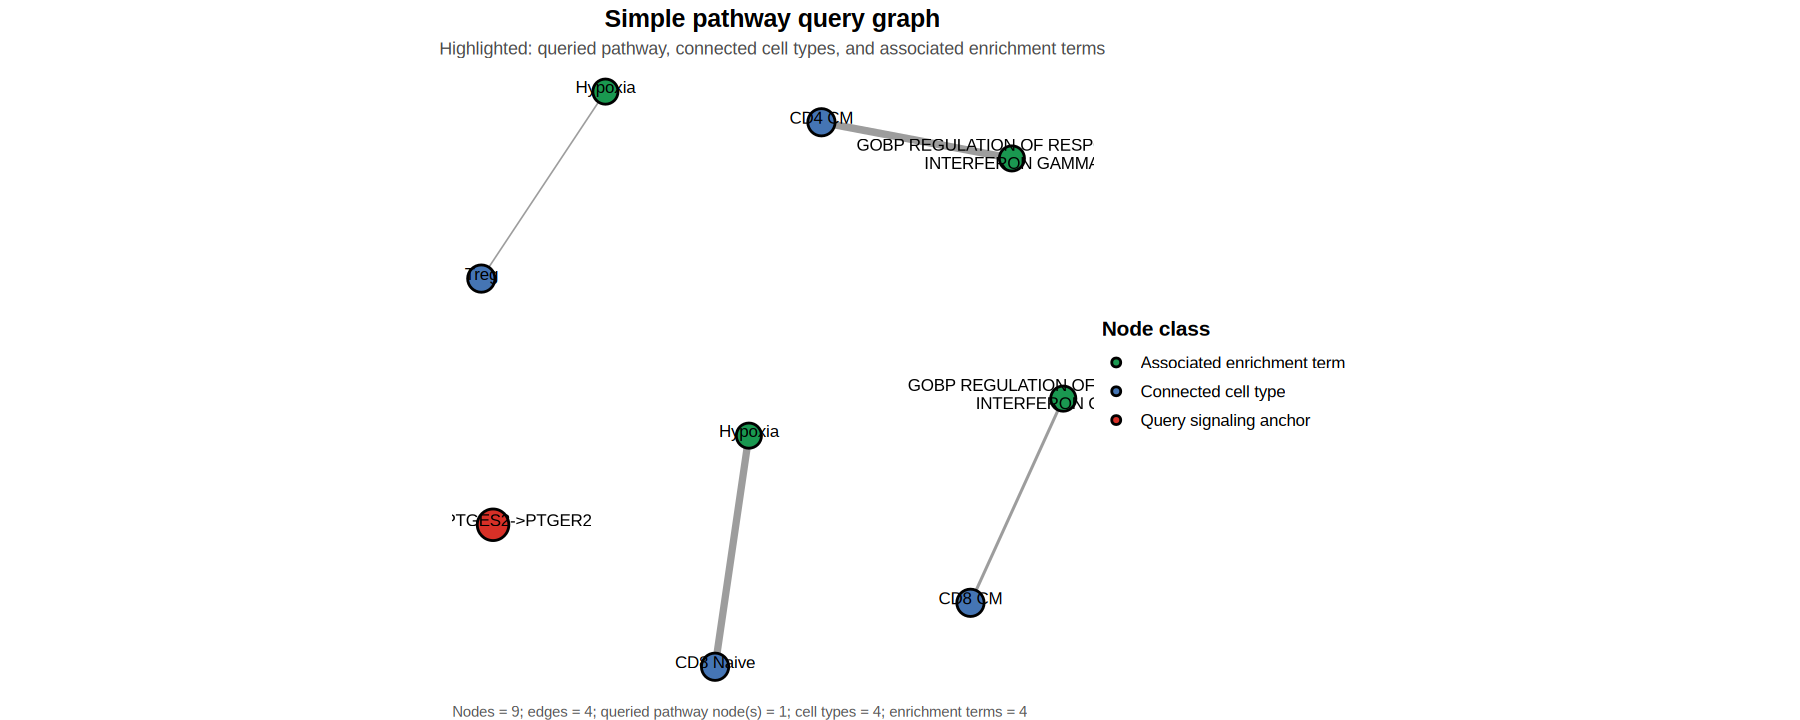

In [27]:
# ============================================================
# Example usage
# ============================================================
simple_query_graph_viz <- plot_query_axis_graph_simple(
   nodes = graph_nodes,
   edges = graph_edges,

   signaling_pattern = c(
     "PGE2–EP2/EP4" = "PGE2|PTGES2|PTGES3|PTGER2|PTGER4"
   ),

   response_focus = NULL,
   treatment_focus = NULL,

   receiver_exclude_regex = "PlasmaCells|Plasma cells|Plasma",
   receiver_include_regex = "NK|CD4|CD8|gdT|MAIT|Treg|CD14",

   query_top_n = 30,
   evidence_mode = "combined",
   only_positive = TRUE,
   top_n_phenotypes = 8,

   anchor_highlight_mode = "one_per_query",
   keep_only_direct_query_neighborhood = TRUE,
   include_shortest_paths = FALSE,
   include_first_neighbors = FALSE,

   title = "Simple pathway query graph",
   subtitle = paste0(
     "Highlighted: queried pathway, connected cell types, ",
     "and associated enrichment terms"
   ),

   out_dir = out_dir,
   file_prefix = "16_simple_query_graph_PGE2_EP2_EP4"
 )

simple_query_graph_viz$plot

## 10. Example query: phenotype connected to PGE2-EP2/EP4 signaling

response_focus = "Poor"
treatment_focus = "Post"


In [12]:
# ============================================================
# Isolated visualization function for answer_induced_phenotype()
# No method_keep needed.
# Uses direct_evidence_score / pagerank directly.
# Receiver-cell colors use dark Spectral palette.
# ============================================================

options(repr.plot.height = 6, repr.plot.width = 15)

suppressPackageStartupMessages({
  library(dplyr)
  library(stringr)
  library(ggplot2)
  library(readr)
  library(scales)
  library(RColorBrewer)
})

`%||%` <- function(x, y) {
  if (is.null(x)) y else x
}

plot_answer_induced_phenotype <- function(
  query_df = NULL,
  nodes = NULL,
  edges = NULL,
  signaling_pattern = NULL,

  response_focus = "Poor",
  treatment_focus = NULL,

  receiver_exclude_regex = NULL,
  receiver_include_regex = NULL,
  query_top_n = 30,
  negative_query_top_n = 5000,

  # evidence_mode:
  # "direct"   = direct_evidence_score
  # "pagerank" = pagerank
  # "combined" = rank by average scaled direct + pagerank
  evidence_mode = c("direct", "pagerank", "combined"),

  top_n_per_receiver = 6,

  # positive_or_negative:
  # "positive" = keep and rank scores > 0
  # "negative" = keep and rank scores < 0; strongest negative scores are ranked first
  positive_or_negative = c("positive", "negative"),

  title = NULL,
  subtitle = NULL,
  xlab = NULL,

  out_dir = ".",
  file_prefix = "query_induced_phenotypes_by_receiver",

  width = 11,
  height_per_row = 0.30,
  min_height = 5.5,
  max_height = 14,

  save_csv = TRUE,
  save_pdf = TRUE,
  save_png = TRUE
) {

  evidence_mode <- match.arg(evidence_mode)
  positive_or_negative <- match.arg(positive_or_negative)

  # ----------------------------
  # 1) Run query if query_df is not provided
  # ----------------------------
  if (is.null(query_df)) {
    if (is.null(nodes) || is.null(edges) || is.null(signaling_pattern)) {
      stop("Provide either query_df, or provide nodes, edges, and signaling_pattern.")
    }

    # In negative mode, the upstream query may otherwise return only top positive rows.
    # Pull a larger candidate pool so negative scores are available for filtering.
    query_top_n_use <- query_top_n
    if (positive_or_negative == "negative") {
      query_top_n_use <- max(query_top_n, negative_query_top_n, na.rm = TRUE)
    }

    query_df <- answer_induced_phenotype(
      nodes = nodes,
      edges = edges,
      signaling_pattern = signaling_pattern,
      response_focus = response_focus,
      treatment_focus = treatment_focus,
      receiver_exclude_regex = receiver_exclude_regex,
      receiver_include_regex = receiver_include_regex,
      top_n = query_top_n_use
    )
  }

  if (is.null(query_df) || nrow(query_df) == 0) {
    stop("The query result is empty.")
  }

  required_cols <- c("receiver_cell", "functional_pathway")
  missing_cols <- setdiff(required_cols, colnames(query_df))

  if (length(missing_cols) > 0) {
    stop(
      "Missing required columns: ",
      paste(missing_cols, collapse = ", "),
      "\nAvailable columns are:\n",
      paste(colnames(query_df), collapse = ", ")
    )
  }

  # ----------------------------
  # 2) Ensure score columns exist
  # ----------------------------
  if (!"direct_evidence_score" %in% colnames(query_df)) {
    query_df$direct_evidence_score <- NA_real_
  }

  if (!"pagerank" %in% colnames(query_df)) {
    query_df$pagerank <- NA_real_
  }

  # ----------------------------
  # 3) Label helpers
  # ----------------------------
  clean_pathway_label <- function(x) {
    x %>%
      as.character() %>%
      str_replace("^phenotype:", "") %>%
      str_replace("^pathway:", "") %>%
      str_replace("^enrichment:", "") %>%
      str_replace("^HALLMARK_", "HALLMARK: ") %>%
      str_replace("^PROGENy_", "PROGENy: ") %>%
      str_replace("^REACTOME_", "REACTOME: ") %>%
      str_replace("^KEGG_", "KEGG: ") %>%
      str_replace_all("_", " ") %>%
      str_squish()
  }

  clean_receiver_label <- function(x) {
    x %>%
      as.character() %>%
      str_replace_all("_", " ") %>%
      str_squish()
  }

  scale01 <- function(x) {
    x <- suppressWarnings(as.numeric(x))

    if (all(!is.finite(x))) {
      return(rep(NA_real_, length(x)))
    }

    rng <- range(x[is.finite(x)], na.rm = TRUE)

    if (diff(rng) == 0) {
      return(ifelse(is.finite(x), 1, NA_real_))
    }

    (x - rng[1]) / diff(rng)
  }

  # ----------------------------
  # Dark Spectral helper
  # ----------------------------
  darken_hex <- function(cols, factor = 0.68) {
    rgb_mat <- grDevices::col2rgb(cols) / 255
    rgb_mat <- rgb_mat * factor

    grDevices::rgb(
      red   = rgb_mat[1, ],
      green = rgb_mat[2, ],
      blue  = rgb_mat[3, ]
    )
  }

  make_dark_spectral_colors <- function(x, factor = 0.68) {
    x <- as.character(x)
    levs <- unique(x[!is.na(x)])

    if (length(levs) == 0) {
      return(NULL)
    }

    base_cols <- grDevices::colorRampPalette(
      RColorBrewer::brewer.pal(11, "Spectral")
    )(length(levs))

    dark_cols <- darken_hex(base_cols, factor = factor)
    names(dark_cols) <- levs

    dark_cols
  }

  # ----------------------------
  # 4) Prepare plotting data
  # ----------------------------
  plot_df <- query_df %>%
    mutate(
      receiver_cell_raw = as.character(receiver_cell),
      receiver_cell = clean_receiver_label(receiver_cell),
      functional_pathway = as.character(functional_pathway),
      direct_evidence_score = suppressWarnings(as.numeric(direct_evidence_score)),
      pagerank = suppressWarnings(as.numeric(pagerank))
    )

  if (!is.null(receiver_exclude_regex)) {
    plot_df <- plot_df %>%
      filter(!str_detect(receiver_cell_raw, regex(receiver_exclude_regex, ignore_case = TRUE)))
  }

  if (!is.null(receiver_include_regex)) {
    plot_df <- plot_df %>%
      filter(str_detect(receiver_cell_raw, regex(receiver_include_regex, ignore_case = TRUE)))
  }

  plot_df <- plot_df %>%
    filter(
      !is.na(receiver_cell),
      !is.na(functional_pathway)
    )

  if (evidence_mode == "direct") {
    plot_df <- plot_df %>%
      mutate(score = direct_evidence_score)

    score_label <- paste0(str_to_title(positive_or_negative), " direct evidence score")

  } else if (evidence_mode == "pagerank") {
    plot_df <- plot_df %>%
      mutate(score = pagerank)

    score_label <- "Personalized PageRank score"

  } else if (evidence_mode == "combined") {
    plot_df <- plot_df %>%
      mutate(
        direct_scaled = scale01(direct_evidence_score),
        pagerank_scaled = scale01(pagerank),
        score = rowMeans(
          cbind(direct_scaled, pagerank_scaled),
          na.rm = TRUE
        )
      )

    score_label <- "Combined scaled evidence score"
  }

  plot_df <- plot_df %>%
    filter(is.finite(score))

  if (positive_or_negative == "positive") {
    plot_df <- plot_df %>%
      filter(score > 0)
  } else if (positive_or_negative == "negative") {
    plot_df <- plot_df %>%
      filter(score < 0)
  }

  if (nrow(plot_df) == 0) {
    empty_msg <- paste0(
      "No ", positive_or_negative, " scores were found after receiver and score filtering. ",
      "Evidence mode: ", evidence_mode, "."
    )

    warning(empty_msg, call. = FALSE)

    title <- title %||% paste0(
      signaling_pattern %||% "Query",
      "-induced phenotypes in non-plasma receiver cells"
    )

    subtitle <- subtitle %||% paste0(
      "Evidence mode: ", evidence_mode,
      "; score direction: ", positive_or_negative,
      "; response focus: ", response_focus,
      if (!is.null(treatment_focus)) paste0("; treatment focus: ", treatment_focus) else ""
    )

    default_xlab <- if (evidence_mode == "direct") {
      paste0(str_to_title(positive_or_negative), " direct evidence score")
    } else if (evidence_mode == "pagerank") {
      "Personalized PageRank score"
    } else {
      "Combined scaled evidence score"
    }

    xlab <- xlab %||% default_xlab

    empty_plot_df <- data.frame(
      receiver_cell = character(),
      functional_pathway = character(),
      score = numeric(),
      direct_evidence_score = numeric(),
      pagerank = numeric(),
      n_records = integer(),
      score_rank = numeric(),
      pathway_label = character(),
      row_id = character(),
      stringsAsFactors = FALSE
    )

    p <- ggplot() +
      annotate(
        "text",
        x = 0,
        y = 0,
        label = empty_msg,
        size = 4.2
      ) +
      xlim(-1, 1) +
      ylim(-1, 1) +
      labs(
        title = title,
        subtitle = subtitle,
        x = xlab,
        y = NULL,
        caption = paste0(
          "Receiver filter: non-plasma only; ",
          "score direction: ", positive_or_negative,
          "; no rows available to rank."
        )
      ) +
      theme_void(base_size = 12) +
      theme(
        plot.title = element_text(face = "bold", size = 16, hjust = 0.5),
        plot.subtitle = element_text(size = 11, hjust = 0.5, color = "grey30"),
        plot.caption = element_text(size = 8.5, color = "grey35", hjust = 0),
        plot.margin = margin(10, 50, 10, 10)
      )

    dir.create(out_dir, recursive = TRUE, showWarnings = FALSE)

    file_suffix <- paste(evidence_mode, positive_or_negative, sep = "_")

    pdf_file <- file.path(out_dir, paste0(file_prefix, "_", file_suffix, ".pdf"))
    png_file <- file.path(out_dir, paste0(file_prefix, "_", file_suffix, ".png"))
    csv_file <- file.path(out_dir, paste0(file_prefix, "_", file_suffix, "_plot_data.csv.gz"))

    if (save_pdf) {
      ggsave(pdf_file, p, width = width, height = min_height, useDingbats = FALSE)
      message("Saved: ", pdf_file)
    }

    if (save_png) {
      ggsave(png_file, p, width = width, height = min_height, dpi = 300)
      message("Saved: ", png_file)
    }

    if (save_csv) {
      readr::write_csv(empty_plot_df, csv_file)
      message("Saved: ", csv_file)
    }

    return(list(
      result = query_df,
      plot_data = empty_plot_df,
      plot = p,
      files = list(
        pdf = pdf_file,
        png = png_file,
        csv = csv_file
      )
    ))
  }

  # Collapse duplicated receiver/pathway rows.
  # For positive mode, keep the largest positive score.
  # For negative mode, keep the most negative score.
  plot_df <- plot_df %>%
    group_by(receiver_cell, functional_pathway) %>%
    summarise(
      score = if (positive_or_negative == "negative") {
        min(score, na.rm = TRUE)
      } else {
        max(score, na.rm = TRUE)
      },
      direct_evidence_score = if (positive_or_negative == "negative") {
        min(direct_evidence_score, na.rm = TRUE)
      } else {
        max(direct_evidence_score, na.rm = TRUE)
      },
      pagerank = max(pagerank, na.rm = TRUE),
      n_records = n(),
      .groups = "drop"
    ) %>%
    mutate(score_rank = abs(score))

  # Top pathways per receiver.
  # Positive mode ranks largest positive values.
  # Negative mode ranks strongest negative values by absolute magnitude.
  plot_df <- plot_df %>%
    group_by(receiver_cell) %>%
    slice_max(order_by = score_rank, n = top_n_per_receiver, with_ties = FALSE) %>%
    ungroup()

  receiver_order <- plot_df %>%
    group_by(receiver_cell) %>%
    summarise(max_score_rank = max(score_rank, na.rm = TRUE), .groups = "drop") %>%
    arrange(desc(max_score_rank)) %>%
    pull(receiver_cell)

  plot_df <- plot_df %>%
    mutate(
      receiver_cell = factor(receiver_cell, levels = receiver_order),
      pathway_label = clean_pathway_label(functional_pathway)
    ) %>%
    arrange(receiver_cell, score) %>%
    mutate(
      row_id = paste(receiver_cell, functional_pathway, sep = "___"),
      row_id = factor(row_id, levels = unique(row_id))
    )

  # ----------------------------
  # 5) Plot
  # ----------------------------
  title <- title %||% paste0(
    signaling_pattern %||% "Query",
    "-induced phenotypes in non-plasma receiver cells"
  )

  subtitle <- subtitle %||% paste0(
    "Evidence mode: ", evidence_mode,
    "; score direction: ", positive_or_negative,
    "; response focus: ", response_focus,
    if (!is.null(treatment_focus)) paste0("; treatment focus: ", treatment_focus) else ""
  )

  xlab <- xlab %||% score_label

  if (positive_or_negative == "negative") {
    xmin <- min(plot_df$score, na.rm = TRUE) * 1.18
    xmax <- 0
    text_hjust <- 1.22
  } else {
    xmin <- 0
    xmax <- max(plot_df$score, na.rm = TRUE) * 1.18
    text_hjust <- -0.22
  }

  # Use dark Spectral colors, one color per receiver cell type.
  # The color names follow the ordered receiver_cell factor levels.
  receiver_cols <- make_dark_spectral_colors(levels(plot_df$receiver_cell), factor = 0.68)

  p <- ggplot(plot_df, aes(x = score, y = row_id, color = receiver_cell)) +
    geom_segment(
      aes(x = 0, xend = score, yend = row_id),
      linewidth = 0.8,
      alpha = 0.85
    ) +
    geom_point(size = 3.0) +
    geom_text(
      aes(label = number(score, accuracy = 0.01)),
      hjust = text_hjust,
      size = 3.1,
      color = "black"
    ) +
    scale_color_manual(
      values = receiver_cols,
      drop = FALSE
    ) +
    facet_grid(
      receiver_cell ~ .,
      scales = "free_y",
      space = "free_y",
      switch = "y"
    ) +
    scale_y_discrete(
      labels = function(x) {
        x %>%
          str_replace("^.*?___", "") %>%
          clean_pathway_label() %>%
          str_wrap(width = 45)
      }
    ) +
    scale_x_continuous(
      limits = c(xmin, xmax),
      expand = expansion(mult = c(0, 0.04))
    ) +
    labs(
      title = title,
      subtitle = subtitle,
      x = xlab,
      y = NULL,
      caption = paste0(
        "Receiver filter: non-plasma only; ",
        "score direction: ", positive_or_negative,
        "; pathways ranked within each receiver cell type."
      )
    ) +
    coord_cartesian(clip = "off") +
    theme_bw(base_size = 12) +
    theme(
      panel.background = element_blank(),
      plot.background = element_blank(),
      panel.grid.major.y = element_blank(),
      panel.grid.minor = element_blank(),
      panel.grid.major.x = element_line(color = "grey88", linewidth = 0.35),

      strip.placement = "outside",
      strip.background.y = element_blank(),
      strip.text.y.left = element_text(
        angle = 0,
        face = "bold",
        size = 11,
        hjust = 0.5,
        color = "black"
      ),

      axis.text.y = element_text(size = 9, color = "black"),
      axis.text.x = element_text(size = 10, color = "black"),
      axis.title.x = element_text(face = "bold", size = 11),

      plot.title = element_text(face = "bold", size = 16, hjust = 0.5),
      plot.subtitle = element_text(size = 11, hjust = 0.5, color = "grey30"),
      plot.caption = element_text(size = 8.5, color = "grey35", hjust = 0),

      legend.position = "none",
      plot.margin = margin(10, 50, 10, 10)
    )

  # ----------------------------
  # 6) Save
  # ----------------------------
  dir.create(out_dir, recursive = TRUE, showWarnings = FALSE)

  plot_height <- min(
    max_height,
    max(min_height, 1.8 + nrow(plot_df) * height_per_row)
  )

  file_suffix <- paste(evidence_mode, positive_or_negative, sep = "_")

  pdf_file <- file.path(out_dir, paste0(file_prefix, "_", file_suffix, ".pdf"))
  png_file <- file.path(out_dir, paste0(file_prefix, "_", file_suffix, ".png"))
  csv_file <- file.path(out_dir, paste0(file_prefix, "_", file_suffix, "_plot_data.csv.gz"))

  if (save_pdf) {
    ggsave(pdf_file, p, width = width, height = plot_height, useDingbats = FALSE)
    message("Saved: ", pdf_file)
  }

  if (save_png) {
    ggsave(png_file, p, width = width, height = plot_height, dpi = 300)
    message("Saved: ", png_file)
  }

  if (save_csv) {
    readr::write_csv(plot_df, csv_file)
    message("Saved: ", csv_file)
  }

  return(list(
    result = query_df,
    plot_data = plot_df,
    plot = p,
    files = list(
      pdf = pdf_file,
      png = png_file,
      csv = csv_file
    )
  ))
}

Saved: ./results/plasma_cellchat_ALNiche_axis_graph/15_query_PGE2_EP2_EP4_positive_phenotypes_by_nonplasma_receiver_NK_combined_positive.pdf

Saved: ./results/plasma_cellchat_ALNiche_axis_graph/15_query_PGE2_EP2_EP4_positive_phenotypes_by_nonplasma_receiver_NK_combined_positive.png

Saved: ./results/plasma_cellchat_ALNiche_axis_graph/15_query_PGE2_EP2_EP4_positive_phenotypes_by_nonplasma_receiver_NK_combined_positive_plot_data.csv.gz



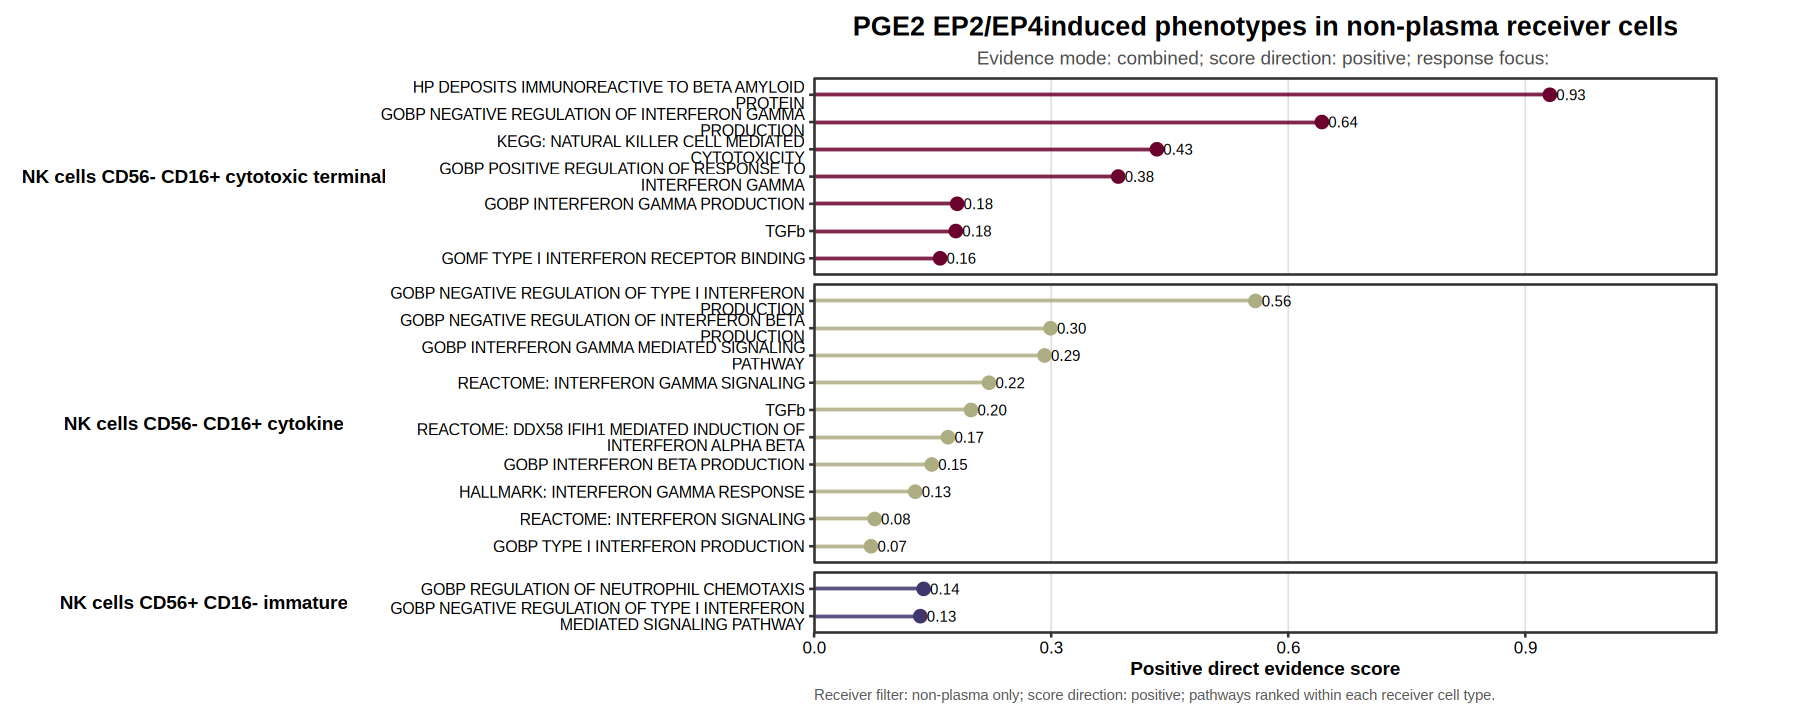

In [18]:
pge2_ep2_ep4_viz <- plot_answer_induced_phenotype(
  nodes = graph_nodes,
  edges = graph_edges,
  signaling_pattern = "PGE2|PTGES2|PTGES3|PTGER2|PTGER4",
  response_focus = NULL,
  treatment_focus = NULL,
  receiver_exclude_regex = 'PlasmaCells|Plasma cells|Plasma',
  receiver_include_regex = 'NK',
  query_top_n = 30,

  evidence_mode = "combined",
  top_n_per_receiver = 10,
  positive_or_negative = "positive" ,

  title = "PGE2 EP2/EP4induced phenotypes in non-plasma receiver cells",
  xlab = "Positive direct evidence score",

  out_dir = out_dir,
  file_prefix = "15_query_PGE2_EP2_EP4_positive_phenotypes_by_nonplasma_receiver_NK"
)

pge2_ep2_ep4_viz$plot



Saved: ./results/plasma_cellchat_ALNiche_axis_graph/15_query_PGE2_EP2_EP4_positive_phenotypes_by_nonplasma_receiver_T_combined_positive.pdf

Saved: ./results/plasma_cellchat_ALNiche_axis_graph/15_query_PGE2_EP2_EP4_positive_phenotypes_by_nonplasma_receiver_T_combined_positive.png

Saved: ./results/plasma_cellchat_ALNiche_axis_graph/15_query_PGE2_EP2_EP4_positive_phenotypes_by_nonplasma_receiver_T_combined_positive_plot_data.csv.gz



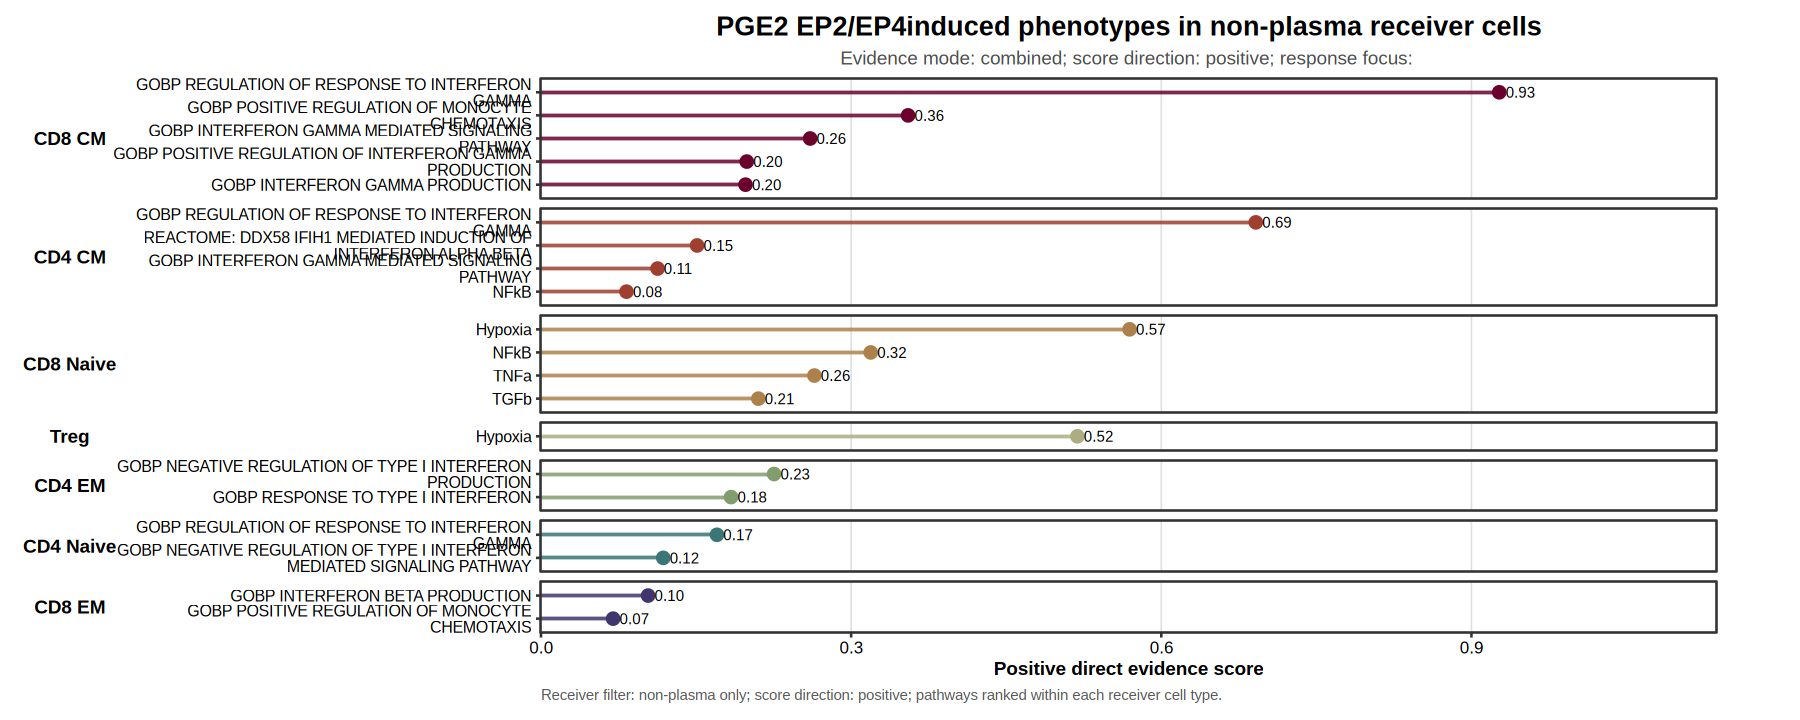

In [21]:
pge2_ep2_ep4_viz <- plot_answer_induced_phenotype(
  nodes = graph_nodes,
  edges = graph_edges,
  signaling_pattern = "PGE2|PTGES2|PTGES3|PTGER2|PTGER4",
  response_focus = NULL,
  treatment_focus = NULL,
  receiver_exclude_regex = 'PlasmaCells|Plasma cells|Plasma',
  receiver_include_regex = 'CD4|CD8|gdT|Treg',
  query_top_n = 30,

  evidence_mode = "combined",
  top_n_per_receiver = 10,
  positive_or_negative = "positive" ,

  title = "PGE2 EP2/EP4induced phenotypes in non-plasma receiver cells",
  xlab = "Positive direct evidence score",

  out_dir = out_dir,
  file_prefix = "15_query_PGE2_EP2_EP4_positive_phenotypes_by_nonplasma_receiver_T"
)

pge2_ep2_ep4_viz$plot



Saved: ./results/plasma_cellchat_ALNiche_axis_graph/15_query_PGE2_EP2_EP4_positive_phenotypes_by_nonplasma_receiver_myeloid_combined_positive.pdf

Saved: ./results/plasma_cellchat_ALNiche_axis_graph/15_query_PGE2_EP2_EP4_positive_phenotypes_by_nonplasma_receiver_myeloid_combined_positive.png

Saved: ./results/plasma_cellchat_ALNiche_axis_graph/15_query_PGE2_EP2_EP4_positive_phenotypes_by_nonplasma_receiver_myeloid_combined_positive_plot_data.csv.gz



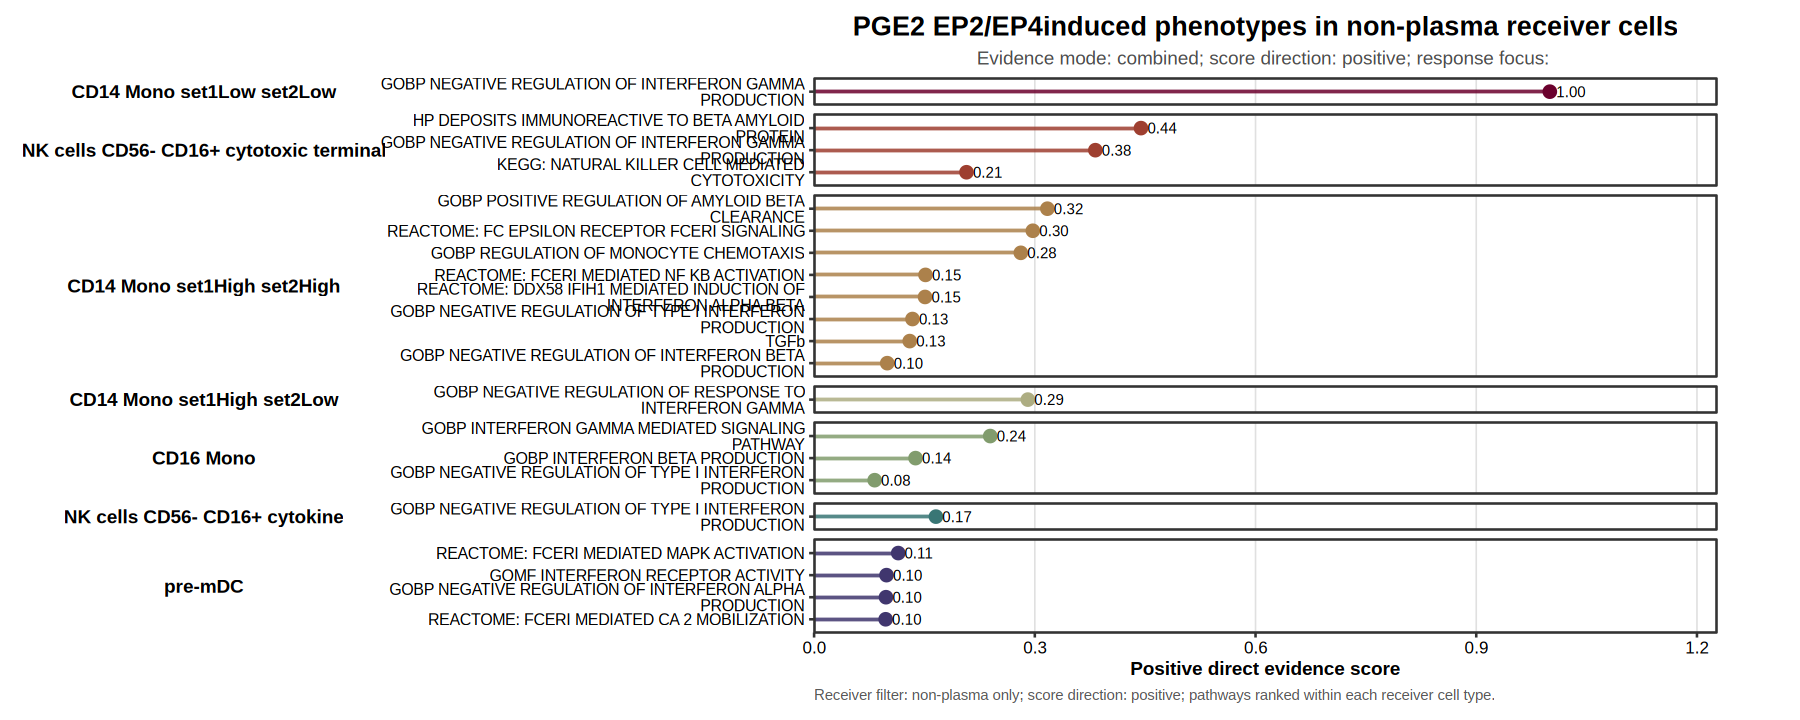

In [22]:
pge2_ep2_ep4_viz <- plot_answer_induced_phenotype(
  nodes = graph_nodes,
  edges = graph_edges,
  signaling_pattern = "PGE2|PTGES2|PTGES3|PTGER2|PTGER4",
  response_focus = NULL,
  treatment_focus = NULL,
  receiver_exclude_regex = 'PlasmaCells|Plasma cells|Plasma',
  receiver_include_regex = 'CD14|CD16|DC|Macro',
  query_top_n = 30,

  evidence_mode = "combined",
  top_n_per_receiver = 10,
  positive_or_negative = "positive" ,

  title = "PGE2 EP2/EP4induced phenotypes in non-plasma receiver cells",
  xlab = "Positive direct evidence score",

  out_dir = out_dir,
  file_prefix = "15_query_PGE2_EP2_EP4_positive_phenotypes_by_nonplasma_receiver_myeloid"
)

pge2_ep2_ep4_viz$plot



## 11. Other reusable query templates

Use these without rebuilding the graph.


sender_cell,sender_cell_for_enrichment,receiver_cell,pathway_name,ligand,receptor,LR,communication_axis
<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>
PlasmaCells,PlasmaCells,CD4_EM,MHC-I,HLA-E,KLRK1,HLA-E->KLRK1,PlasmaCells | HLA-E->KLRK1 | CD4_EM
PlasmaCells,PlasmaCells,CD4_Naive,MHC-I,HLA-E,KLRK1,HLA-E->KLRK1,PlasmaCells | HLA-E->KLRK1 | CD4_Naive
PlasmaCells,PlasmaCells,CD8_CM,MHC-I,HLA-E,KLRK1,HLA-E->KLRK1,PlasmaCells | HLA-E->KLRK1 | CD8_CM
PlasmaCells,PlasmaCells,CD8_EM,MHC-I,HLA-E,KLRK1,HLA-E->KLRK1,PlasmaCells | HLA-E->KLRK1 | CD8_EM
PlasmaCells,PlasmaCells,CD8_Naive,MHC-I,HLA-E,KLRK1,HLA-E->KLRK1,PlasmaCells | HLA-E->KLRK1 | CD8_Naive
PlasmaCells,PlasmaCells,CD8_TEMRA,MHC-I,HLA-E,KLRK1,HLA-E->KLRK1,PlasmaCells | HLA-E->KLRK1 | CD8_TEMRA
PlasmaCells,PlasmaCells,Colony Forming Unit-Granulocytes,MHC-I,HLA-E,KLRK1,HLA-E->KLRK1,PlasmaCells | HLA-E->KLRK1 | Colony Forming Unit-Granulocytes
PlasmaCells,PlasmaCells,Granulocytes (Neutrophils),MHC-I,HLA-E,KLRK1,HLA-E->KLRK1,PlasmaCells | HLA-E->KLRK1 | Granulocytes (Neutrophils)
PlasmaCells,PlasmaCells,MAIT,MHC-I,HLA-E,KLRK1,HLA-E->KLRK1,PlasmaCells | HLA-E->KLRK1 | MAIT


sender_cell,sender_cell_for_enrichment,sender_match_key,enrichment_cell
<chr>,<chr>,<chr>,<chr>
PlasmaCells,PlasmaCells,plasmacells,PlasmaCells


[1] "For each sample and sender-cell/LR axis, CellChat communication was aggregated across all receiver cell types before association with enrichment in the same sender-cell population."

Saved: ./results/plasma_cellchat_ALNiche_axis_graph/16_plasma_sender_HLAE_KLRK1_sender_enrichment_all_receivers.pdf

Saved: ./results/plasma_cellchat_ALNiche_axis_graph/16_plasma_sender_HLAE_KLRK1_sender_enrichment_all_receivers.png

Saved: ./results/plasma_cellchat_ALNiche_axis_graph/16_plasma_sender_HLAE_KLRK1_sender_enrichment_all_receivers_plot_data.csv.gz



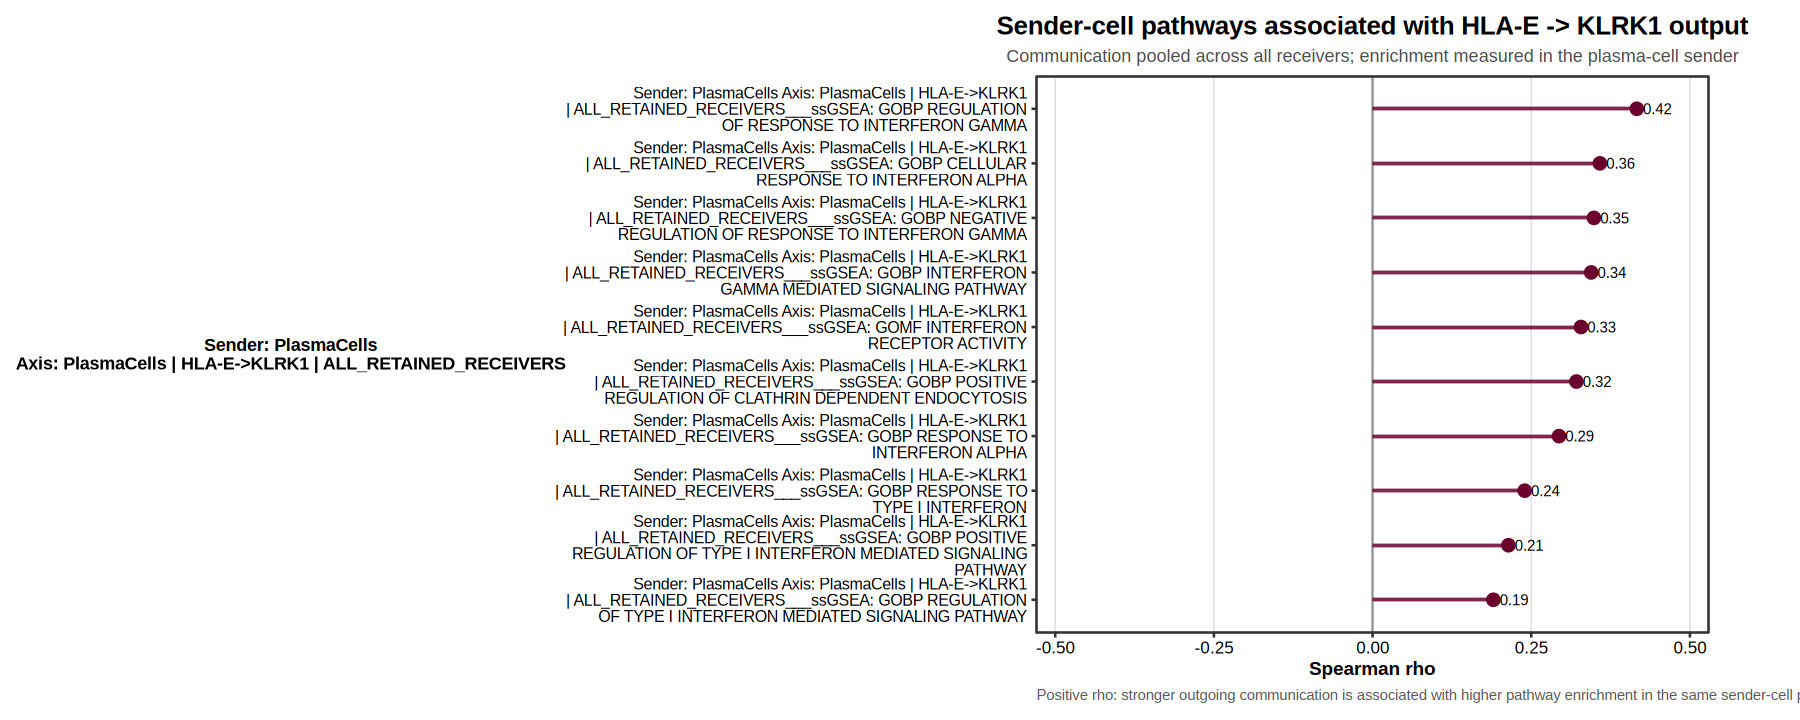

In [14]:
# ============================================================
# Sender-cell signaling -> sender-cell enrichment analysis
#
# This module answers:
#   Which pathways are enriched in cells that emit a selected
#   CellChat signaling axis?
#
# IMPORTANT:
#   This analysis must use the sample-level CellChat and enrichment
#   tables. Existing graph_edges encode receiver-cell enrichment and
#   cannot be relabeled as sender-cell enrichment.
#
# Required notebook objects:
#   cellchat_sample_edges_md
#   enrichment_sample_edges_md
# ============================================================

suppressPackageStartupMessages({
  library(dplyr)
  library(tidyr)
  library(stringr)
  library(ggplot2)
  library(readr)
  library(scales)
  library(RColorBrewer)
})

if (!exists("%||%", mode = "function")) {
  `%||%` <- function(x, y) if (is.null(x)) y else x
}


# ------------------------------------------------------------
# General helpers
# ------------------------------------------------------------

normalize_sender_text <- function(x) {
  x <- as.character(x)
  x <- gsub("[\u2212\u2010\u2011\u2012\u2013\u2014]", "-", x, perl = TRUE)
  x <- gsub("\u00A0", " ", x, fixed = TRUE)
  stringr::str_squish(x)
}


make_cell_match_key <- function(x) {
  x <- normalize_sender_text(x)
  x <- stringr::str_to_lower(x)
  gsub("[^a-z0-9]+", "", x, perl = TRUE)
}


collapse_sender_regex <- function(x) {
  if (is.null(x) || length(x) == 0) return(NULL)

  x <- normalize_sender_text(x)
  x <- x[!is.na(x) & nzchar(x)]

  if (length(x) == 0) return(NULL)
  paste(x, collapse = "|")
}


first_present_column <- function(df, candidates) {
  hit <- intersect(candidates, colnames(df))
  if (length(hit) == 0) return(NULL)
  hit[[1]]
}


safe_sender_spearman <- function(x, y, min_n = 4) {
  x <- suppressWarnings(as.numeric(x))
  y <- suppressWarnings(as.numeric(y))

  ok <- is.finite(x) & is.finite(y)
  n <- sum(ok)

  if (
    n < min_n ||
    dplyr::n_distinct(x[ok]) < 2 ||
    dplyr::n_distinct(y[ok]) < 2
  ) {
    return(tibble(
      n_samples = n,
      rho = NA_real_,
      p_value = NA_real_
    ))
  }

  tt <- tryCatch(
    suppressWarnings(
      stats::cor.test(
        x[ok],
        y[ok],
        method = "spearman",
        exact = FALSE
      )
    ),
    error = function(e) NULL
  )

  if (is.null(tt)) {
    return(tibble(
      n_samples = n,
      rho = NA_real_,
      p_value = NA_real_
    ))
  }

  tibble(
    n_samples = n,
    rho = unname(tt$estimate),
    p_value = tt$p.value
  )
}


summarise_communication_value <- function(x, method) {
  x <- suppressWarnings(as.numeric(x))
  x <- x[is.finite(x)]

  if (length(x) == 0) return(NA_real_)

  switch(
    method,
    sum = sum(x),
    mean = mean(x),
    max = max(x),
    stop("Unsupported communication summary: ", method)
  )
}


apply_named_cell_map <- function(x, cell_name_map = NULL) {
  x <- normalize_sender_text(x)

  if (is.null(cell_name_map)) {
    return(x)
  }

  if (is.null(names(cell_name_map)) || any(names(cell_name_map) == "")) {
    stop(
      "cell_name_map must be a named character vector. ",
      "Names are CellChat sender labels and values are enrichment-cell labels."
    )
  }

  map_names <- normalize_sender_text(names(cell_name_map))
  map_values <- normalize_sender_text(unname(cell_name_map))

  idx <- match(x, map_names)
  replace <- !is.na(idx)
  x[replace] <- map_values[idx[replace]]

  x
}


# ------------------------------------------------------------
# Standardize the two sample-level input tables
# ------------------------------------------------------------

standardize_sender_cellchat_table <- function(df) {
  colnames(df) <- trimws(colnames(df))

  sample_col <- first_present_column(
    df,
    c("sample_id", "sample", "Sample", "sampleID")
  )
  sender_col <- first_present_column(
    df,
    c("sender_cell", "source", "sender", "source_cell", "Sender")
  )
  receiver_col <- first_present_column(
    df,
    c("receiver_cell", "target", "receiver", "target_cell", "Receiver")
  )
  pathway_col <- first_present_column(
    df,
    c("pathway_name", "pathway", "signaling_pathway")
  )
  ligand_col <- first_present_column(
    df,
    c("ligand", "Ligand")
  )
  receptor_col <- first_present_column(
    df,
    c("receptor", "Receptor")
  )
  interaction_col <- first_present_column(
    df,
    c("interaction_name_2", "interaction_name", "interaction")
  )
  lr_col <- first_present_column(
    df,
    c("LR", "ligand_receptor", "lr_pair")
  )
  axis_col <- first_present_column(
    df,
    c("communication_axis", "signaling_axis")
  )
  score_col <- first_present_column(
    df,
    c(
      "comm_score", "prob", "communication_probability",
      "comm_prob_sum", "comm_prob_mean", "weight"
    )
  )

  required_missing <- c(
    if (is.null(sample_col)) "sample_id",
    if (is.null(sender_col)) "sender_cell/source",
    if (is.null(receiver_col)) "receiver_cell/target",
    if (is.null(score_col)) "comm_score/prob"
  )

  if (length(required_missing) > 0) {
    stop(
      "CellChat table is missing required columns: ",
      paste(required_missing, collapse = ", "),
      "\nAvailable columns: ",
      paste(colnames(df), collapse = ", ")
    )
  }

  out <- tibble(
    sample_id = as.character(df[[sample_col]]),
    sender_cell = normalize_sender_text(df[[sender_col]]),
    receiver_cell = normalize_sender_text(df[[receiver_col]]),
    pathway_name = if (!is.null(pathway_col)) {
      normalize_sender_text(df[[pathway_col]])
    } else {
      NA_character_
    },
    ligand = if (!is.null(ligand_col)) {
      normalize_sender_text(df[[ligand_col]])
    } else {
      NA_character_
    },
    receptor = if (!is.null(receptor_col)) {
      normalize_sender_text(df[[receptor_col]])
    } else {
      NA_character_
    },
    interaction_name_2 = if (!is.null(interaction_col)) {
      normalize_sender_text(df[[interaction_col]])
    } else {
      NA_character_
    },
    LR = if (!is.null(lr_col)) {
      normalize_sender_text(df[[lr_col]])
    } else {
      NA_character_
    },
    communication_axis = if (!is.null(axis_col)) {
      normalize_sender_text(df[[axis_col]])
    } else {
      NA_character_
    },
    comm_score = suppressWarnings(as.numeric(df[[score_col]]))
  )

  for (nm in c("response", "treatment", "resp_group")) {
    out[[nm]] <- if (nm %in% colnames(df)) {
      normalize_sender_text(df[[nm]])
    } else {
      NA_character_
    }
  }

  out <- out %>%
    mutate(
      LR = case_when(
        !is.na(LR) & nzchar(LR) ~ LR,
        !is.na(ligand) & nzchar(ligand) &
          !is.na(receptor) & nzchar(receptor) ~
          paste0(ligand, "->", receptor),
        TRUE ~ interaction_name_2
      ),
      communication_axis = case_when(
        !is.na(communication_axis) & nzchar(communication_axis) ~
          communication_axis,
        TRUE ~ paste(sender_cell, LR, receiver_cell, sep = " | ")
      )
    ) %>%
    filter(
      !is.na(sample_id),
      nzchar(sample_id),
      !is.na(sender_cell),
      nzchar(sender_cell),
      !is.na(receiver_cell),
      nzchar(receiver_cell),
      is.finite(comm_score)
    )

  out
}


standardize_sender_enrichment_table <- function(df) {
  colnames(df) <- trimws(colnames(df))

  sample_col <- first_present_column(
    df,
    c("sample_id", "sample", "Sample", "sampleID")
  )
  cell_col <- first_present_column(
    df,
    c(
      "receiver_cell", "sender_cell", "Annotation", "Nover",
      "celltype", "cell_type", "cell_annotation"
    )
  )
  method_col <- first_present_column(
    df,
    c("Method", "method")
  )
  pathway_col <- first_present_column(
    df,
    c("functional_pathway", "pathway", "gene_set", "geneset")
  )
  score_col <- first_present_column(
    df,
    c(
      "mean_score_z", "score_z", "NES", "mean_NES",
      "score", "score_raw"
    )
  )

  required_missing <- c(
    if (is.null(sample_col)) "sample_id",
    if (is.null(cell_col)) "cell annotation",
    if (is.null(pathway_col)) "functional pathway",
    if (is.null(score_col)) "enrichment score"
  )

  if (length(required_missing) > 0) {
    stop(
      "Enrichment table is missing required columns: ",
      paste(required_missing, collapse = ", "),
      "\nAvailable columns: ",
      paste(colnames(df), collapse = ", ")
    )
  }

  out <- tibble(
    sample_id = as.character(df[[sample_col]]),
    enrichment_cell = normalize_sender_text(df[[cell_col]]),
    Method = if (!is.null(method_col)) {
      normalize_sender_text(df[[method_col]])
    } else {
      "enrichment"
    },
    functional_pathway = normalize_sender_text(df[[pathway_col]]),
    sender_enrichment_score =
      suppressWarnings(as.numeric(df[[score_col]]))
  )

  for (nm in c("response", "treatment", "resp_group")) {
    out[[nm]] <- if (nm %in% colnames(df)) {
      normalize_sender_text(df[[nm]])
    } else {
      NA_character_
    }
  }

  out %>%
    filter(
      !is.na(sample_id),
      nzchar(sample_id),
      !is.na(enrichment_cell),
      nzchar(enrichment_cell),
      !is.na(functional_pathway),
      nzchar(functional_pathway),
      is.finite(sender_enrichment_score)
    )
}


# ------------------------------------------------------------
# Main analysis
# ------------------------------------------------------------

answer_sender_cell_enrichment <- function(
    cellchat_sample_edges,
    enrichment_sample_edges,

    sender_include_regex,
    signaling_pattern,

    sender_exclude_regex = NULL,
    receiver_include_regex = NULL,
    receiver_exclude_regex = NULL,

    # "per_receiver":
    #   Keep each sender -> receiver signaling axis separate.
    #
    # "pooled_receivers":
    #   Aggregate outgoing signaling across all retained receivers for
    #   each sender and LR pair before association testing.
    outgoing_scope = c("per_receiver", "pooled_receivers"),

    communication_summary = c("sum", "mean", "max"),

    response_focus = NULL,
    treatment_focus = NULL,
    resp_group_focus = NULL,

    fill_missing_communication_with_zero = TRUE,

    # Optional named vector:
    # c("CellChat sender label" = "enrichment cell label")
    cell_name_map = NULL,

    min_samples = 4,
    direction = c("positive", "negative", "both"),
    padj_cutoff = NULL,
    min_abs_rho = 0,

    top_n_per_facet = NULL
) {
  outgoing_scope <- match.arg(outgoing_scope)
  communication_summary <- match.arg(communication_summary)
  direction <- match.arg(direction)

  sender_pat <- collapse_sender_regex(sender_include_regex)
  sender_exclude_pat <- collapse_sender_regex(sender_exclude_regex)
  signaling_pat <- collapse_sender_regex(signaling_pattern)
  receiver_include_pat <- collapse_sender_regex(receiver_include_regex)
  receiver_exclude_pat <- collapse_sender_regex(receiver_exclude_regex)

  if (is.null(sender_pat)) {
    stop("sender_include_regex must contain at least one non-empty pattern.")
  }

  if (is.null(signaling_pat)) {
    stop("signaling_pattern must contain at least one non-empty pattern.")
  }

  comm <- standardize_sender_cellchat_table(cellchat_sample_edges)
  enrich <- standardize_sender_enrichment_table(enrichment_sample_edges)

  # Apply optional explicit mapping before generating cell-match keys.
  comm <- comm %>%
    mutate(
      sender_cell_for_enrichment =
        apply_named_cell_map(sender_cell, cell_name_map),
      sender_match_key =
        make_cell_match_key(sender_cell_for_enrichment),
      signal_search_text = paste(
        coalesce(pathway_name, ""),
        coalesce(ligand, ""),
        coalesce(receptor, ""),
        coalesce(LR, ""),
        coalesce(interaction_name_2, ""),
        coalesce(communication_axis, ""),
        sep = " | "
      )
    )

  enrich <- enrich %>%
    mutate(
      sender_match_key = make_cell_match_key(enrichment_cell)
    )

  # Context filters.
  if (!is.null(response_focus)) {
    if (all(is.na(comm$response)) || all(is.na(enrich$response))) {
      stop(
        "response_focus was supplied, but response metadata is unavailable ",
        "in one or both input tables."
      )
    }

    response_pat <- collapse_sender_regex(response_focus)

    comm <- comm %>%
      filter(str_detect(
        coalesce(response, ""),
        regex(response_pat, ignore_case = TRUE)
      ))

    enrich <- enrich %>%
      filter(str_detect(
        coalesce(response, ""),
        regex(response_pat, ignore_case = TRUE)
      ))
  }

  if (!is.null(treatment_focus)) {
    if (all(is.na(comm$treatment)) || all(is.na(enrich$treatment))) {
      stop(
        "treatment_focus was supplied, but treatment metadata is unavailable ",
        "in one or both input tables."
      )
    }

    treatment_pat <- collapse_sender_regex(treatment_focus)

    comm <- comm %>%
      filter(str_detect(
        coalesce(treatment, ""),
        regex(treatment_pat, ignore_case = TRUE)
      ))

    enrich <- enrich %>%
      filter(str_detect(
        coalesce(treatment, ""),
        regex(treatment_pat, ignore_case = TRUE)
      ))
  }

  if (!is.null(resp_group_focus)) {
    if (all(is.na(comm$resp_group)) || all(is.na(enrich$resp_group))) {
      stop(
        "resp_group_focus was supplied, but resp_group metadata is unavailable ",
        "in one or both input tables."
      )
    }

    resp_group_pat <- collapse_sender_regex(resp_group_focus)

    comm <- comm %>%
      filter(str_detect(
        coalesce(resp_group, ""),
        regex(resp_group_pat, ignore_case = TRUE)
      ))

    enrich <- enrich %>%
      filter(str_detect(
        coalesce(resp_group, ""),
        regex(resp_group_pat, ignore_case = TRUE)
      ))
  }

  # Signaling, sender, and optional receiver filters.
  comm_signal_before_sender <- comm %>%
    filter(str_detect(
      signal_search_text,
      regex(signaling_pat, ignore_case = TRUE)
    ))

  comm_sender_before_signal <- comm %>%
    filter(str_detect(
      sender_cell,
      regex(sender_pat, ignore_case = TRUE)
    ))

  comm <- comm_signal_before_sender %>%
    filter(str_detect(
      sender_cell,
      regex(sender_pat, ignore_case = TRUE)
    ))

  if (!is.null(sender_exclude_pat)) {
    comm <- comm %>%
      filter(!str_detect(
        sender_cell,
        regex(sender_exclude_pat, ignore_case = TRUE)
      ))
  }

  if (!is.null(receiver_include_pat)) {
    comm <- comm %>%
      filter(str_detect(
        receiver_cell,
        regex(receiver_include_pat, ignore_case = TRUE)
      ))
  }

  if (!is.null(receiver_exclude_pat)) {
    comm <- comm %>%
      filter(!str_detect(
        receiver_cell,
        regex(receiver_exclude_pat, ignore_case = TRUE)
      ))
  }

  if (nrow(comm) == 0) {
    signal_examples <- comm_signal_before_sender %>%
      distinct(
        sender_cell, receiver_cell, pathway_name,
        ligand, receptor, LR, communication_axis
      ) %>%
      slice_head(n = 25)

    sender_examples <- comm_sender_before_signal %>%
      filter(str_detect(
        signal_search_text,
        regex("HLA|MHC|CD1D|MR1", ignore_case = TRUE)
      )) %>%
      distinct(
        sender_cell, receiver_cell, pathway_name,
        ligand, receptor, LR, communication_axis
      ) %>%
      slice_head(n = 25)

    stop(
      paste0(
        "No CellChat rows remained after signaling, sender, and receiver filters.\n\n",
        "Signaling pattern: ", signaling_pat, "\n",
        "Sender pattern: ", sender_pat, "\n",
        "Receiver include pattern: ",
        receiver_include_pat %||% "NULL", "\n",
        "Receiver exclude pattern: ",
        receiver_exclude_pat %||% "NULL", "\n\n",
        "Rows matching signaling before sender filtering: ",
        nrow(comm_signal_before_sender), "\n",
        "Rows matching sender before signaling filtering: ",
        nrow(comm_sender_before_signal), "\n\n",
        "Inspect these objects after running the standardization helpers:\n",
        "  standardize_sender_cellchat_table(cellchat_sample_edges)\n",
        "  standardize_sender_enrichment_table(enrichment_sample_edges)\n\n",
        "Example signal matches:\n",
        paste(capture.output(print(signal_examples)), collapse = "\n"),
        "\n\nExample HLA/MHC axes from requested senders:\n",
        paste(capture.output(print(sender_examples)), collapse = "\n")
      ),
      call. = FALSE
    )
  }

  # Aggregate duplicate CellChat rows within each sample and axis.
  if (outgoing_scope == "per_receiver") {
    comm_agg <- comm %>%
      group_by(
        sample_id,
        sender_cell,
        sender_cell_for_enrichment,
        sender_match_key,
        receiver_cell,
        pathway_name,
        ligand,
        receptor,
        interaction_name_2,
        LR,
        communication_axis
      ) %>%
      summarise(
        comm_score = summarise_communication_value(
          comm_score,
          communication_summary
        ),
        .groups = "drop"
      )
  } else {
    comm_agg <- comm %>%
      group_by(
        sample_id,
        sender_cell,
        sender_cell_for_enrichment,
        sender_match_key,
        pathway_name,
        ligand,
        receptor,
        interaction_name_2,
        LR
      ) %>%
      summarise(
        comm_score = summarise_communication_value(
          comm_score,
          communication_summary
        ),
        n_receivers_observed = n_distinct(receiver_cell),
        .groups = "drop"
      ) %>%
      mutate(
        receiver_cell = "ALL_RETAINED_RECEIVERS",
        communication_axis = paste(
          sender_cell,
          LR,
          receiver_cell,
          sep = " | "
        )
      )
  }

  # Aggregate duplicate enrichment entries within sample/cell/pathway.
  enrich_agg <- enrich %>%
    group_by(
      sample_id,
      enrichment_cell,
      sender_match_key,
      Method,
      functional_pathway
    ) %>%
    summarise(
      sender_enrichment_score =
        mean(sender_enrichment_score, na.rm = TRUE),
      .groups = "drop"
    ) %>%
    filter(is.finite(sender_enrichment_score))

  # Diagnostic cell matching.
  selected_sender_cells <- comm_agg %>%
    distinct(
      sender_cell,
      sender_cell_for_enrichment,
      sender_match_key
    )

  available_enrichment_cells <- enrich_agg %>%
    distinct(enrichment_cell, sender_match_key)

  sender_cell_match_table <- selected_sender_cells %>%
    left_join(
      available_enrichment_cells,
      by = "sender_match_key",
      relationship = "many-to-many"
    )

  unmatched_senders <- sender_cell_match_table %>%
    filter(is.na(enrichment_cell)) %>%
    distinct(
      sender_cell,
      sender_cell_for_enrichment,
      sender_match_key
    )

  if (nrow(unmatched_senders) > 0) {
    stop(
      paste0(
        "The selected CellChat sender labels do not have matching enrichment ",
        "cell labels.\n\nUnmatched sender labels:\n",
        paste(capture.output(print(unmatched_senders)), collapse = "\n"),
        "\n\nAvailable enrichment-cell labels:\n",
        paste(
          capture.output(
            print(
              available_enrichment_cells %>%
                arrange(enrichment_cell) %>%
                slice_head(n = 100)
            )
          ),
          collapse = "\n"
        ),
        "\n\nUse cell_name_map when the labels differ, for example:\n",
        "  cell_name_map = c(\n",
        "    'CellChat sender label' = 'enrichment cell label'\n",
        "  )"
      ),
      call. = FALSE
    )
  }

  # Optionally represent an unobserved communication axis as zero in
  # samples where the sender-cell enrichment was measured.
  if (isTRUE(fill_missing_communication_with_zero)) {
    axis_id_cols <- c(
      "sender_cell",
      "sender_cell_for_enrichment",
      "sender_match_key",
      "receiver_cell",
      "pathway_name",
      "ligand",
      "receptor",
      "interaction_name_2",
      "LR",
      "communication_axis"
    )

    axis_meta <- comm_agg %>%
      distinct(across(all_of(axis_id_cols)))

    sender_sample_grid <- enrich_agg %>%
      distinct(sample_id, sender_match_key)

    comm_grid <- sender_sample_grid %>%
      inner_join(
        axis_meta,
        by = "sender_match_key",
        relationship = "many-to-many"
      )

    comm_agg <- comm_grid %>%
      left_join(
        comm_agg,
        by = c("sample_id", axis_id_cols)
      ) %>%
      mutate(
        comm_score = replace_na(comm_score, 0)
      )
  }

  # CRITICAL JOIN:
  # enrichment is aligned to sender_match_key, not receiver_cell.
  joined_sender_level <- comm_agg %>%
    inner_join(
      enrich_agg,
      by = c("sample_id", "sender_match_key"),
      relationship = "many-to-many"
    )

  if (nrow(joined_sender_level) == 0) {
    stop(
      "No sample-level rows remained after joining communication to ",
      "sender-cell enrichment on sample_id + sender_match_key."
    )
  }

  grouping_cols <- c(
    "sender_cell",
    "sender_cell_for_enrichment",
    "enrichment_cell",
    "receiver_cell",
    "pathway_name",
    "ligand",
    "receptor",
    "interaction_name_2",
    "LR",
    "communication_axis",
    "Method",
    "functional_pathway"
  )

  results <- joined_sender_level %>%
    group_by(across(all_of(grouping_cols))) %>%
    group_modify(
      ~ safe_sender_spearman(
        .x$comm_score,
        .x$sender_enrichment_score,
        min_n = min_samples
      )
    ) %>%
    ungroup() %>%
    mutate(
      padj = p.adjust(p_value, method = "BH"),
      abs_rho = abs(rho),
      association_direction = case_when(
        rho > 0 ~ "positive",
        rho < 0 ~ "negative",
        TRUE ~ "flat_or_unavailable"
      ),
      interpretation = case_when(
        rho > 0 ~ paste0(
          "Across samples, stronger outgoing signaling is associated with ",
          "higher pathway enrichment in the sender cell."
        ),
        rho < 0 ~ paste0(
          "Across samples, stronger outgoing signaling is associated with ",
          "lower pathway enrichment in the sender cell."
        ),
        TRUE ~ "Association could not be estimated."
      )
    )

  # Add descriptive means without changing the correlation grouping.
  descriptive <- joined_sender_level %>%
    group_by(across(all_of(grouping_cols))) %>%
    summarise(
      mean_comm_score = mean(comm_score, na.rm = TRUE),
      mean_sender_enrichment =
        mean(sender_enrichment_score, na.rm = TRUE),
      .groups = "drop"
    )

  results <- results %>%
    left_join(
      descriptive,
      by = grouping_cols
    ) %>%
    filter(is.finite(rho))

  results <- switch(
    direction,
    positive = results %>% filter(rho > 0),
    negative = results %>% filter(rho < 0),
    both = results %>% filter(rho != 0)
  )

  if (!is.null(min_abs_rho) && is.finite(min_abs_rho)) {
    results <- results %>%
      filter(abs_rho >= min_abs_rho)
  }

  if (!is.null(padj_cutoff)) {
    results <- results %>%
      filter(is.finite(padj), padj <= padj_cutoff)
  }

  if (!is.null(top_n_per_facet) && is.finite(top_n_per_facet)) {
    facet_group_cols <- if (outgoing_scope == "per_receiver") {
      c("sender_cell", "receiver_cell", "communication_axis")
    } else {
      c("sender_cell", "communication_axis")
    }

    results <- results %>%
      group_by(across(all_of(facet_group_cols))) %>%
      slice_max(
        order_by = abs_rho,
        n = top_n_per_facet,
        with_ties = FALSE
      ) %>%
      ungroup()
  }

  results <- results %>%
    arrange(
      sender_cell,
      receiver_cell,
      communication_axis,
      desc(abs_rho),
      padj,
      functional_pathway
    )

  attr(results, "joined_sender_sample_level") <- joined_sender_level
  attr(results, "selected_cellchat_axes") <- comm %>%
    distinct(
      sender_cell,
      sender_cell_for_enrichment,
      receiver_cell,
      pathway_name,
      ligand,
      receptor,
      LR,
      communication_axis
    ) %>%
    arrange(sender_cell, receiver_cell, LR)
  attr(results, "sender_cell_match_table") <- sender_cell_match_table
  attr(results, "settings") <- list(
    sender_include_regex = sender_pat,
    sender_exclude_regex = sender_exclude_pat,
    signaling_pattern = signaling_pat,
    receiver_include_regex = receiver_include_pat,
    receiver_exclude_regex = receiver_exclude_pat,
    outgoing_scope = outgoing_scope,
    communication_summary = communication_summary,
    response_focus = response_focus,
    treatment_focus = treatment_focus,
    resp_group_focus = resp_group_focus,
    fill_missing_communication_with_zero =
      fill_missing_communication_with_zero,
    min_samples = min_samples,
    direction = direction,
    padj_cutoff = padj_cutoff,
    min_abs_rho = min_abs_rho
  )

  results
}


# ------------------------------------------------------------
# Plot sender-cell enrichment associations
# ------------------------------------------------------------

plot_sender_cell_enrichment <- function(
    query_df,
    top_n_per_facet = 10,
    facet_by = c(
      "sender_receiver_axis",
      "sender_receiver",
      "sender_axis",
      "sender"
    ),
    title = NULL,
    subtitle = NULL,
    xlab = "Spearman rho",
    out_dir = ".",
    file_prefix = "sender_cell_signaling_sender_enrichment",
    width = 12,
    height_per_row = 0.30,
    min_height = 5.5,
    max_height = 16,
    save_csv = TRUE,
    save_pdf = TRUE,
    save_png = TRUE
) {
  facet_by <- match.arg(facet_by)

  required_cols <- c(
    "sender_cell",
    "receiver_cell",
    "communication_axis",
    "Method",
    "functional_pathway",
    "rho"
  )

  missing_cols <- setdiff(required_cols, colnames(query_df))
  if (length(missing_cols) > 0) {
    stop(
      "query_df is missing required columns: ",
      paste(missing_cols, collapse = ", ")
    )
  }

  if (nrow(query_df) == 0) {
    stop("query_df is empty after association filtering.")
  }

  clean_pathway_label <- function(method, pathway) {
    pathway2 <- normalize_sender_text(pathway) %>%
      str_replace("^phenotype:", "") %>%
      str_replace("^pathway:", "") %>%
      str_replace("^enrichment:", "") %>%
      str_replace("^HALLMARK_", "HALLMARK: ") %>%
      str_replace("^PROGENy_", "PROGENy: ") %>%
      str_replace("^REACTOME_", "REACTOME: ") %>%
      str_replace("^KEGG_", "KEGG: ") %>%
      str_replace_all("_", " ") %>%
      str_squish()

    method2 <- normalize_sender_text(method)

    ifelse(
      is.na(method2) | method2 == "",
      pathway2,
      paste0(method2, ": ", pathway2)
    )
  }

  plot_df <- query_df %>%
    mutate(
      sender_cell = normalize_sender_text(sender_cell),
      receiver_cell = normalize_sender_text(receiver_cell),
      rho = suppressWarnings(as.numeric(rho)),
      abs_rho = abs(rho),
      function_label =
        clean_pathway_label(Method, functional_pathway),
      facet_label = case_when(
        facet_by == "sender_receiver_axis" ~ paste0(
          "Sender: ", sender_cell,
          "  ->  Receiver: ", receiver_cell,
          "\nAxis: ", communication_axis
        ),
        facet_by == "sender_receiver" ~ paste0(
          "Sender: ", sender_cell,
          "  ->  Receiver: ", receiver_cell
        ),
        facet_by == "sender_axis" ~ paste0(
          "Sender: ", sender_cell,
          "\nAxis: ", communication_axis
        ),
        facet_by == "sender" ~ paste0(
          "Sender: ", sender_cell
        )
      )
    ) %>%
    filter(is.finite(rho)) %>%
    group_by(facet_label) %>%
    slice_max(
      order_by = abs_rho,
      n = top_n_per_facet,
      with_ties = FALSE
    ) %>%
    ungroup()

  facet_order <- plot_df %>%
    group_by(facet_label) %>%
    summarise(
      max_abs_rho = max(abs_rho, na.rm = TRUE),
      .groups = "drop"
    ) %>%
    arrange(desc(max_abs_rho), facet_label) %>%
    pull(facet_label)

  plot_df <- plot_df %>%
    mutate(
      facet_label = factor(facet_label, levels = facet_order)
    ) %>%
    arrange(facet_label, rho) %>%
    mutate(
      plot_row_number = row_number(),
      row_id = paste(
        facet_label,
        function_label,
        paste0("row", plot_row_number),
        sep = "___"
      ),
      row_id = factor(row_id, levels = unique(row_id))
    )

  sender_levels <- unique(plot_df$sender_cell)

  base_cols <- grDevices::colorRampPalette(
    RColorBrewer::brewer.pal(11, "Spectral")
  )(length(sender_levels))

  rgb_mat <- grDevices::col2rgb(base_cols) / 255

  sender_cols <- grDevices::rgb(
    rgb_mat[1, ] * 0.68,
    rgb_mat[2, ] * 0.68,
    rgb_mat[3, ] * 0.68
  )

  names(sender_cols) <- sender_levels

  score_limit <- max(abs(plot_df$rho), na.rm = TRUE) * 1.20
  if (!is.finite(score_limit) || score_limit == 0) score_limit <- 1

  title <- title %||%
    "Sender-cell pathways associated with outgoing signaling"

  subtitle <- subtitle %||% paste0(
    "Enrichment is measured in the signaling sender; ",
    "associations are cross-sample Spearman correlations"
  )

  p <- ggplot(
    plot_df,
    aes(
      x = rho,
      y = row_id,
      color = sender_cell
    )
  ) +
    geom_vline(
      xintercept = 0,
      linewidth = 0.45,
      color = "grey55"
    ) +
    geom_segment(
      aes(
        x = 0,
        xend = rho,
        yend = row_id
      ),
      linewidth = 0.8,
      alpha = 0.85
    ) +
    geom_point(size = 3.0) +
    geom_text(
      aes(
        label = scales::number(
          rho,
          accuracy = 0.01
        )
      ),
      hjust = ifelse(plot_df$rho >= 0, -0.22, 1.22),
      size = 3.0,
      color = "black"
    ) +
    scale_color_manual(
      values = sender_cols,
      drop = FALSE
    ) +
    facet_grid(
      facet_label ~ .,
      scales = "free_y",
      space = "free_y",
      switch = "y"
    ) +
    scale_y_discrete(
      labels = function(x) {
        x %>%
          str_replace("^.*?___", "") %>%
          str_replace("___row[0-9]+$", "") %>%
          str_wrap(width = 52)
      }
    ) +
    scale_x_continuous(
      limits = c(-score_limit, score_limit),
      expand = expansion(mult = c(0.03, 0.03))
    ) +
    labs(
      title = title,
      subtitle = subtitle,
      x = xlab,
      y = NULL,
      caption = paste0(
        "Positive rho: stronger outgoing communication is associated ",
        "with higher pathway enrichment in the same sender-cell population. ",
        "This is an association, not proof that the pathway causes secretion."
      )
    ) +
    coord_cartesian(clip = "off") +
    theme_bw(base_size = 12) +
    theme(
      panel.background = element_blank(),
      plot.background = element_blank(),
      panel.grid.major.y = element_blank(),
      panel.grid.minor = element_blank(),
      panel.grid.major.x =
        element_line(color = "grey88", linewidth = 0.35),
      strip.placement = "outside",
      strip.background.y = element_blank(),
      strip.text.y.left = element_text(
        angle = 0,
        face = "bold",
        size = 10.2,
        hjust = 0.5,
        color = "black"
      ),
      axis.text.y = element_text(size = 9, color = "black"),
      axis.text.x = element_text(size = 10, color = "black"),
      axis.title.x = element_text(face = "bold", size = 11),
      plot.title = element_text(
        face = "bold",
        size = 15,
        hjust = 0.5
      ),
      plot.subtitle = element_text(
        size = 10.5,
        hjust = 0.5,
        color = "grey30"
      ),
      plot.caption = element_text(
        size = 8.5,
        color = "grey35",
        hjust = 0
      ),
      legend.position = "none",
      plot.margin = margin(10, 55, 10, 10)
    )

  dir.create(out_dir, recursive = TRUE, showWarnings = FALSE)

  plot_height <- min(
    max_height,
    max(min_height, 1.8 + nrow(plot_df) * height_per_row)
  )

  pdf_file <- file.path(out_dir, paste0(file_prefix, ".pdf"))
  png_file <- file.path(out_dir, paste0(file_prefix, ".png"))
  csv_file <- file.path(
    out_dir,
    paste0(file_prefix, "_plot_data.csv.gz")
  )

  if (save_pdf) {
    ggsave(
      pdf_file,
      p,
      width = width,
      height = plot_height,
      useDingbats = FALSE
    )
    message("Saved: ", pdf_file)
  }

  if (save_png) {
    ggsave(
      png_file,
      p,
      width = width,
      height = plot_height,
      dpi = 300
    )
    message("Saved: ", png_file)
  }

  if (save_csv) {
    readr::write_csv(plot_df, csv_file)
    message("Saved: ", csv_file)
  }

  list(
    result = query_df,
    plot_data = plot_df,
    plot = p,
    files = list(
      pdf = pdf_file,
      png = png_file,
      csv = csv_file
    )
  )
}



# ============================================================
# Simplified interface: sender enrichment with all receivers pooled
#
# Receiver identity is not a user-facing variable. For every sample,
# communication scores are aggregated across all receiver cell types
# before correlation with enrichment in the same sender-cell population.
# ============================================================

answer_sender_enrichment_all_receivers <- function(
    cellchat_sample_edges,
    enrichment_sample_edges,

    sender_include_regex,
    signaling_pattern,

    sender_exclude_regex = NULL,

    communication_summary = c("sum", "mean", "max"),

    response_focus = NULL,
    treatment_focus = NULL,
    resp_group_focus = NULL,

    fill_missing_communication_with_zero = TRUE,
    cell_name_map = NULL,

    min_samples = 4,
    direction = c("positive", "negative", "both"),
    padj_cutoff = NULL,
    min_abs_rho = 0,

    top_n_per_sender_axis = NULL
) {
  communication_summary <- match.arg(communication_summary)
  direction <- match.arg(direction)

  result <- answer_sender_cell_enrichment(
    cellchat_sample_edges = cellchat_sample_edges,
    enrichment_sample_edges = enrichment_sample_edges,

    sender_include_regex = sender_include_regex,
    signaling_pattern = signaling_pattern,
    sender_exclude_regex = sender_exclude_regex,

    # Receiver identity is intentionally unrestricted and pooled.
    receiver_include_regex = NULL,
    receiver_exclude_regex = NULL,
    outgoing_scope = "pooled_receivers",

    communication_summary = communication_summary,

    response_focus = response_focus,
    treatment_focus = treatment_focus,
    resp_group_focus = resp_group_focus,

    fill_missing_communication_with_zero =
      fill_missing_communication_with_zero,

    cell_name_map = cell_name_map,

    min_samples = min_samples,
    direction = direction,
    padj_cutoff = padj_cutoff,
    min_abs_rho = min_abs_rho,

    top_n_per_facet = top_n_per_sender_axis
  )

  # The parent function uses this constant internally after pooling.
  # Keep it for compatibility but place it at the end of the table.
  if ("receiver_cell" %in% colnames(result)) {
    result <- result %>%
      relocate(receiver_cell, .after = last_col())
  }

  attr(result, "analysis_unit") <- paste0(
    "For each sample and sender-cell/LR axis, CellChat communication ",
    "was aggregated across all receiver cell types before association ",
    "with enrichment in the same sender-cell population."
  )

  result
}


plot_sender_enrichment_all_receivers <- function(
    query_df,
    top_n_per_facet = 10,
    facet_by = c("sender_axis", "sender"),
    title = NULL,
    subtitle = NULL,
    xlab = "Spearman rho",
    out_dir = ".",
    file_prefix = "sender_signaling_sender_enrichment_all_receivers",
    width = 12,
    height_per_row = 0.30,
    min_height = 5.5,
    max_height = 16,
    save_csv = TRUE,
    save_pdf = TRUE,
    save_png = TRUE
) {
  facet_by <- match.arg(facet_by)

  subtitle <- subtitle %||% paste0(
    "Outgoing signaling pooled across all receiver cell types; ",
    "enrichment measured in the same sender-cell population"
  )

  plot_sender_cell_enrichment(
    query_df = query_df,
    top_n_per_facet = top_n_per_facet,
    facet_by = facet_by,
    title = title,
    subtitle = subtitle,
    xlab = xlab,
    out_dir = out_dir,
    file_prefix = file_prefix,
    width = width,
    height_per_row = height_per_row,
    min_height = min_height,
    max_height = max_height,
    save_csv = save_csv,
    save_pdf = save_pdf,
    save_png = save_png
  )
}


# ============================================================
# Example:
# Plasma-cell HLA-E -> KLRK1 output pooled across all receivers,
# with enrichment measured in the plasma-cell sender.
# ============================================================

plasma_sender_hlae_sender_enrichment <-
  answer_sender_enrichment_all_receivers(
    cellchat_sample_edges = cellchat_sample_edges_md,
    enrichment_sample_edges = enrichment_sample_edges_md,

    sender_include_regex = "Plasma",
    signaling_pattern = "HLA[-_ ]?E\\s*->\\s*KLRK1",

    # No receiver-cell argument is needed.
    communication_summary = "sum",

    response_focus = NULL,
    treatment_focus = NULL,
    resp_group_focus = NULL,

    fill_missing_communication_with_zero = TRUE,

    min_samples = min_samples_for_cor,
    direction = "positive",
    padj_cutoff = NULL,
    min_abs_rho = 0.05,

    top_n_per_sender_axis = NULL
  )


# Exact outgoing CellChat axes included before pooling receiver identities.
attr(
  plasma_sender_hlae_sender_enrichment,
  "selected_cellchat_axes"
)


# Confirm CellChat sender labels match enrichment cell labels.
attr(
  plasma_sender_hlae_sender_enrichment,
  "sender_cell_match_table"
)


# Description of the analysis unit.
attr(
  plasma_sender_hlae_sender_enrichment,
  "analysis_unit"
)


plasma_sender_hlae_sender_enrichment_viz <-
  plot_sender_enrichment_all_receivers(
    query_df = plasma_sender_hlae_sender_enrichment,

    top_n_per_facet = 10,
    facet_by = "sender_axis",

    title = paste0(
      "Sender-cell pathways associated with ",
      "HLA-E -> KLRK1 output"
    ),
    subtitle = paste0(
      "Communication pooled across all receivers; ",
      "enrichment measured in the plasma-cell sender"
    ),
    xlab = "Spearman rho",

    out_dir = out_dir,
    file_prefix = paste0(
      "16_plasma_sender_HLAE_KLRK1_",
      "sender_enrichment_all_receivers"
    )
  )

plasma_sender_hlae_sender_enrichment_viz$plot


# ============================================================
# Broader non-classical MHC-I example
# ============================================================

# plasma_sender_nonclassical_mhci_enrichment <-
#   answer_sender_enrichment_all_receivers(
#     cellchat_sample_edges = cellchat_sample_edges_md,
#     enrichment_sample_edges = enrichment_sample_edges_md,
#
#     sender_include_regex = "Plasma",
#     signaling_pattern = paste(
#       c(
#         "HLA[-_ ]?E",
#         "HLA[-_ ]?F",
#         "HLA[-_ ]?G"
#       ),
#       collapse = "|"
#     ),
#
#     communication_summary = "sum",
#     fill_missing_communication_with_zero = TRUE,
#
#     min_samples = min_samples_for_cor,
#     direction = "positive",
#     padj_cutoff = NULL,
#     min_abs_rho = 0.05
#   )


sender_cell,sender_cell_for_enrichment,receiver_cell,pathway_name,ligand,receptor,LR,communication_axis
<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>
PlasmaCells,PlasmaCells,B cells_cycling,MHC-I,HLA-G,LILRB1,HLA-G->LILRB1,PlasmaCells | HLA-G->LILRB1 | B cells_cycling
PlasmaCells,PlasmaCells,CD14 Mono_set1High_set2High,MHC-I,HLA-G,LILRB1,HLA-G->LILRB1,PlasmaCells | HLA-G->LILRB1 | CD14 Mono_set1High_set2High
PlasmaCells,PlasmaCells,CD14 Mono_set1High_set2Low,MHC-I,HLA-G,LILRB1,HLA-G->LILRB1,PlasmaCells | HLA-G->LILRB1 | CD14 Mono_set1High_set2Low
PlasmaCells,PlasmaCells,CD14 Mono_set1Low_set2High,MHC-I,HLA-G,LILRB1,HLA-G->LILRB1,PlasmaCells | HLA-G->LILRB1 | CD14 Mono_set1Low_set2High
PlasmaCells,PlasmaCells,CD14 Mono_set1Low_set2Low,MHC-I,HLA-G,LILRB1,HLA-G->LILRB1,PlasmaCells | HLA-G->LILRB1 | CD14 Mono_set1Low_set2Low
PlasmaCells,PlasmaCells,CD16 Mono,MHC-I,HLA-G,LILRB1,HLA-G->LILRB1,PlasmaCells | HLA-G->LILRB1 | CD16 Mono
PlasmaCells,PlasmaCells,CD4_EM,MHC-I,HLA-G,LILRB1,HLA-G->LILRB1,PlasmaCells | HLA-G->LILRB1 | CD4_EM
PlasmaCells,PlasmaCells,CD8_EM,MHC-I,HLA-G,LILRB1,HLA-G->LILRB1,PlasmaCells | HLA-G->LILRB1 | CD8_EM
PlasmaCells,PlasmaCells,CD8_TEMRA,MHC-I,HLA-G,LILRB1,HLA-G->LILRB1,PlasmaCells | HLA-G->LILRB1 | CD8_TEMRA


sender_cell,sender_cell_for_enrichment,sender_match_key,enrichment_cell
<chr>,<chr>,<chr>,<chr>
PlasmaCells,PlasmaCells,plasmacells,PlasmaCells


[1] "For each sample and sender-cell/LR axis, CellChat communication was aggregated across all receiver cell types before association with enrichment in the same sender-cell population."

Saved: ./results/plasma_cellchat_ALNiche_axis_graph/16_plasma_sender_HLAG_LILRB1_sender_enrichment_all_receivers.pdf

Saved: ./results/plasma_cellchat_ALNiche_axis_graph/16_plasma_sender_HLAG_LILRB1_sender_enrichment_all_receivers.png

Saved: ./results/plasma_cellchat_ALNiche_axis_graph/16_plasma_sender_HLAG_LILRB1_sender_enrichment_all_receivers_plot_data.csv.gz



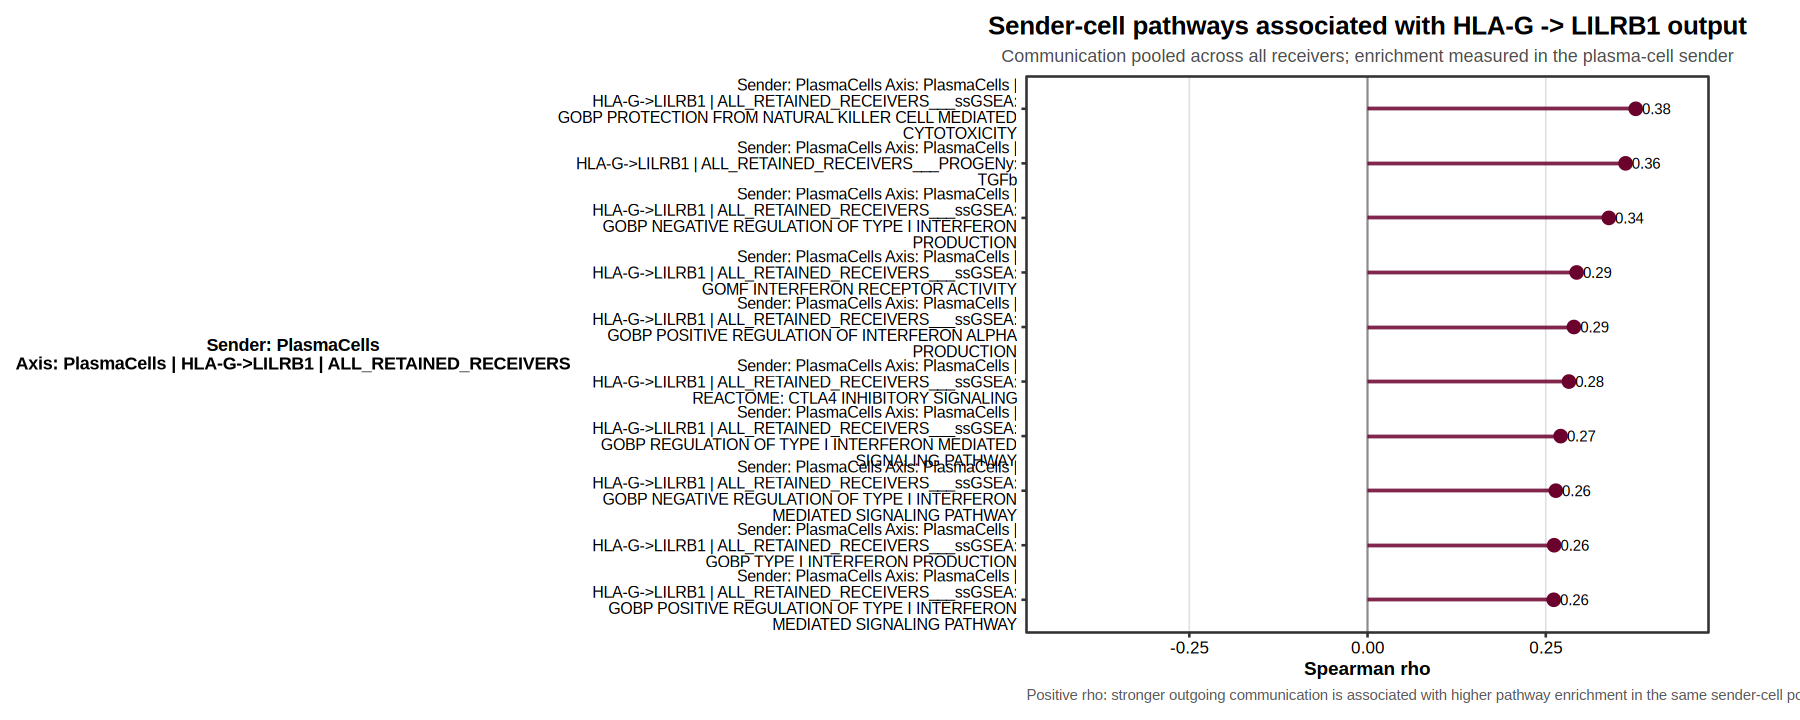

In [16]:
# ============================================================
# Sender-cell signaling -> sender-cell enrichment analysis
#
# This module answers:
#   Which pathways are enriched in cells that emit a selected
#   CellChat signaling axis?
#
# IMPORTANT:
#   This analysis must use the sample-level CellChat and enrichment
#   tables. Existing graph_edges encode receiver-cell enrichment and
#   cannot be relabeled as sender-cell enrichment.
#
# Required notebook objects:
#   cellchat_sample_edges_md
#   enrichment_sample_edges_md
# ============================================================

suppressPackageStartupMessages({
  library(dplyr)
  library(tidyr)
  library(stringr)
  library(ggplot2)
  library(readr)
  library(scales)
  library(RColorBrewer)
})

if (!exists("%||%", mode = "function")) {
  `%||%` <- function(x, y) if (is.null(x)) y else x
}


# ------------------------------------------------------------
# General helpers
# ------------------------------------------------------------

normalize_sender_text <- function(x) {
  x <- as.character(x)
  x <- gsub("[\u2212\u2010\u2011\u2012\u2013\u2014]", "-", x, perl = TRUE)
  x <- gsub("\u00A0", " ", x, fixed = TRUE)
  stringr::str_squish(x)
}


make_cell_match_key <- function(x) {
  x <- normalize_sender_text(x)
  x <- stringr::str_to_lower(x)
  gsub("[^a-z0-9]+", "", x, perl = TRUE)
}


collapse_sender_regex <- function(x) {
  if (is.null(x) || length(x) == 0) return(NULL)

  x <- normalize_sender_text(x)
  x <- x[!is.na(x) & nzchar(x)]

  if (length(x) == 0) return(NULL)
  paste(x, collapse = "|")
}


first_present_column <- function(df, candidates) {
  hit <- intersect(candidates, colnames(df))
  if (length(hit) == 0) return(NULL)
  hit[[1]]
}


safe_sender_spearman <- function(x, y, min_n = 4) {
  x <- suppressWarnings(as.numeric(x))
  y <- suppressWarnings(as.numeric(y))

  ok <- is.finite(x) & is.finite(y)
  n <- sum(ok)

  if (
    n < min_n ||
    dplyr::n_distinct(x[ok]) < 2 ||
    dplyr::n_distinct(y[ok]) < 2
  ) {
    return(tibble(
      n_samples = n,
      rho = NA_real_,
      p_value = NA_real_
    ))
  }

  tt <- tryCatch(
    suppressWarnings(
      stats::cor.test(
        x[ok],
        y[ok],
        method = "spearman",
        exact = FALSE
      )
    ),
    error = function(e) NULL
  )

  if (is.null(tt)) {
    return(tibble(
      n_samples = n,
      rho = NA_real_,
      p_value = NA_real_
    ))
  }

  tibble(
    n_samples = n,
    rho = unname(tt$estimate),
    p_value = tt$p.value
  )
}


summarise_communication_value <- function(x, method) {
  x <- suppressWarnings(as.numeric(x))
  x <- x[is.finite(x)]

  if (length(x) == 0) return(NA_real_)

  switch(
    method,
    sum = sum(x),
    mean = mean(x),
    max = max(x),
    stop("Unsupported communication summary: ", method)
  )
}


apply_named_cell_map <- function(x, cell_name_map = NULL) {
  x <- normalize_sender_text(x)

  if (is.null(cell_name_map)) {
    return(x)
  }

  if (is.null(names(cell_name_map)) || any(names(cell_name_map) == "")) {
    stop(
      "cell_name_map must be a named character vector. ",
      "Names are CellChat sender labels and values are enrichment-cell labels."
    )
  }

  map_names <- normalize_sender_text(names(cell_name_map))
  map_values <- normalize_sender_text(unname(cell_name_map))

  idx <- match(x, map_names)
  replace <- !is.na(idx)
  x[replace] <- map_values[idx[replace]]

  x
}


# ------------------------------------------------------------
# Standardize the two sample-level input tables
# ------------------------------------------------------------

standardize_sender_cellchat_table <- function(df) {
  colnames(df) <- trimws(colnames(df))

  sample_col <- first_present_column(
    df,
    c("sample_id", "sample", "Sample", "sampleID")
  )
  sender_col <- first_present_column(
    df,
    c("sender_cell", "source", "sender", "source_cell", "Sender")
  )
  receiver_col <- first_present_column(
    df,
    c("receiver_cell", "target", "receiver", "target_cell", "Receiver")
  )
  pathway_col <- first_present_column(
    df,
    c("pathway_name", "pathway", "signaling_pathway")
  )
  ligand_col <- first_present_column(
    df,
    c("ligand", "Ligand")
  )
  receptor_col <- first_present_column(
    df,
    c("receptor", "Receptor")
  )
  interaction_col <- first_present_column(
    df,
    c("interaction_name_2", "interaction_name", "interaction")
  )
  lr_col <- first_present_column(
    df,
    c("LR", "ligand_receptor", "lr_pair")
  )
  axis_col <- first_present_column(
    df,
    c("communication_axis", "signaling_axis")
  )
  score_col <- first_present_column(
    df,
    c(
      "comm_score", "prob", "communication_probability",
      "comm_prob_sum", "comm_prob_mean", "weight"
    )
  )

  required_missing <- c(
    if (is.null(sample_col)) "sample_id",
    if (is.null(sender_col)) "sender_cell/source",
    if (is.null(receiver_col)) "receiver_cell/target",
    if (is.null(score_col)) "comm_score/prob"
  )

  if (length(required_missing) > 0) {
    stop(
      "CellChat table is missing required columns: ",
      paste(required_missing, collapse = ", "),
      "\nAvailable columns: ",
      paste(colnames(df), collapse = ", ")
    )
  }

  out <- tibble(
    sample_id = as.character(df[[sample_col]]),
    sender_cell = normalize_sender_text(df[[sender_col]]),
    receiver_cell = normalize_sender_text(df[[receiver_col]]),
    pathway_name = if (!is.null(pathway_col)) {
      normalize_sender_text(df[[pathway_col]])
    } else {
      NA_character_
    },
    ligand = if (!is.null(ligand_col)) {
      normalize_sender_text(df[[ligand_col]])
    } else {
      NA_character_
    },
    receptor = if (!is.null(receptor_col)) {
      normalize_sender_text(df[[receptor_col]])
    } else {
      NA_character_
    },
    interaction_name_2 = if (!is.null(interaction_col)) {
      normalize_sender_text(df[[interaction_col]])
    } else {
      NA_character_
    },
    LR = if (!is.null(lr_col)) {
      normalize_sender_text(df[[lr_col]])
    } else {
      NA_character_
    },
    communication_axis = if (!is.null(axis_col)) {
      normalize_sender_text(df[[axis_col]])
    } else {
      NA_character_
    },
    comm_score = suppressWarnings(as.numeric(df[[score_col]]))
  )

  for (nm in c("response", "treatment", "resp_group")) {
    out[[nm]] <- if (nm %in% colnames(df)) {
      normalize_sender_text(df[[nm]])
    } else {
      NA_character_
    }
  }

  out <- out %>%
    mutate(
      LR = case_when(
        !is.na(LR) & nzchar(LR) ~ LR,
        !is.na(ligand) & nzchar(ligand) &
          !is.na(receptor) & nzchar(receptor) ~
          paste0(ligand, "->", receptor),
        TRUE ~ interaction_name_2
      ),
      communication_axis = case_when(
        !is.na(communication_axis) & nzchar(communication_axis) ~
          communication_axis,
        TRUE ~ paste(sender_cell, LR, receiver_cell, sep = " | ")
      )
    ) %>%
    filter(
      !is.na(sample_id),
      nzchar(sample_id),
      !is.na(sender_cell),
      nzchar(sender_cell),
      !is.na(receiver_cell),
      nzchar(receiver_cell),
      is.finite(comm_score)
    )

  out
}


standardize_sender_enrichment_table <- function(df) {
  colnames(df) <- trimws(colnames(df))

  sample_col <- first_present_column(
    df,
    c("sample_id", "sample", "Sample", "sampleID")
  )
  cell_col <- first_present_column(
    df,
    c(
      "receiver_cell", "sender_cell", "Annotation", "Nover",
      "celltype", "cell_type", "cell_annotation"
    )
  )
  method_col <- first_present_column(
    df,
    c("Method", "method")
  )
  pathway_col <- first_present_column(
    df,
    c("functional_pathway", "pathway", "gene_set", "geneset")
  )
  score_col <- first_present_column(
    df,
    c(
      "mean_score_z", "score_z", "NES", "mean_NES",
      "score", "score_raw"
    )
  )

  required_missing <- c(
    if (is.null(sample_col)) "sample_id",
    if (is.null(cell_col)) "cell annotation",
    if (is.null(pathway_col)) "functional pathway",
    if (is.null(score_col)) "enrichment score"
  )

  if (length(required_missing) > 0) {
    stop(
      "Enrichment table is missing required columns: ",
      paste(required_missing, collapse = ", "),
      "\nAvailable columns: ",
      paste(colnames(df), collapse = ", ")
    )
  }

  out <- tibble(
    sample_id = as.character(df[[sample_col]]),
    enrichment_cell = normalize_sender_text(df[[cell_col]]),
    Method = if (!is.null(method_col)) {
      normalize_sender_text(df[[method_col]])
    } else {
      "enrichment"
    },
    functional_pathway = normalize_sender_text(df[[pathway_col]]),
    sender_enrichment_score =
      suppressWarnings(as.numeric(df[[score_col]]))
  )

  for (nm in c("response", "treatment", "resp_group")) {
    out[[nm]] <- if (nm %in% colnames(df)) {
      normalize_sender_text(df[[nm]])
    } else {
      NA_character_
    }
  }

  out %>%
    filter(
      !is.na(sample_id),
      nzchar(sample_id),
      !is.na(enrichment_cell),
      nzchar(enrichment_cell),
      !is.na(functional_pathway),
      nzchar(functional_pathway),
      is.finite(sender_enrichment_score)
    )
}


# ------------------------------------------------------------
# Main analysis
# ------------------------------------------------------------

answer_sender_cell_enrichment <- function(
    cellchat_sample_edges,
    enrichment_sample_edges,

    sender_include_regex,
    signaling_pattern,

    sender_exclude_regex = NULL,
    receiver_include_regex = NULL,
    receiver_exclude_regex = NULL,

    # "per_receiver":
    #   Keep each sender -> receiver signaling axis separate.
    #
    # "pooled_receivers":
    #   Aggregate outgoing signaling across all retained receivers for
    #   each sender and LR pair before association testing.
    outgoing_scope = c("per_receiver", "pooled_receivers"),

    communication_summary = c("sum", "mean", "max"),

    response_focus = NULL,
    treatment_focus = NULL,
    resp_group_focus = NULL,

    fill_missing_communication_with_zero = TRUE,

    # Optional named vector:
    # c("CellChat sender label" = "enrichment cell label")
    cell_name_map = NULL,

    min_samples = 4,
    direction = c("positive", "negative", "both"),
    padj_cutoff = NULL,
    min_abs_rho = 0,

    top_n_per_facet = NULL
) {
  outgoing_scope <- match.arg(outgoing_scope)
  communication_summary <- match.arg(communication_summary)
  direction <- match.arg(direction)

  sender_pat <- collapse_sender_regex(sender_include_regex)
  sender_exclude_pat <- collapse_sender_regex(sender_exclude_regex)
  signaling_pat <- collapse_sender_regex(signaling_pattern)
  receiver_include_pat <- collapse_sender_regex(receiver_include_regex)
  receiver_exclude_pat <- collapse_sender_regex(receiver_exclude_regex)

  if (is.null(sender_pat)) {
    stop("sender_include_regex must contain at least one non-empty pattern.")
  }

  if (is.null(signaling_pat)) {
    stop("signaling_pattern must contain at least one non-empty pattern.")
  }

  comm <- standardize_sender_cellchat_table(cellchat_sample_edges)
  enrich <- standardize_sender_enrichment_table(enrichment_sample_edges)

  # Apply optional explicit mapping before generating cell-match keys.
  comm <- comm %>%
    mutate(
      sender_cell_for_enrichment =
        apply_named_cell_map(sender_cell, cell_name_map),
      sender_match_key =
        make_cell_match_key(sender_cell_for_enrichment),
      signal_search_text = paste(
        coalesce(pathway_name, ""),
        coalesce(ligand, ""),
        coalesce(receptor, ""),
        coalesce(LR, ""),
        coalesce(interaction_name_2, ""),
        coalesce(communication_axis, ""),
        sep = " | "
      )
    )

  enrich <- enrich %>%
    mutate(
      sender_match_key = make_cell_match_key(enrichment_cell)
    )

  # Context filters.
  if (!is.null(response_focus)) {
    if (all(is.na(comm$response)) || all(is.na(enrich$response))) {
      stop(
        "response_focus was supplied, but response metadata is unavailable ",
        "in one or both input tables."
      )
    }

    response_pat <- collapse_sender_regex(response_focus)

    comm <- comm %>%
      filter(str_detect(
        coalesce(response, ""),
        regex(response_pat, ignore_case = TRUE)
      ))

    enrich <- enrich %>%
      filter(str_detect(
        coalesce(response, ""),
        regex(response_pat, ignore_case = TRUE)
      ))
  }

  if (!is.null(treatment_focus)) {
    if (all(is.na(comm$treatment)) || all(is.na(enrich$treatment))) {
      stop(
        "treatment_focus was supplied, but treatment metadata is unavailable ",
        "in one or both input tables."
      )
    }

    treatment_pat <- collapse_sender_regex(treatment_focus)

    comm <- comm %>%
      filter(str_detect(
        coalesce(treatment, ""),
        regex(treatment_pat, ignore_case = TRUE)
      ))

    enrich <- enrich %>%
      filter(str_detect(
        coalesce(treatment, ""),
        regex(treatment_pat, ignore_case = TRUE)
      ))
  }

  if (!is.null(resp_group_focus)) {
    if (all(is.na(comm$resp_group)) || all(is.na(enrich$resp_group))) {
      stop(
        "resp_group_focus was supplied, but resp_group metadata is unavailable ",
        "in one or both input tables."
      )
    }

    resp_group_pat <- collapse_sender_regex(resp_group_focus)

    comm <- comm %>%
      filter(str_detect(
        coalesce(resp_group, ""),
        regex(resp_group_pat, ignore_case = TRUE)
      ))

    enrich <- enrich %>%
      filter(str_detect(
        coalesce(resp_group, ""),
        regex(resp_group_pat, ignore_case = TRUE)
      ))
  }

  # Signaling, sender, and optional receiver filters.
  comm_signal_before_sender <- comm %>%
    filter(str_detect(
      signal_search_text,
      regex(signaling_pat, ignore_case = TRUE)
    ))

  comm_sender_before_signal <- comm %>%
    filter(str_detect(
      sender_cell,
      regex(sender_pat, ignore_case = TRUE)
    ))

  comm <- comm_signal_before_sender %>%
    filter(str_detect(
      sender_cell,
      regex(sender_pat, ignore_case = TRUE)
    ))

  if (!is.null(sender_exclude_pat)) {
    comm <- comm %>%
      filter(!str_detect(
        sender_cell,
        regex(sender_exclude_pat, ignore_case = TRUE)
      ))
  }

  if (!is.null(receiver_include_pat)) {
    comm <- comm %>%
      filter(str_detect(
        receiver_cell,
        regex(receiver_include_pat, ignore_case = TRUE)
      ))
  }

  if (!is.null(receiver_exclude_pat)) {
    comm <- comm %>%
      filter(!str_detect(
        receiver_cell,
        regex(receiver_exclude_pat, ignore_case = TRUE)
      ))
  }

  if (nrow(comm) == 0) {
    signal_examples <- comm_signal_before_sender %>%
      distinct(
        sender_cell, receiver_cell, pathway_name,
        ligand, receptor, LR, communication_axis
      ) %>%
      slice_head(n = 25)

    sender_examples <- comm_sender_before_signal %>%
      filter(str_detect(
        signal_search_text,
        regex("HLA|MHC|CD1D|MR1", ignore_case = TRUE)
      )) %>%
      distinct(
        sender_cell, receiver_cell, pathway_name,
        ligand, receptor, LR, communication_axis
      ) %>%
      slice_head(n = 25)

    stop(
      paste0(
        "No CellChat rows remained after signaling, sender, and receiver filters.\n\n",
        "Signaling pattern: ", signaling_pat, "\n",
        "Sender pattern: ", sender_pat, "\n",
        "Receiver include pattern: ",
        receiver_include_pat %||% "NULL", "\n",
        "Receiver exclude pattern: ",
        receiver_exclude_pat %||% "NULL", "\n\n",
        "Rows matching signaling before sender filtering: ",
        nrow(comm_signal_before_sender), "\n",
        "Rows matching sender before signaling filtering: ",
        nrow(comm_sender_before_signal), "\n\n",
        "Inspect these objects after running the standardization helpers:\n",
        "  standardize_sender_cellchat_table(cellchat_sample_edges)\n",
        "  standardize_sender_enrichment_table(enrichment_sample_edges)\n\n",
        "Example signal matches:\n",
        paste(capture.output(print(signal_examples)), collapse = "\n"),
        "\n\nExample HLA/MHC axes from requested senders:\n",
        paste(capture.output(print(sender_examples)), collapse = "\n")
      ),
      call. = FALSE
    )
  }

  # Aggregate duplicate CellChat rows within each sample and axis.
  if (outgoing_scope == "per_receiver") {
    comm_agg <- comm %>%
      group_by(
        sample_id,
        sender_cell,
        sender_cell_for_enrichment,
        sender_match_key,
        receiver_cell,
        pathway_name,
        ligand,
        receptor,
        interaction_name_2,
        LR,
        communication_axis
      ) %>%
      summarise(
        comm_score = summarise_communication_value(
          comm_score,
          communication_summary
        ),
        .groups = "drop"
      )
  } else {
    comm_agg <- comm %>%
      group_by(
        sample_id,
        sender_cell,
        sender_cell_for_enrichment,
        sender_match_key,
        pathway_name,
        ligand,
        receptor,
        interaction_name_2,
        LR
      ) %>%
      summarise(
        comm_score = summarise_communication_value(
          comm_score,
          communication_summary
        ),
        n_receivers_observed = n_distinct(receiver_cell),
        .groups = "drop"
      ) %>%
      mutate(
        receiver_cell = "ALL_RETAINED_RECEIVERS",
        communication_axis = paste(
          sender_cell,
          LR,
          receiver_cell,
          sep = " | "
        )
      )
  }

  # Aggregate duplicate enrichment entries within sample/cell/pathway.
  enrich_agg <- enrich %>%
    group_by(
      sample_id,
      enrichment_cell,
      sender_match_key,
      Method,
      functional_pathway
    ) %>%
    summarise(
      sender_enrichment_score =
        mean(sender_enrichment_score, na.rm = TRUE),
      .groups = "drop"
    ) %>%
    filter(is.finite(sender_enrichment_score))

  # Diagnostic cell matching.
  selected_sender_cells <- comm_agg %>%
    distinct(
      sender_cell,
      sender_cell_for_enrichment,
      sender_match_key
    )

  available_enrichment_cells <- enrich_agg %>%
    distinct(enrichment_cell, sender_match_key)

  sender_cell_match_table <- selected_sender_cells %>%
    left_join(
      available_enrichment_cells,
      by = "sender_match_key",
      relationship = "many-to-many"
    )

  unmatched_senders <- sender_cell_match_table %>%
    filter(is.na(enrichment_cell)) %>%
    distinct(
      sender_cell,
      sender_cell_for_enrichment,
      sender_match_key
    )

  if (nrow(unmatched_senders) > 0) {
    stop(
      paste0(
        "The selected CellChat sender labels do not have matching enrichment ",
        "cell labels.\n\nUnmatched sender labels:\n",
        paste(capture.output(print(unmatched_senders)), collapse = "\n"),
        "\n\nAvailable enrichment-cell labels:\n",
        paste(
          capture.output(
            print(
              available_enrichment_cells %>%
                arrange(enrichment_cell) %>%
                slice_head(n = 100)
            )
          ),
          collapse = "\n"
        ),
        "\n\nUse cell_name_map when the labels differ, for example:\n",
        "  cell_name_map = c(\n",
        "    'CellChat sender label' = 'enrichment cell label'\n",
        "  )"
      ),
      call. = FALSE
    )
  }

  # Optionally represent an unobserved communication axis as zero in
  # samples where the sender-cell enrichment was measured.
  if (isTRUE(fill_missing_communication_with_zero)) {
    axis_id_cols <- c(
      "sender_cell",
      "sender_cell_for_enrichment",
      "sender_match_key",
      "receiver_cell",
      "pathway_name",
      "ligand",
      "receptor",
      "interaction_name_2",
      "LR",
      "communication_axis"
    )

    axis_meta <- comm_agg %>%
      distinct(across(all_of(axis_id_cols)))

    sender_sample_grid <- enrich_agg %>%
      distinct(sample_id, sender_match_key)

    comm_grid <- sender_sample_grid %>%
      inner_join(
        axis_meta,
        by = "sender_match_key",
        relationship = "many-to-many"
      )

    comm_agg <- comm_grid %>%
      left_join(
        comm_agg,
        by = c("sample_id", axis_id_cols)
      ) %>%
      mutate(
        comm_score = replace_na(comm_score, 0)
      )
  }

  # CRITICAL JOIN:
  # enrichment is aligned to sender_match_key, not receiver_cell.
  joined_sender_level <- comm_agg %>%
    inner_join(
      enrich_agg,
      by = c("sample_id", "sender_match_key"),
      relationship = "many-to-many"
    )

  if (nrow(joined_sender_level) == 0) {
    stop(
      "No sample-level rows remained after joining communication to ",
      "sender-cell enrichment on sample_id + sender_match_key."
    )
  }

  grouping_cols <- c(
    "sender_cell",
    "sender_cell_for_enrichment",
    "enrichment_cell",
    "receiver_cell",
    "pathway_name",
    "ligand",
    "receptor",
    "interaction_name_2",
    "LR",
    "communication_axis",
    "Method",
    "functional_pathway"
  )

  results <- joined_sender_level %>%
    group_by(across(all_of(grouping_cols))) %>%
    group_modify(
      ~ safe_sender_spearman(
        .x$comm_score,
        .x$sender_enrichment_score,
        min_n = min_samples
      )
    ) %>%
    ungroup() %>%
    mutate(
      padj = p.adjust(p_value, method = "BH"),
      abs_rho = abs(rho),
      association_direction = case_when(
        rho > 0 ~ "positive",
        rho < 0 ~ "negative",
        TRUE ~ "flat_or_unavailable"
      ),
      interpretation = case_when(
        rho > 0 ~ paste0(
          "Across samples, stronger outgoing signaling is associated with ",
          "higher pathway enrichment in the sender cell."
        ),
        rho < 0 ~ paste0(
          "Across samples, stronger outgoing signaling is associated with ",
          "lower pathway enrichment in the sender cell."
        ),
        TRUE ~ "Association could not be estimated."
      )
    )

  # Add descriptive means without changing the correlation grouping.
  descriptive <- joined_sender_level %>%
    group_by(across(all_of(grouping_cols))) %>%
    summarise(
      mean_comm_score = mean(comm_score, na.rm = TRUE),
      mean_sender_enrichment =
        mean(sender_enrichment_score, na.rm = TRUE),
      .groups = "drop"
    )

  results <- results %>%
    left_join(
      descriptive,
      by = grouping_cols
    ) %>%
    filter(is.finite(rho))

  results <- switch(
    direction,
    positive = results %>% filter(rho > 0),
    negative = results %>% filter(rho < 0),
    both = results %>% filter(rho != 0)
  )

  if (!is.null(min_abs_rho) && is.finite(min_abs_rho)) {
    results <- results %>%
      filter(abs_rho >= min_abs_rho)
  }

  if (!is.null(padj_cutoff)) {
    results <- results %>%
      filter(is.finite(padj), padj <= padj_cutoff)
  }

  if (!is.null(top_n_per_facet) && is.finite(top_n_per_facet)) {
    facet_group_cols <- if (outgoing_scope == "per_receiver") {
      c("sender_cell", "receiver_cell", "communication_axis")
    } else {
      c("sender_cell", "communication_axis")
    }

    results <- results %>%
      group_by(across(all_of(facet_group_cols))) %>%
      slice_max(
        order_by = abs_rho,
        n = top_n_per_facet,
        with_ties = FALSE
      ) %>%
      ungroup()
  }

  results <- results %>%
    arrange(
      sender_cell,
      receiver_cell,
      communication_axis,
      desc(abs_rho),
      padj,
      functional_pathway
    )

  attr(results, "joined_sender_sample_level") <- joined_sender_level
  attr(results, "selected_cellchat_axes") <- comm %>%
    distinct(
      sender_cell,
      sender_cell_for_enrichment,
      receiver_cell,
      pathway_name,
      ligand,
      receptor,
      LR,
      communication_axis
    ) %>%
    arrange(sender_cell, receiver_cell, LR)
  attr(results, "sender_cell_match_table") <- sender_cell_match_table
  attr(results, "settings") <- list(
    sender_include_regex = sender_pat,
    sender_exclude_regex = sender_exclude_pat,
    signaling_pattern = signaling_pat,
    receiver_include_regex = receiver_include_pat,
    receiver_exclude_regex = receiver_exclude_pat,
    outgoing_scope = outgoing_scope,
    communication_summary = communication_summary,
    response_focus = response_focus,
    treatment_focus = treatment_focus,
    resp_group_focus = resp_group_focus,
    fill_missing_communication_with_zero =
      fill_missing_communication_with_zero,
    min_samples = min_samples,
    direction = direction,
    padj_cutoff = padj_cutoff,
    min_abs_rho = min_abs_rho
  )

  results
}


# ------------------------------------------------------------
# Plot sender-cell enrichment associations
# ------------------------------------------------------------

plot_sender_cell_enrichment <- function(
    query_df,
    top_n_per_facet = 10,
    facet_by = c(
      "sender_receiver_axis",
      "sender_receiver",
      "sender_axis",
      "sender"
    ),
    title = NULL,
    subtitle = NULL,
    xlab = "Spearman rho",
    out_dir = ".",
    file_prefix = "sender_cell_signaling_sender_enrichment",
    width = 12,
    height_per_row = 0.30,
    min_height = 5.5,
    max_height = 16,
    save_csv = TRUE,
    save_pdf = TRUE,
    save_png = TRUE
) {
  facet_by <- match.arg(facet_by)

  required_cols <- c(
    "sender_cell",
    "receiver_cell",
    "communication_axis",
    "Method",
    "functional_pathway",
    "rho"
  )

  missing_cols <- setdiff(required_cols, colnames(query_df))
  if (length(missing_cols) > 0) {
    stop(
      "query_df is missing required columns: ",
      paste(missing_cols, collapse = ", ")
    )
  }

  if (nrow(query_df) == 0) {
    stop("query_df is empty after association filtering.")
  }

  clean_pathway_label <- function(method, pathway) {
    pathway2 <- normalize_sender_text(pathway) %>%
      str_replace("^phenotype:", "") %>%
      str_replace("^pathway:", "") %>%
      str_replace("^enrichment:", "") %>%
      str_replace("^HALLMARK_", "HALLMARK: ") %>%
      str_replace("^PROGENy_", "PROGENy: ") %>%
      str_replace("^REACTOME_", "REACTOME: ") %>%
      str_replace("^KEGG_", "KEGG: ") %>%
      str_replace_all("_", " ") %>%
      str_squish()

    method2 <- normalize_sender_text(method)

    ifelse(
      is.na(method2) | method2 == "",
      pathway2,
      paste0(method2, ": ", pathway2)
    )
  }

  plot_df <- query_df %>%
    mutate(
      sender_cell = normalize_sender_text(sender_cell),
      receiver_cell = normalize_sender_text(receiver_cell),
      rho = suppressWarnings(as.numeric(rho)),
      abs_rho = abs(rho),
      function_label =
        clean_pathway_label(Method, functional_pathway),
      facet_label = case_when(
        facet_by == "sender_receiver_axis" ~ paste0(
          "Sender: ", sender_cell,
          "  ->  Receiver: ", receiver_cell,
          "\nAxis: ", communication_axis
        ),
        facet_by == "sender_receiver" ~ paste0(
          "Sender: ", sender_cell,
          "  ->  Receiver: ", receiver_cell
        ),
        facet_by == "sender_axis" ~ paste0(
          "Sender: ", sender_cell,
          "\nAxis: ", communication_axis
        ),
        facet_by == "sender" ~ paste0(
          "Sender: ", sender_cell
        )
      )
    ) %>%
    filter(is.finite(rho)) %>%
    group_by(facet_label) %>%
    slice_max(
      order_by = abs_rho,
      n = top_n_per_facet,
      with_ties = FALSE
    ) %>%
    ungroup()

  facet_order <- plot_df %>%
    group_by(facet_label) %>%
    summarise(
      max_abs_rho = max(abs_rho, na.rm = TRUE),
      .groups = "drop"
    ) %>%
    arrange(desc(max_abs_rho), facet_label) %>%
    pull(facet_label)

  plot_df <- plot_df %>%
    mutate(
      facet_label = factor(facet_label, levels = facet_order)
    ) %>%
    arrange(facet_label, rho) %>%
    mutate(
      plot_row_number = row_number(),
      row_id = paste(
        facet_label,
        function_label,
        paste0("row", plot_row_number),
        sep = "___"
      ),
      row_id = factor(row_id, levels = unique(row_id))
    )

  sender_levels <- unique(plot_df$sender_cell)

  base_cols <- grDevices::colorRampPalette(
    RColorBrewer::brewer.pal(11, "Spectral")
  )(length(sender_levels))

  rgb_mat <- grDevices::col2rgb(base_cols) / 255

  sender_cols <- grDevices::rgb(
    rgb_mat[1, ] * 0.68,
    rgb_mat[2, ] * 0.68,
    rgb_mat[3, ] * 0.68
  )

  names(sender_cols) <- sender_levels

  score_limit <- max(abs(plot_df$rho), na.rm = TRUE) * 1.20
  if (!is.finite(score_limit) || score_limit == 0) score_limit <- 1

  title <- title %||%
    "Sender-cell pathways associated with outgoing signaling"

  subtitle <- subtitle %||% paste0(
    "Enrichment is measured in the signaling sender; ",
    "associations are cross-sample Spearman correlations"
  )

  p <- ggplot(
    plot_df,
    aes(
      x = rho,
      y = row_id,
      color = sender_cell
    )
  ) +
    geom_vline(
      xintercept = 0,
      linewidth = 0.45,
      color = "grey55"
    ) +
    geom_segment(
      aes(
        x = 0,
        xend = rho,
        yend = row_id
      ),
      linewidth = 0.8,
      alpha = 0.85
    ) +
    geom_point(size = 3.0) +
    geom_text(
      aes(
        label = scales::number(
          rho,
          accuracy = 0.01
        )
      ),
      hjust = ifelse(plot_df$rho >= 0, -0.22, 1.22),
      size = 3.0,
      color = "black"
    ) +
    scale_color_manual(
      values = sender_cols,
      drop = FALSE
    ) +
    facet_grid(
      facet_label ~ .,
      scales = "free_y",
      space = "free_y",
      switch = "y"
    ) +
    scale_y_discrete(
      labels = function(x) {
        x %>%
          str_replace("^.*?___", "") %>%
          str_replace("___row[0-9]+$", "") %>%
          str_wrap(width = 52)
      }
    ) +
    scale_x_continuous(
      limits = c(-score_limit, score_limit),
      expand = expansion(mult = c(0.03, 0.03))
    ) +
    labs(
      title = title,
      subtitle = subtitle,
      x = xlab,
      y = NULL,
      caption = paste0(
        "Positive rho: stronger outgoing communication is associated ",
        "with higher pathway enrichment in the same sender-cell population. ",
        "This is an association, not proof that the pathway causes secretion."
      )
    ) +
    coord_cartesian(clip = "off") +
    theme_bw(base_size = 12) +
    theme(
      panel.background = element_blank(),
      plot.background = element_blank(),
      panel.grid.major.y = element_blank(),
      panel.grid.minor = element_blank(),
      panel.grid.major.x =
        element_line(color = "grey88", linewidth = 0.35),
      strip.placement = "outside",
      strip.background.y = element_blank(),
      strip.text.y.left = element_text(
        angle = 0,
        face = "bold",
        size = 10.2,
        hjust = 0.5,
        color = "black"
      ),
      axis.text.y = element_text(size = 9, color = "black"),
      axis.text.x = element_text(size = 10, color = "black"),
      axis.title.x = element_text(face = "bold", size = 11),
      plot.title = element_text(
        face = "bold",
        size = 15,
        hjust = 0.5
      ),
      plot.subtitle = element_text(
        size = 10.5,
        hjust = 0.5,
        color = "grey30"
      ),
      plot.caption = element_text(
        size = 8.5,
        color = "grey35",
        hjust = 0
      ),
      legend.position = "none",
      plot.margin = margin(10, 55, 10, 10)
    )

  dir.create(out_dir, recursive = TRUE, showWarnings = FALSE)

  plot_height <- min(
    max_height,
    max(min_height, 1.8 + nrow(plot_df) * height_per_row)
  )

  pdf_file <- file.path(out_dir, paste0(file_prefix, ".pdf"))
  png_file <- file.path(out_dir, paste0(file_prefix, ".png"))
  csv_file <- file.path(
    out_dir,
    paste0(file_prefix, "_plot_data.csv.gz")
  )

  if (save_pdf) {
    ggsave(
      pdf_file,
      p,
      width = width,
      height = plot_height,
      useDingbats = FALSE
    )
    message("Saved: ", pdf_file)
  }

  if (save_png) {
    ggsave(
      png_file,
      p,
      width = width,
      height = plot_height,
      dpi = 300
    )
    message("Saved: ", png_file)
  }

  if (save_csv) {
    readr::write_csv(plot_df, csv_file)
    message("Saved: ", csv_file)
  }

  list(
    result = query_df,
    plot_data = plot_df,
    plot = p,
    files = list(
      pdf = pdf_file,
      png = png_file,
      csv = csv_file
    )
  )
}



# ============================================================
# Simplified interface: sender enrichment with all receivers pooled
#
# Receiver identity is not a user-facing variable. For every sample,
# communication scores are aggregated across all receiver cell types
# before correlation with enrichment in the same sender-cell population.
# ============================================================

answer_sender_enrichment_all_receivers <- function(
    cellchat_sample_edges,
    enrichment_sample_edges,

    sender_include_regex,
    signaling_pattern,

    sender_exclude_regex = NULL,

    communication_summary = c("sum", "mean", "max"),

    response_focus = NULL,
    treatment_focus = NULL,
    resp_group_focus = NULL,

    fill_missing_communication_with_zero = TRUE,
    cell_name_map = NULL,

    min_samples = 4,
    direction = c("positive", "negative", "both"),
    padj_cutoff = NULL,
    min_abs_rho = 0,

    top_n_per_sender_axis = NULL
) {
  communication_summary <- match.arg(communication_summary)
  direction <- match.arg(direction)

  result <- answer_sender_cell_enrichment(
    cellchat_sample_edges = cellchat_sample_edges,
    enrichment_sample_edges = enrichment_sample_edges,

    sender_include_regex = sender_include_regex,
    signaling_pattern = signaling_pattern,
    sender_exclude_regex = sender_exclude_regex,

    # Receiver identity is intentionally unrestricted and pooled.
    receiver_include_regex = NULL,
    receiver_exclude_regex = NULL,
    outgoing_scope = "pooled_receivers",

    communication_summary = communication_summary,

    response_focus = response_focus,
    treatment_focus = treatment_focus,
    resp_group_focus = resp_group_focus,

    fill_missing_communication_with_zero =
      fill_missing_communication_with_zero,

    cell_name_map = cell_name_map,

    min_samples = min_samples,
    direction = direction,
    padj_cutoff = padj_cutoff,
    min_abs_rho = min_abs_rho,

    top_n_per_facet = top_n_per_sender_axis
  )

  # The parent function uses this constant internally after pooling.
  # Keep it for compatibility but place it at the end of the table.
  if ("receiver_cell" %in% colnames(result)) {
    result <- result %>%
      relocate(receiver_cell, .after = last_col())
  }

  attr(result, "analysis_unit") <- paste0(
    "For each sample and sender-cell/LR axis, CellChat communication ",
    "was aggregated across all receiver cell types before association ",
    "with enrichment in the same sender-cell population."
  )

  result
}


plot_sender_enrichment_all_receivers <- function(
    query_df,
    top_n_per_facet = 10,
    facet_by = c("sender_axis", "sender"),
    title = NULL,
    subtitle = NULL,
    xlab = "Spearman rho",
    out_dir = ".",
    file_prefix = "sender_signaling_sender_enrichment_all_receivers",
    width = 12,
    height_per_row = 0.30,
    min_height = 5.5,
    max_height = 16,
    save_csv = TRUE,
    save_pdf = TRUE,
    save_png = TRUE
) {
  facet_by <- match.arg(facet_by)

  subtitle <- subtitle %||% paste0(
    "Outgoing signaling pooled across all receiver cell types; ",
    "enrichment measured in the same sender-cell population"
  )

  plot_sender_cell_enrichment(
    query_df = query_df,
    top_n_per_facet = top_n_per_facet,
    facet_by = facet_by,
    title = title,
    subtitle = subtitle,
    xlab = xlab,
    out_dir = out_dir,
    file_prefix = file_prefix,
    width = width,
    height_per_row = height_per_row,
    min_height = min_height,
    max_height = max_height,
    save_csv = save_csv,
    save_pdf = save_pdf,
    save_png = save_png
  )
}


# ============================================================
# Example:
# Plasma-cell HLA-G -> LILRB1 output pooled across all receivers,
# with enrichment measured in the plasma-cell sender.
# ============================================================

plasma_sender_hlag_sender_enrichment <-
  answer_sender_enrichment_all_receivers(
    cellchat_sample_edges = cellchat_sample_edges_md,
    enrichment_sample_edges = enrichment_sample_edges_md,

    sender_include_regex = "Plasma",
    signaling_pattern = "HLA[-_ ]?G\\s*->\\s*LILRB1",

    # No receiver-cell argument is needed.
    communication_summary = "sum",

    response_focus = NULL,
    treatment_focus = NULL,
    resp_group_focus = NULL,

    fill_missing_communication_with_zero = TRUE,

    min_samples = min_samples_for_cor,
    direction = "positive",
    padj_cutoff = NULL,
    min_abs_rho = 0.05,

    top_n_per_sender_axis = NULL
  )


# Exact outgoing CellChat axes included before pooling receiver identities.
attr(
  plasma_sender_hlag_sender_enrichment,
  "selected_cellchat_axes"
)


# Confirm CellChat sender labels match enrichment cell labels.
attr(
  plasma_sender_hlag_sender_enrichment,
  "sender_cell_match_table"
)


# Description of the analysis unit.
attr(
  plasma_sender_hlag_sender_enrichment,
  "analysis_unit"
)


plasma_sender_hlag_sender_enrichment_viz <-
  plot_sender_enrichment_all_receivers(
    query_df = plasma_sender_hlag_sender_enrichment,

    top_n_per_facet = 10,
    facet_by = "sender_axis",

    title = paste0(
      "Sender-cell pathways associated with ",
      "HLA-G -> LILRB1 output"
    ),
    subtitle = paste0(
      "Communication pooled across all receivers; ",
      "enrichment measured in the plasma-cell sender"
    ),
    xlab = "Spearman rho",

    out_dir = out_dir,
    file_prefix = paste0(
      "16_plasma_sender_HLAG_LILRB1_",
      "sender_enrichment_all_receivers"
    )
  )

plasma_sender_hlag_sender_enrichment_viz$plot


# ============================================================
# Broader non-classical MHC-I example
# ============================================================

# plasma_sender_nonclassical_mhci_enrichment <-
#   answer_sender_enrichment_all_receivers(
#     cellchat_sample_edges = cellchat_sample_edges_md,
#     enrichment_sample_edges = enrichment_sample_edges_md,
#
#     sender_include_regex = "Plasma",
#     signaling_pattern = paste(
#       c(
#         "HLA[-_ ]?E",
#         "HLA[-_ ]?F",
#         "HLA[-_ ]?G"
#       ),
#       collapse = "|"
#     ),
#
#     communication_summary = "sum",
#     fill_missing_communication_with_zero = TRUE,
#
#     min_samples = min_samples_for_cor,
#     direction = "positive",
#     padj_cutoff = NULL,
#     min_abs_rho = 0.05
#   )


In [34]:
# ============================================================
# Query-free microenvironment network visualization
#
# Visualizes the graph directly from graph_nodes and graph_edges,
# without selecting a signaling query or induced-phenotype query.
#
# By default, every valid interaction is retained. Optional pruning
# parameters are provided only to improve readability for large graphs.
# ============================================================

suppressPackageStartupMessages({
  library(dplyr)
  library(tidyr)
  library(stringr)
  library(ggplot2)
  library(readr)
  library(scales)
  library(igraph)
})

`%||%` <- function(x, y) {
  if (is.null(x)) y else x
}

clean_full_graph_label <- function(x, max_width = 26) {
  x %>%
    as.character() %>%
    str_replace("^cell:", "") %>%
    str_replace("^signaling:", "") %>%
    str_replace("^phenotype:", "") %>%
    str_replace("^HALLMARK_", "HALLMARK: ") %>%
    str_replace("^PROGENy_", "PROGENy: ") %>%
    str_replace("^REACTOME_", "REACTOME: ") %>%
    str_replace("^KEGG_", "KEGG: ") %>%
    str_replace_all("_", " ") %>%
    str_squish() %>%
    str_wrap(width = max_width)
}

rescale_safe <- function(x, to = c(0, 1), fallback = mean(to)) {
  x <- suppressWarnings(as.numeric(x))
  out <- rep(fallback, length(x))
  ok <- is.finite(x)

  if (!any(ok)) return(out)

  rng <- range(x[ok], na.rm = TRUE)
  if (diff(rng) == 0) {
    out[ok] <- fallback
  } else {
    out[ok] <- scales::rescale(x[ok], to = to, from = rng)
  }

  out
}

plot_all_microenvironment_interactions <- function(
    nodes,
    edges,

    # NULL retains every available node/edge type.
    node_types_keep = NULL,
    edge_types_keep = NULL,

    # Optional metadata filters, applied only when the columns exist.
    response_focus = NULL,
    treatment_focus = NULL,
    resp_group_focus = NULL,

    # Optional graph pruning. Leave all as NULL for the complete graph.
    min_abs_weight = NULL,
    top_n_edges_per_type = NULL,
    max_edges = NULL,
    keep_largest_component = FALSE,
    remove_isolated_nodes = TRUE,

    # Visual encodings.
    node_size_metric = c("degree", "pagerank", "betweenness"),
    edge_color_mode = c("edge_type", "sign"),
    layout_method = c("fr", "kk", "dh", "circle"),

    label_all_cells = TRUE,
    label_top_hubs = 20,
    label_other_nodes = FALSE,

    title = "Complete microenvironment interaction network",
    subtitle = NULL,

    out_dir = ".",
    file_prefix = "microenvironment_all_interactions",
    width = 14,
    height = 11,
    seed = 1,

    save_pdf = TRUE,
    save_png = TRUE,
    save_csv = TRUE
) {
  node_size_metric <- match.arg(node_size_metric)
  edge_color_mode <- match.arg(edge_color_mode)
  layout_method <- match.arg(layout_method)

  # ----------------------------------------------------------
  # 1) Standardize nodes and edges
  # ----------------------------------------------------------
  required_node_cols <- c("id", "label", "node_type")
  missing_node_cols <- setdiff(required_node_cols, colnames(nodes))
  if (length(missing_node_cols) > 0) {
    stop(
      "nodes is missing required columns: ",
      paste(missing_node_cols, collapse = ", ")
    )
  }

  required_edge_cols <- c("from", "to", "edge_type")
  missing_edge_cols <- setdiff(required_edge_cols, colnames(edges))
  if (length(missing_edge_cols) > 0) {
    stop(
      "edges is missing required columns: ",
      paste(missing_edge_cols, collapse = ", ")
    )
  }

  nodes2 <- nodes %>%
    mutate(
      id = as.character(id),
      label = as.character(label),
      node_type = as.character(node_type)
    ) %>%
    filter(!is.na(id), nzchar(id)) %>%
    distinct(id, .keep_all = TRUE)

  edges2 <- edges %>%
    mutate(
      from = as.character(from),
      to = as.character(to),
      edge_type = as.character(edge_type),
      weight = if ("weight" %in% colnames(.)) {
        suppressWarnings(as.numeric(weight))
      } else {
        NA_real_
      },
      signed_weight = if ("signed_weight" %in% colnames(.)) {
        suppressWarnings(as.numeric(signed_weight))
      } else {
        NA_real_
      }
    ) %>%
    filter(
      !is.na(from), nzchar(from),
      !is.na(to), nzchar(to),
      from %in% nodes2$id,
      to %in% nodes2$id
    )

  # Use absolute signed weight when available; otherwise use weight.
  edges2 <- edges2 %>%
    mutate(
      edge_strength = case_when(
        is.finite(signed_weight) ~ abs(signed_weight),
        is.finite(weight) ~ abs(weight),
        TRUE ~ 1
      ),
      edge_sign = case_when(
        is.finite(signed_weight) & signed_weight > 0 ~ "Positive",
        is.finite(signed_weight) & signed_weight < 0 ~ "Negative",
        TRUE ~ "Unsigned"
      )
    )

  # ----------------------------------------------------------
  # 2) Optional metadata and type filters
  # ----------------------------------------------------------
  apply_optional_filter <- function(df, column, values) {
    if (is.null(values)) return(df)
    if (!column %in% colnames(df)) return(df)

    pat <- paste(values, collapse = "|")
    df %>%
      filter(str_detect(
        coalesce(as.character(.data[[column]]), ""),
        regex(pat, ignore_case = TRUE)
      ))
  }

  edges2 <- edges2 %>%
    apply_optional_filter("response", response_focus) %>%
    apply_optional_filter("treatment", treatment_focus) %>%
    apply_optional_filter("resp_group", resp_group_focus)

  if (!is.null(node_types_keep)) {
    nodes2 <- nodes2 %>% filter(node_type %in% node_types_keep)
    edges2 <- edges2 %>%
      filter(from %in% nodes2$id, to %in% nodes2$id)
  }

  if (!is.null(edge_types_keep)) {
    edges2 <- edges2 %>% filter(edge_type %in% edge_types_keep)
  }

  if (!is.null(min_abs_weight) && is.finite(min_abs_weight)) {
    edges2 <- edges2 %>% filter(edge_strength >= min_abs_weight)
  }

  if (!is.null(top_n_edges_per_type) && is.finite(top_n_edges_per_type)) {
    edges2 <- edges2 %>%
      group_by(edge_type) %>%
      slice_max(
        order_by = edge_strength,
        n = top_n_edges_per_type,
        with_ties = FALSE
      ) %>%
      ungroup()
  }

  if (!is.null(max_edges) && is.finite(max_edges) && nrow(edges2) > max_edges) {
    edges2 <- edges2 %>%
      slice_max(
        order_by = edge_strength,
        n = max_edges,
        with_ties = FALSE
      )
  }

  if (nrow(edges2) == 0) {
    stop("No edges remained after filtering.")
  }

  if (remove_isolated_nodes) {
    retained_ids <- unique(c(edges2$from, edges2$to))
    nodes2 <- nodes2 %>% filter(id %in% retained_ids)
  }

  # ----------------------------------------------------------
  # 3) Build graph
  # ----------------------------------------------------------
  g <- graph_from_data_frame(
    d = edges2,
    vertices = nodes2,
    directed = TRUE
  )

  if (keep_largest_component && vcount(g) > 0) {
    comp <- components(as.undirected(g))
    largest_membership <- which.max(comp$csize)
    keep_vertices <- names(comp$membership)[
      comp$membership == largest_membership
    ]
    g <- induced_subgraph(g, vids = keep_vertices)
  }

  if (vcount(g) < 2 || ecount(g) < 1) {
    stop("The retained graph is too small to visualize.")
  }

  # ----------------------------------------------------------
  # 4) Graph statistics
  # ----------------------------------------------------------
  degree_all <- degree(g, mode = "all")
  degree_in <- degree(g, mode = "in")
  degree_out <- degree(g, mode = "out")
  pagerank_all <- page_rank(
    g,
    directed = TRUE,
    weights = pmax(abs(E(g)$edge_strength), 1e-8)
  )$vector
  betweenness_all <- betweenness(
    g,
    directed = TRUE,
    weights = 1 / pmax(abs(E(g)$edge_strength), 1e-8),
    normalized = TRUE
  )

  # ----------------------------------------------------------
  # 5) Layout
  # ----------------------------------------------------------
  set.seed(seed)
  layout_weights <- pmax(abs(E(g)$edge_strength), 1e-8)

  lay <- switch(
    layout_method,
    fr = layout_with_fr(g, weights = layout_weights),
    kk = layout_with_kk(g, weights = 1 / layout_weights),
    dh = layout_with_dh(g),
    circle = layout_in_circle(g)
  )

  node_df0 <- as_data_frame(g, what = "vertices") %>%
    as_tibble()

  if (!"id" %in% colnames(node_df0)) {
    if ("name" %in% colnames(node_df0)) {
      node_df0$id <- as.character(node_df0$name)
    } else {
      node_df0$id <- names(V(g))
    }
  }

  if (!"label" %in% colnames(node_df0)) node_df0$label <- node_df0$id
  if (!"node_type" %in% colnames(node_df0)) node_df0$node_type <- "unknown"

  # Add graph metrics by vertex ID rather than joining them. The input
  # node table may already contain in_degree/out_degree/total_degree from
  # graph construction. A join would then create .x/.y suffixes and remove
  # the unsuffixed columns expected downstream.
  node_df <- node_df0 %>%
    mutate(
      id = as.character(id),
      label = as.character(label),
      node_type = as.character(node_type),
      x = lay[, 1],
      y = lay[, 2],
      degree = as.numeric(degree_all[id]),
      in_degree = as.numeric(degree_in[id]),
      out_degree = as.numeric(degree_out[id]),
      pagerank = as.numeric(pagerank_all[id]),
      betweenness = as.numeric(betweenness_all[id])
    )

  size_value <- switch(
    node_size_metric,
    degree = node_df$degree,
    pagerank = node_df$pagerank,
    betweenness = node_df$betweenness
  )

  node_df <- node_df %>%
    mutate(
      node_size_value = size_value,
      node_size = rescale_safe(node_size_value, to = c(3.5, 10), fallback = 5.5)
    )

  hub_ids <- node_df %>%
    arrange(desc(node_size_value), desc(degree)) %>%
    slice_head(n = label_top_hubs) %>%
    pull(id)

  node_df <- node_df %>%
    mutate(
      plot_label = case_when(
        label_other_nodes ~ clean_full_graph_label(label),
        label_all_cells & node_type == "cell" ~ clean_full_graph_label(label),
        id %in% hub_ids ~ clean_full_graph_label(label),
        TRUE ~ ""
      )
    )

  edge_df <- as_data_frame(g, what = "edges") %>%
    as_tibble() %>%
    mutate(
      from = as.character(from),
      to = as.character(to),
      edge_strength = suppressWarnings(as.numeric(edge_strength)),
      edge_sign = as.character(edge_sign),
      edge_type = as.character(edge_type)
    ) %>%
    left_join(
      node_df %>% select(from = id, x_from = x, y_from = y),
      by = "from"
    ) %>%
    left_join(
      node_df %>% select(to = id, x_to = x, y_to = y),
      by = "to"
    ) %>%
    mutate(
      edge_width = rescale_safe(edge_strength, to = c(0.2, 1.8), fallback = 0.7),
      edge_alpha = rescale_safe(edge_strength, to = c(0.12, 0.75), fallback = 0.35),
      edge_color_class = if (edge_color_mode == "edge_type") edge_type else edge_sign
    )

  # ----------------------------------------------------------
  # 6) Dynamic palettes
  # ----------------------------------------------------------
  node_levels <- sort(unique(node_df$node_type))
  node_cols <- setNames(
    grDevices::hcl.colors(max(length(node_levels), 1), palette = "Dark 3"),
    node_levels
  )

  edge_levels <- sort(unique(edge_df$edge_color_class))
  if (edge_color_mode == "sign") {
    sign_cols <- c(
      "Positive" = "#B2182B",
      "Negative" = "#2166AC",
      "Unsigned" = "grey55"
    )
    edge_cols <- sign_cols[edge_levels]
    missing_edge_cols <- is.na(edge_cols)
    if (any(missing_edge_cols)) {
      edge_cols[missing_edge_cols] <- grDevices::hcl.colors(
        sum(missing_edge_cols),
        palette = "Dark 3"
      )
    }
  } else {
    edge_cols <- setNames(
      grDevices::hcl.colors(max(length(edge_levels), 1), palette = "Set 2"),
      edge_levels
    )
  }

  # ----------------------------------------------------------
  # 7) Summary statistics
  # ----------------------------------------------------------
  comp <- components(as.undirected(g))

  top_hubs <- node_df %>%
    select(
      id, label, node_type,
      degree, in_degree, out_degree,
      pagerank, betweenness
    ) %>%
    arrange(desc(.data[[node_size_metric]]), desc(degree)) %>%
    slice_head(n = 30)

  key_stats <- list(
    n_nodes = vcount(g),
    n_edges = ecount(g),
    graph_density = edge_density(g, loops = FALSE),
    n_components_undirected = comp$no,
    largest_component_size = max(comp$csize),
    mean_degree = mean(degree_all),
    median_degree = median(degree_all),
    node_type_counts = node_df %>% count(node_type, sort = TRUE),
    edge_type_counts = edge_df %>% count(edge_type, sort = TRUE),
    edge_sign_counts = edge_df %>% count(edge_sign, sort = TRUE),
    top_hubs = top_hubs
  )

  message("========== Full graph statistics ==========")
  message("Nodes: ", key_stats$n_nodes)
  message("Edges: ", key_stats$n_edges)
  message("Density: ", signif(key_stats$graph_density, 3))
  message("Undirected components: ", key_stats$n_components_undirected)
  message("Largest component size: ", key_stats$largest_component_size)
  message("Mean degree: ", signif(key_stats$mean_degree, 3))

  message("\nNode types:")
  print(key_stats$node_type_counts)

  message("\nEdge types:")
  print(key_stats$edge_type_counts)

  message("\nTop hubs:")
  print(key_stats$top_hubs)

  # ----------------------------------------------------------
  # 8) Plot
  # ----------------------------------------------------------
  subtitle <- subtitle %||% paste0(
    "Query-free network; node size = ", node_size_metric,
    "; edge color = ", edge_color_mode,
    "; all retained interactions are shown"
  )

  p <- ggplot() +
    geom_segment(
      data = edge_df,
      aes(
        x = x_from,
        y = y_from,
        xend = x_to,
        yend = y_to,
        color = edge_color_class,
        linewidth = edge_width,
        alpha = edge_alpha
      ),
      lineend = "round",
      arrow = grid::arrow(
        length = grid::unit(0.055, "inches"),
        type = "closed"
      )
    ) +
    geom_point(
      data = node_df,
      aes(
        x = x,
        y = y,
        fill = node_type,
        size = node_size
      ),
      shape = 21,
      color = "black",
      stroke = 0.8,
      alpha = 0.92
    ) +
    geom_text(
      data = node_df %>% filter(nzchar(plot_label)),
      aes(x = x, y = y, label = plot_label),
      size = 2,
      vjust = -1.0,
      check_overlap = TRUE
    ) +
    scale_fill_manual(values = node_cols, drop = FALSE) +
    scale_color_manual(values = edge_cols, drop = FALSE) +
    scale_size_identity() +
    scale_linewidth_identity() +
    scale_alpha_identity() +
    labs(
      title = title,
      subtitle = subtitle,
      fill = "Node type",
      color = if (edge_color_mode == "edge_type") "Interaction type" else "Interaction sign",
      caption = paste0(
        "Nodes = ", key_stats$n_nodes,
        "; edges = ", key_stats$n_edges,
        "; components = ", key_stats$n_components_undirected,
        "; density = ", signif(key_stats$graph_density, 3)
      )
    ) +
    coord_equal(clip = "off") +
    theme_void(base_size = 12) +
    theme(
      plot.background = element_blank(),
      panel.background = element_blank(),
      legend.position = "right",
      legend.title = element_text(face = "bold"),
      plot.title = element_text(face = "bold", size = 15, hjust = 0.5),
      plot.subtitle = element_text(size = 10.5, hjust = 0.5, color = "grey30"),
      plot.caption = element_text(size = 8.5, color = "grey35", hjust = 0),
      plot.margin = margin(12, 18, 12, 18)
    )

  # ----------------------------------------------------------
  # 9) Save outputs
  # ----------------------------------------------------------
  dir.create(out_dir, recursive = TRUE, showWarnings = FALSE)

  suffix <- paste(layout_method, node_size_metric, edge_color_mode, sep = "_")
  pdf_file <- file.path(out_dir, paste0(file_prefix, "_", suffix, ".pdf"))
  png_file <- file.path(out_dir, paste0(file_prefix, "_", suffix, ".png"))
  node_file <- file.path(out_dir, paste0(file_prefix, "_", suffix, "_nodes.csv.gz"))
  edge_file <- file.path(out_dir, paste0(file_prefix, "_", suffix, "_edges.csv.gz"))
  hub_file <- file.path(out_dir, paste0(file_prefix, "_", suffix, "_top_hubs.csv.gz"))

  if (save_pdf) {
    ggsave(
      pdf_file,
      p,
      width = width,
      height = height,
      useDingbats = FALSE
    )
    message("Saved: ", pdf_file)
  }

  if (save_png) {
    ggsave(
      png_file,
      p,
      width = width,
      height = height,
      dpi = 300
    )
    message("Saved: ", png_file)
  }

  if (save_csv) {
    readr::write_csv(node_df, node_file)
    readr::write_csv(edge_df, edge_file)
    readr::write_csv(top_hubs, hub_file)

    message("Saved: ", node_file)
    message("Saved: ", edge_file)
    message("Saved: ", hub_file)
  }

  list(
    graph = g,
    nodes = node_df,
    edges = edge_df,
    stats = key_stats,
    top_hubs = top_hubs,
    plot = p,
    files = list(
      pdf = if (save_pdf) pdf_file else NULL,
      png = if (save_png) png_file else NULL,
      nodes = if (save_csv) node_file else NULL,
      edges = if (save_csv) edge_file else NULL,
      top_hubs = if (save_csv) hub_file else NULL
    )
  )
}





========== Full graph statistics ==========

Nodes: 424

Edges: 580

Density: 0.00323

Undirected components: 1

Largest component size: 424

Mean degree: 2.74


Node types:



# A tibble: 3 × 2
  node_type          n
  <chr>          <int>
1 signaling_axis   200
2 phenotype_axis   180
3 cell              44



Edge types:



# A tibble: 3 × 2
  edge_type                  n
  <chr>                  <int>
1 cell_to_signaling_axis   200
2 signaling_axis_to_cell   200
3 cell_to_phenotype_axis   180



Top hubs:



# A tibble: 30 × 8
   id           label node_type degree in_degree out_degree pagerank betweenness
   <chr>        <chr> <chr>      <dbl>     <dbl>      <dbl>    <dbl>       <dbl>
 1 cell::Plasm… Plas… cell         209        72        137  0.115       0.430  
 2 phenotype::… ssGS… phenotyp…      1         1          0  0.0280      0      
 3 phenotype::… ssGS… phenotyp…      1         1          0  0.0259      0      
 4 phenotype::… ssGS… phenotyp…      1         1          0  0.0244      0      
 5 phenotype::… ssGS… phenotyp…      1         1          0  0.0240      0      
 6 cell::CD8_CM CD8_… cell           9         8          1  0.00947     0.0198 
 7 cell::CD8_EM CD8_… cell           9         8          1  0.00947     0.00109
 8 cell::CD8_N… CD8_… cell           9         8          1  0.00947     0.0198 
 9 signaling::… MIF-… signalin…      2         1          1  0.00926     0.0211 
10 phenotype::… ssGS… phenotyp…      1         1          0  0.00926     0      
# ℹ 20 mo

Saved: ./results/plasma_cellchat_ALNiche_axis_graph/16_microenvironment_interaction_backbone_fr_pagerank_edge_type.pdf

Saved: ./results/plasma_cellchat_ALNiche_axis_graph/16_microenvironment_interaction_backbone_fr_pagerank_edge_type.png

Saved: ./results/plasma_cellchat_ALNiche_axis_graph/16_microenvironment_interaction_backbone_fr_pagerank_edge_type_nodes.csv.gz

Saved: ./results/plasma_cellchat_ALNiche_axis_graph/16_microenvironment_interaction_backbone_fr_pagerank_edge_type_edges.csv.gz

Saved: ./results/plasma_cellchat_ALNiche_axis_graph/16_microenvironment_interaction_backbone_fr_pagerank_edge_type_top_hubs.csv.gz



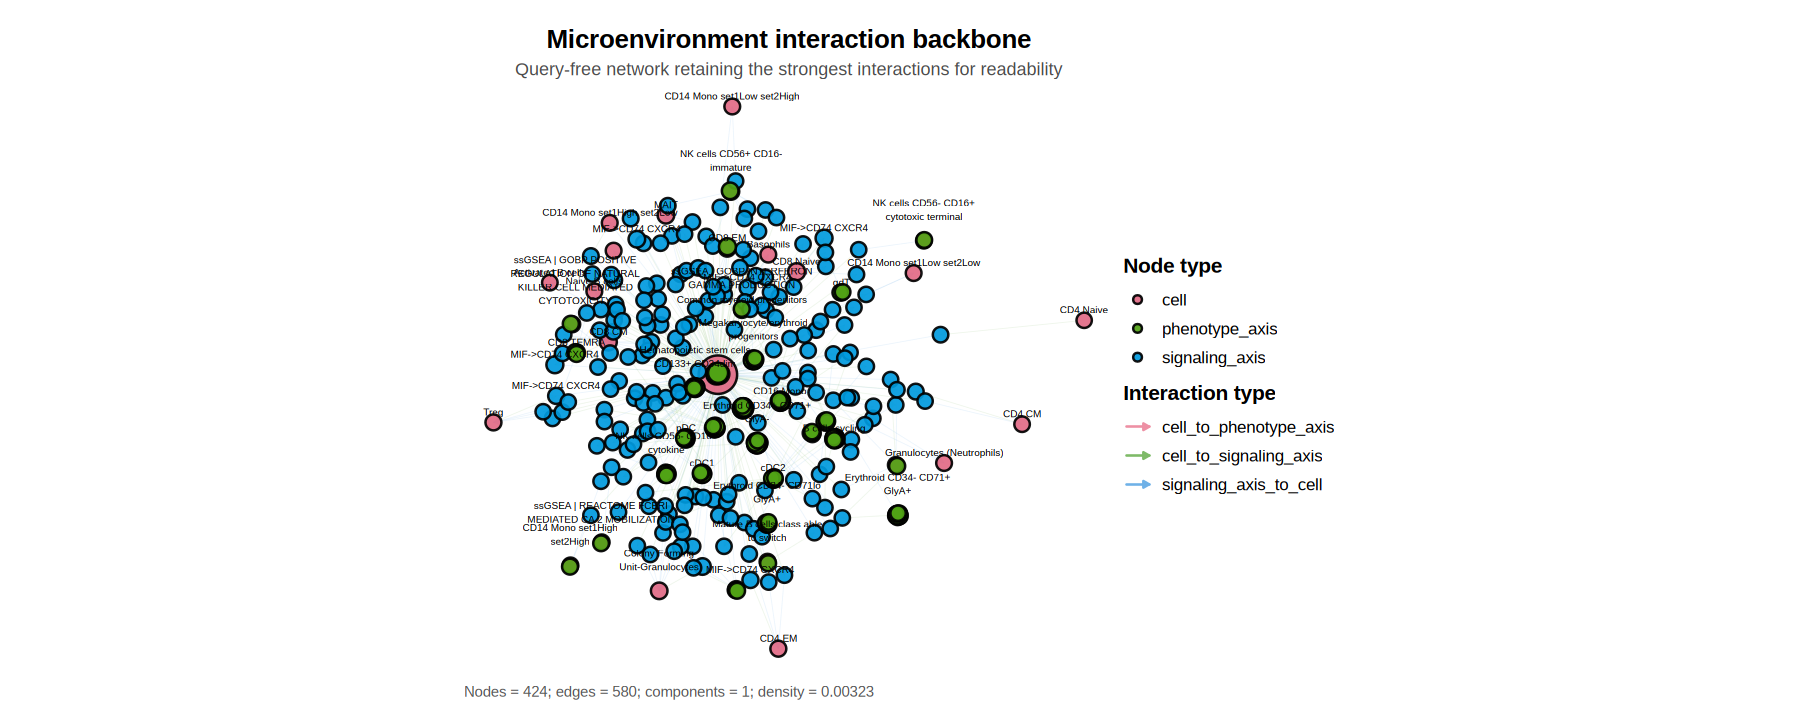

In [35]:
# ============================================================
# Example 2: readable backbone of a very large graph
#
# This is still query-free. It retains the strongest interactions
# globally rather than selecting interactions around a query.
# ============================================================

all_interactions_backbone_viz <- plot_all_microenvironment_interactions(
   nodes = graph_nodes,
   edges = graph_edges,

   node_types_keep = NULL,
   edge_types_keep = c(
    "cell_to_signaling_axis",
     "signaling_axis_to_cell",
     "cell_to_phenotype_axis"
 ),

   top_n_edges_per_type = 200,
   max_edges = 1000,
   keep_largest_component = TRUE,

   node_size_metric = "pagerank",
   edge_color_mode = "edge_type",
   layout_method = "fr",

   label_all_cells = TRUE,
   label_top_hubs = 60,

   title = "Microenvironment interaction backbone",
   subtitle = paste0(
     "Query-free network retaining the strongest interactions ",
     "for readability"
   ),
   out_dir = out_dir,
    file_prefix = "16_microenvironment_interaction_backbone"
)

all_interactions_backbone_viz$plot

## 12. Output checklist

Main files written to `out_dir`:

- `01_cellchat_sample_level_edges.csv.gz`
- `02_sample_metadata_used.csv.gz`
- `04_enrichment_sample_level_receiver_pathways.csv.gz`
- `05_graph_input_cellcell_signaling_edges_sample_metadata.csv.gz`
- `06_graph_input_enrichment_edges_sample_metadata.csv.gz`
- `07_joined_sample_level_communication_enrichment_axes.csv.gz`
- `08_signaling_to_phenotype_spearman_links.csv.gz`
- `09_delta_links_Post_vs_Pre.csv.gz`
- `10_delta_links_Poor_vs_Good.csv.gz`
- `11_PostPre_pattern_Poor_vs_Good_comparison.csv.gz`
- `12_ALNiche_axis_graph_nodes.csv.gz`
- `13_ALNiche_axis_graph_edges.csv.gz`
- `14_query_PGE2_EP2_EP4_induced_phenotypes_nonplasma_receiver.csv.gz`
- `14_query_PGE2_EP2_EP4_induced_phenotypes.csv.gz`

The graph is established at `12_ALNiche_axis_graph_nodes.csv.gz` and `13_ALNiche_axis_graph_edges.csv.gz`.
Everything after that is query logic operating on the established graph.

Query outputs are restricted to non-plasma receiver cells by default through `query_receiver_exclude_regex <- plasma_regex`.
